# Lesson 128 · Task taxonomy: choose the target, head, loss and metric

Teacher reference · PROVIDED = inspect; TODO = implement; CHECK = run; EXIT = defend. Default execution replays complete author predictions and task tables. It does not train a model. Full training is explicitly gated below. PENDING_WRITTEN_DEFENSE.

In [1]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch','sklearn':'scikit-learn'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


Actual notebook runtime: 3.12.3 (main, Aug 31 2026, 10:18:26) [GCC 13.3.0]
{'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'pytorch-frame': '0.3.0', 'torch-geometric': '2.8.0.post1', 'relbench': '1.1.0'}


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 127 to this lesson</p>
<p>One regression result is not a universal task template. Let the query and outcome determine whether you need a number, a probability or a ranking.</p>
<details><summary>Quick prerequisite reminder</summary><p>A logit is an unconstrained score. A probability describes a binary outcome under its task contract. A recommendation score orders a declared candidate set.</p></details>
</aside>
<!-- sequence-review:end -->

> **The win.** Given a prediction request over a database, specify its query, future target, model output, training loss, evaluation metric and temporal split. Then audit a complete classification reproduction whose task name stayed the same while its labels changed.

[Student lab](https://avistian.github.io/relational/labs/0128-task-taxonomy.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0128-task-taxonomy.html) · [Reference](https://avistian.github.io/relational/reference/task-taxonomy.html) · [Reproduction contract](https://avistian.github.io/relational/labs/l128-reproduction.md)



## 1 · The question determines the output

[Lesson 124](https://avistian.github.io/relational/lessons/0124-entity-task-tables.html) separated database entities from supervised task rows. A driver can be queried many times: `(driver, cutoff)` identifies the question. [Lesson 127](https://avistian.github.io/relational/lessons/0127-relbench-v1.html) trained a scalar regression model on those questions. Now ask what changes when the question asks whether an event happens, or which items a customer will buy.



**In plain terms.** A task contract says what an answer means before the model produces it. Its six parts are the query, target, output shape, training objective, evaluation rule and information cutoff. The loss is the quantity optimized during training. The metric is the quantity used to assess predictions; they need not be the same function.

Read [RelBench v1 §5 and Tables 2, 6–8](https://arxiv.org/html/2407.20060v1), then the pinned [EntityTask](https://avistian.github.io/relational/labs/sources/l128/task_entity.py), [RecommendationTask](https://avistian.github.io/relational/labs/sources/l128/task_recommendation.py), and [task-type enum](https://avistian.github.io/relational/labs/sources/l128/task_base.py). The paper distinguishes entity classification, entity regression and recommendation. The API also includes multiclass and multilabel classification. These are output contracts; time is another dimension.

**Bridge to the mission.** Comparing relational learning with manual features is only meaningful when both methods answer the same question and are scored by the same rule. A task name alone does not establish that agreement.



## 2 · One database, different mathematical answers

A **head** maps the learned representation to the required prediction. Let **B** mean the number of queries in a batch, **d** the embedding width, and **C** the number of candidate items. A **logit** is an unrestricted real score; the sigmoid function `1/(1+exp(-z))` converts it to a number between zero and one.

| Real task | Query and future target | Head and output | Released training objective | Selection metric |
|---|---|---|---|---|
| F1 `driver-dnf` | Driver at t; binary label over (t, t+30 days], with historical polarity audited below | One logit per query, B×1; sigmoid at evaluation | Binary cross-entropy with logits | AUROC, higher |
| F1 `driver-position` | Driver at t; mean finishing position over (t, t+60 days] | One scalar per query, B×1 | Mean absolute error / L1 | MAE, lower |
| H&M `user-item-purchase` | Customer at t; set of articles bought over the next 7 days | Scores for candidate articles; evaluator receives B×12 ranked article IDs | Pairwise BPR in the pinned two-tower example | MAP@12, higher |

Sources: pinned [F1 tasks](https://avistian.github.io/relational/labs/sources/l128/f1.py), [H&M task](https://avistian.github.io/relational/labs/sources/l128/hm.py), [node trainer](https://avistian.github.io/relational/labs/sources/l117/gnn_node.py), [link trainer](https://avistian.github.io/relational/labs/sources/l128/gnn_link.py). These are specific baseline choices, not laws requiring every classifier or recommender to use the same loss.

<figure class="stream-figure" tabindex="0">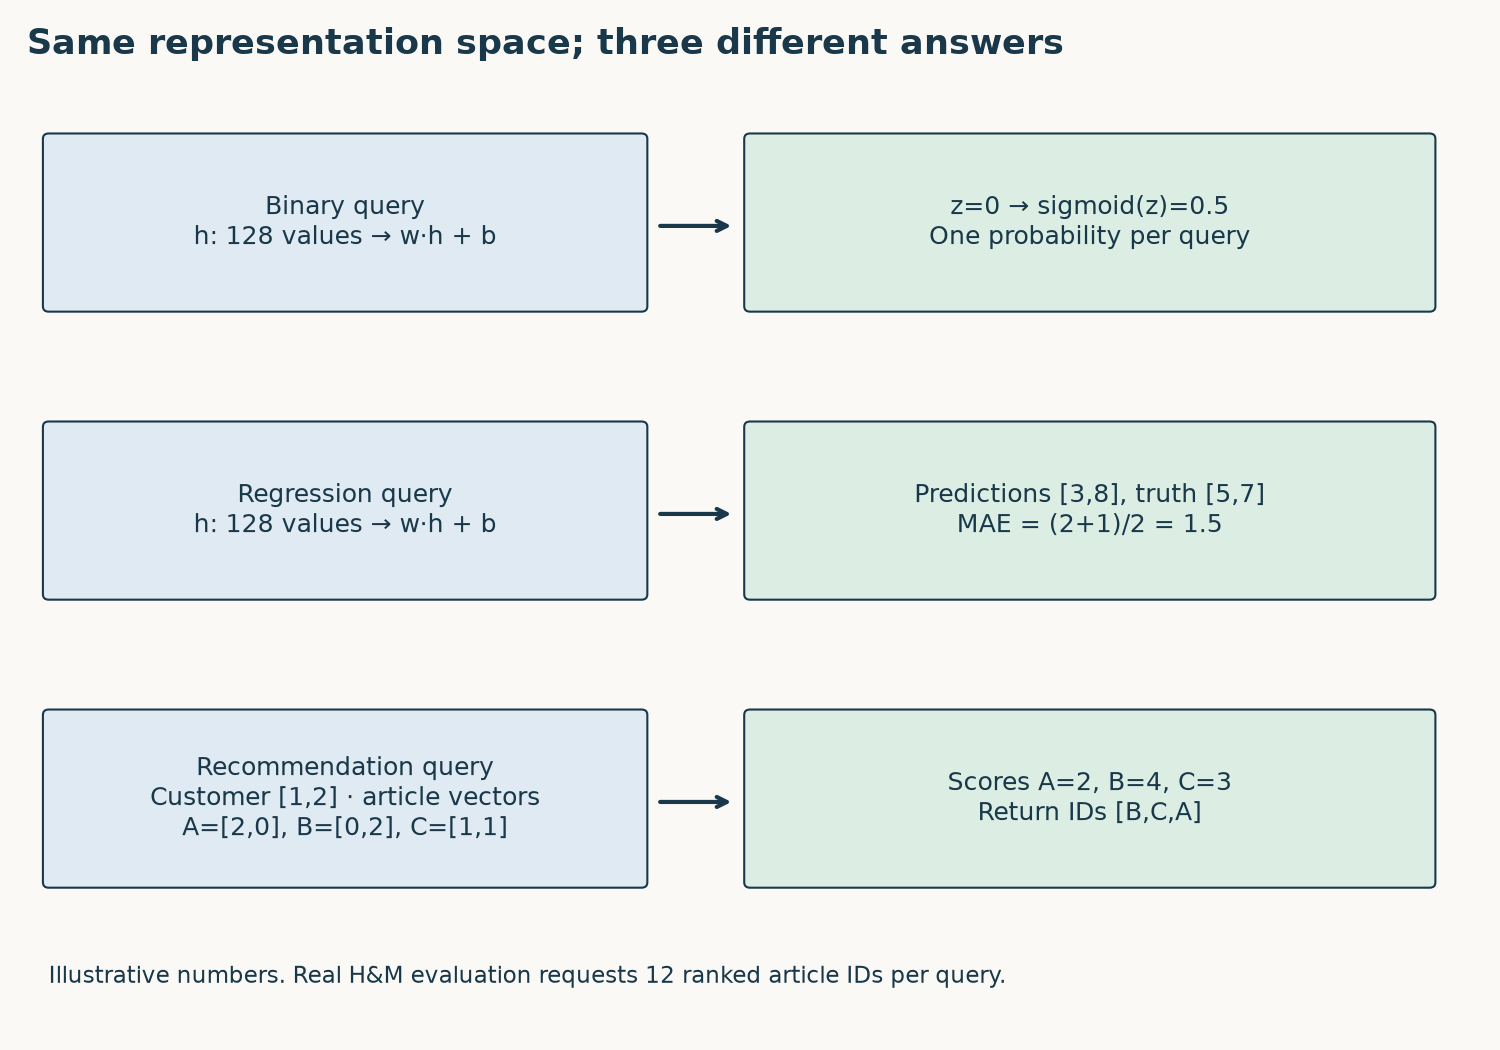<figcaption>Illustrative values distinguish a probability, a numerical prediction and ranked candidate IDs. The head shape alone does not identify the task.</figcaption></figure>

**Worked example: classification.** A driver embedding h has 128 entries. A linear head computes `z = w·h + b`, one number. For `z=0`, the predicted probability is 0.5. Binary cross-entropy is `−y log(p) − (1−y) log(1−p)`. If the true label y is 1, increasing p reduces the loss. `BCEWithLogitsLoss` computes this stably from z: do not apply sigmoid first and then feed the result to that function.

**Worked example: regression.** Predictions `[3, 8]` and targets `[5, 7]` have absolute errors `[2, 1]`. MAE is `(2+1)/2 = 1.5` finishing-position units. The head must retain numerical magnitude. Replacing those outputs with binary decisions destroys the information the metric needs. The released F1 regression evaluation clips outputs to training-label percentiles; the classification path has no such clipping.

**Worked example: recommendation.** A customer vector `[1,2]` scores article vectors `[2,0]`, `[0,2]`, `[1,1]` by dot product: scores `[2,4,3]`. The ranking is article B, then C, then A. The evaluator needs the article IDs in that order. Returning those three floating-point scores instead of IDs violates its input contract.

The two-tower example uses the same encoder parameters for source and destination representations, with table-specific encoders inside the model. BPR means **Bayesian Personalized Ranking**: prefer an observed positive destination over a sampled negative. With positive score 4 and negative score 2, the loss is `log(1+exp(2−4)) ≈ 0.1269`. Negative sampling defines this training comparison; full-candidate ranking defines the evaluation comparison. A sampled binary AUROC is not automatically a recommendation MAP result.

**Check.** Which part changes when regression becomes binary classification? The number of output columns can stay one. Its meaning, loss, evaluation transform and checkpoint-selection direction change.



## 3 · Follow the classification forward pass

The selected experiment keeps the relational encoder from Lessons 117 and 127. It changes the target contract and training/evaluation path. The following architecture is the actual classification lane, not the illustrative two-dimensional recommendation example.

<figure class="stream-figure" tabindex="0">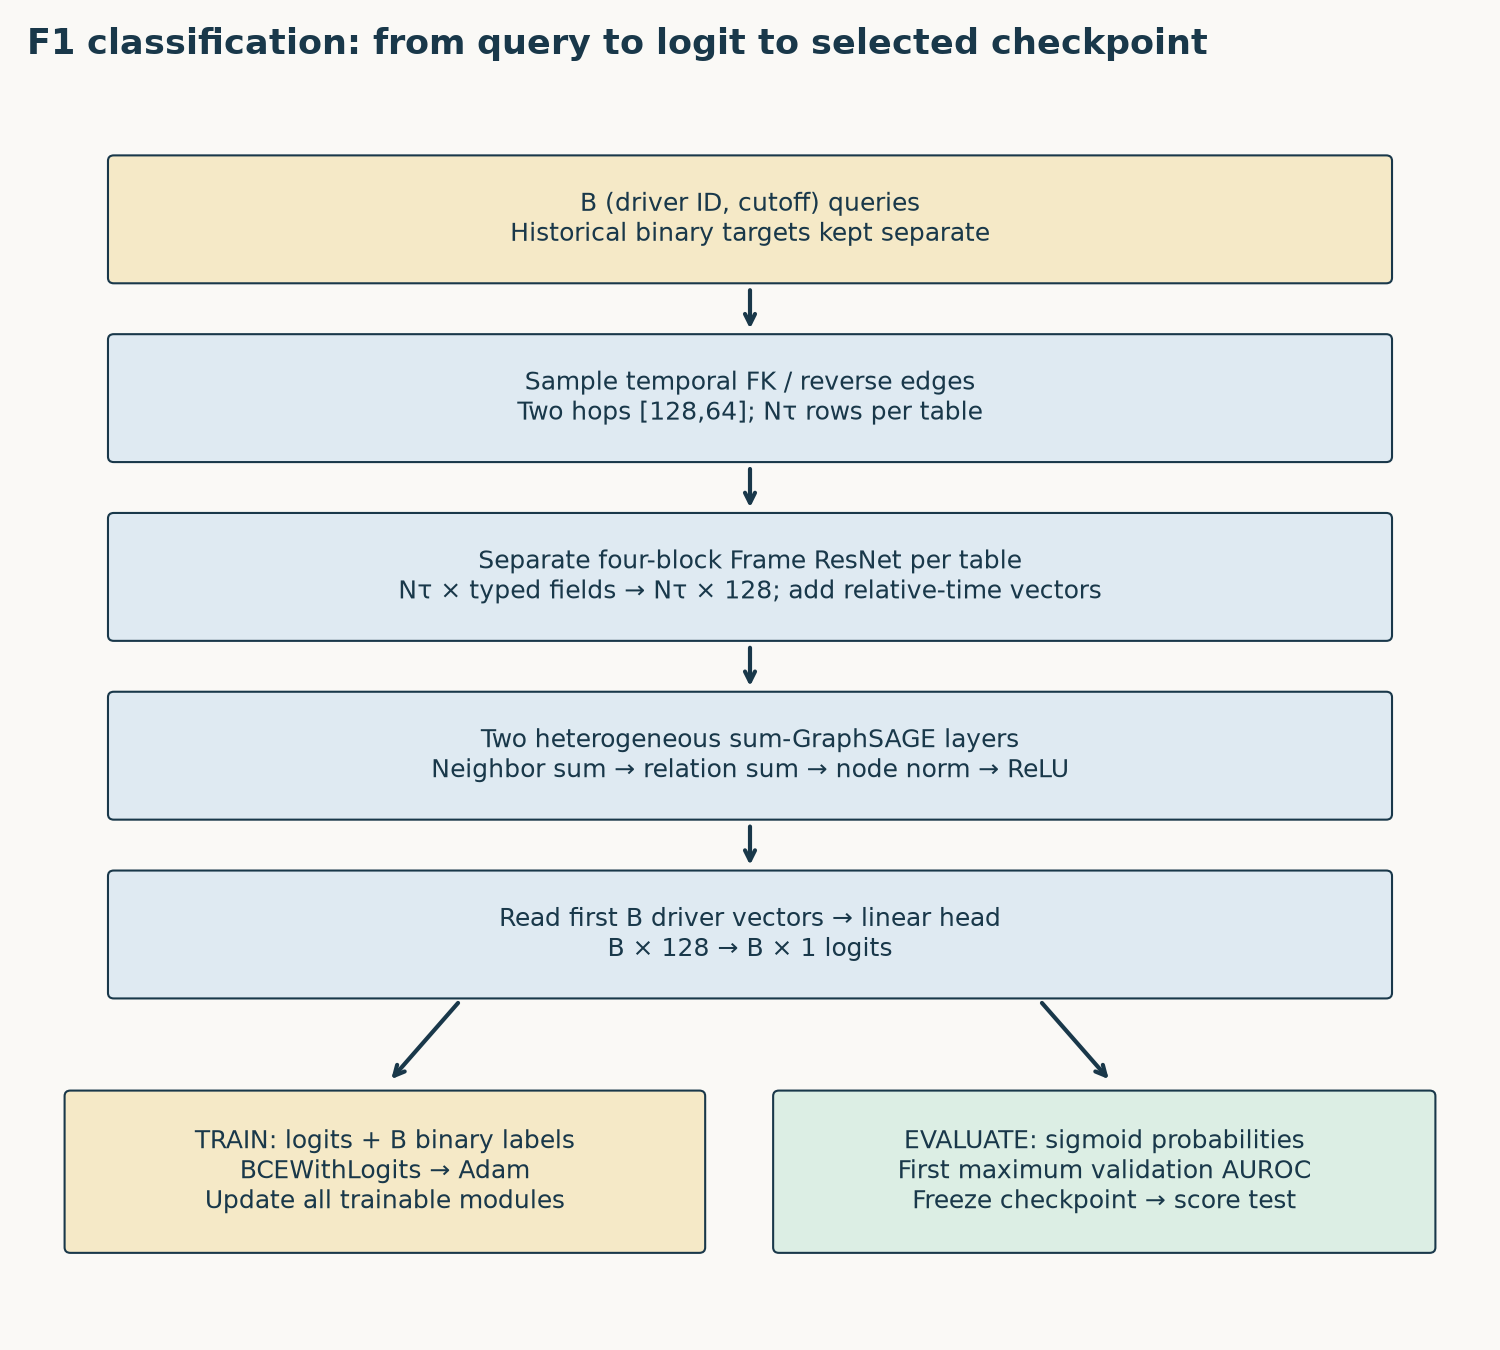<figcaption>Actual F1 binary-classification path: typed row encoders, relative time, two sum-GraphSAGE layers, seed-only logits, BCE training and validation AUROC selection.</figcaption></figure>

**Diagram trace.** Locate the binary head and sigmoid. What changes from regression even though the output still has one column? On a narrow screen, scroll the figure sideways.

**Start with the question.** A batch contains B `(driverId, seed time)` pairs. The seed time is the prediction cutoff. Two queries for the same driver remain separate; the sampler builds disjoint context copies for them.

**Build the input.** Foreign keys and reverse edges connect the nine F1 tables. Two-hop temporal sampling uses fanouts `[128,64]`: these bound sampled neighbors per relation at successive hops. Every dated row must be no later than its own root query time. Targets remain separate from input features.

**Encode rows.** Each table has its own four-block PyTorch Frame ResNet. Numerical, categorical, time and text fields become row vectors with 128 coordinates. A relative-time encoder turns `seed time − row time` into an additional vector, measured in days before encoding.

**Pass messages.** Two heterogeneous GraphSAGE layers sum neighbors within each relation, sum relation outputs, then apply node-wise normalization and ReLU. A ReLU replaces negative coordinates with zero. Nτ denotes the number of sampled rows of table type τ; these context counts can greatly exceed B.

**Read the answer.** Only the first B driver vectors enter the scalar head. The B labels are attached by task-row identity, not by driver ID alone. Adam updates the encoders, message-passing layers and head using mean binary cross-entropy. Evaluation applies sigmoid and selects the first epoch with maximum validation AUROC. The test set never chooses the epoch. [Visible shared model](https://avistian.github.io/relational/labs/relkit/rdl_l117.py) · [Visible classification trainer](https://avistian.github.io/relational/labs/relkit/classification_l128.py).

```python
for epoch in range(1,epochs+1):
    model.train();loss_sum=0.;count=0
    for batch in loaders['train']:
        batch=batch.to(device);optimizer.zero_grad()
        pred=model(batch,task.entity_table).view(-1)
        loss=torch.nn.functional.binary_cross_entropy_with_logits(pred.float(),batch[task.entity_table].y.float())
        loss.backward();optimizer.step()
        count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
    assert count==11411
    val,_,_=predict(loaders['val'])
    score=binary_auc(tables['val'].df[task.target_col].to_numpy(),val)
    trace.append(dict(epoch=epoch,train_bce=loss_sum/count,val_auc=score,train_queries=count))
    if score>best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
    print(json.dumps(trace[-1]),flush=True)

```

> **Scope check.** The released preprocessing fits feature statistics using the database through the test cutoff. This is not train-only preprocessing. Actual arrival times, mutable-feature histories and creation dates for undated rows are unavailable. The reproduction preserves and discloses these limits; the batch audit checks the timestamps and graph identities that do exist.



## 4 · Compute the metric before trusting its name

### AUROC is a comparison between classes

**In plain terms.** AUROC measures how often a randomly chosen positive gets a higher score than a randomly chosen negative. A tied pair receives half credit. It measures ranking, not the accuracy of a 0.5 decision threshold and not probability calibration.

**Worked example.** Labels `[0,1,0,1]` have scores `[0.1,0.4,0.4,0.8]`. The positive scores are 0.4 and 0.8. Against negative scores 0.1 and 0.4, the four pair credits are `[1,0.5,1,1]`. AUROC is `3.5/4 = 0.875`. Both classes are required. With only one class, this lesson rejects the metric as undefined.

**The same AUROC can hide very different probability errors.** Keep two labels `[1,0]` and compare two predictions:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:.4em .25em"><thead><tr><th>Probabilities</th><th>AUROC</th><th>Mean BCE</th></tr></thead><tbody><tr><td>[0.60, 0.40]</td><td>1</td><td>0.5108</td></tr><tr><td>[0.99, 0.98]</td><td>1</td><td>1.9610</td></tr></tbody></table>

Both rank the positive above the negative. But the second prediction assigns probability 0.98 to a negative outcome. Its mean binary cross-entropy is `−(log(0.99)+log(0.02))/2 ≈ 1.9610`, compared with `−log(0.60) ≈ 0.5108` for the first. This two-example calculation is a loss comparison, not a population calibration estimate. It shows why a perfect ranking metric does not certify useful probability values.

**Try the decision rule.** Classify a row as positive when its probability is at least 0.5. What accuracy does each pair attain, and why did AUROC not reveal that difference?

<details><summary>Check the output meanings</summary><p>The first pair classifies both rows correctly; the second predicts both positive and gets one of two correct. AUROC only used the ordering of the two scores. Decision quality depends on the threshold and its costs; probabilistic loss uses the actual probabilities.</p></details>

<figure class="stream-figure" tabindex="0">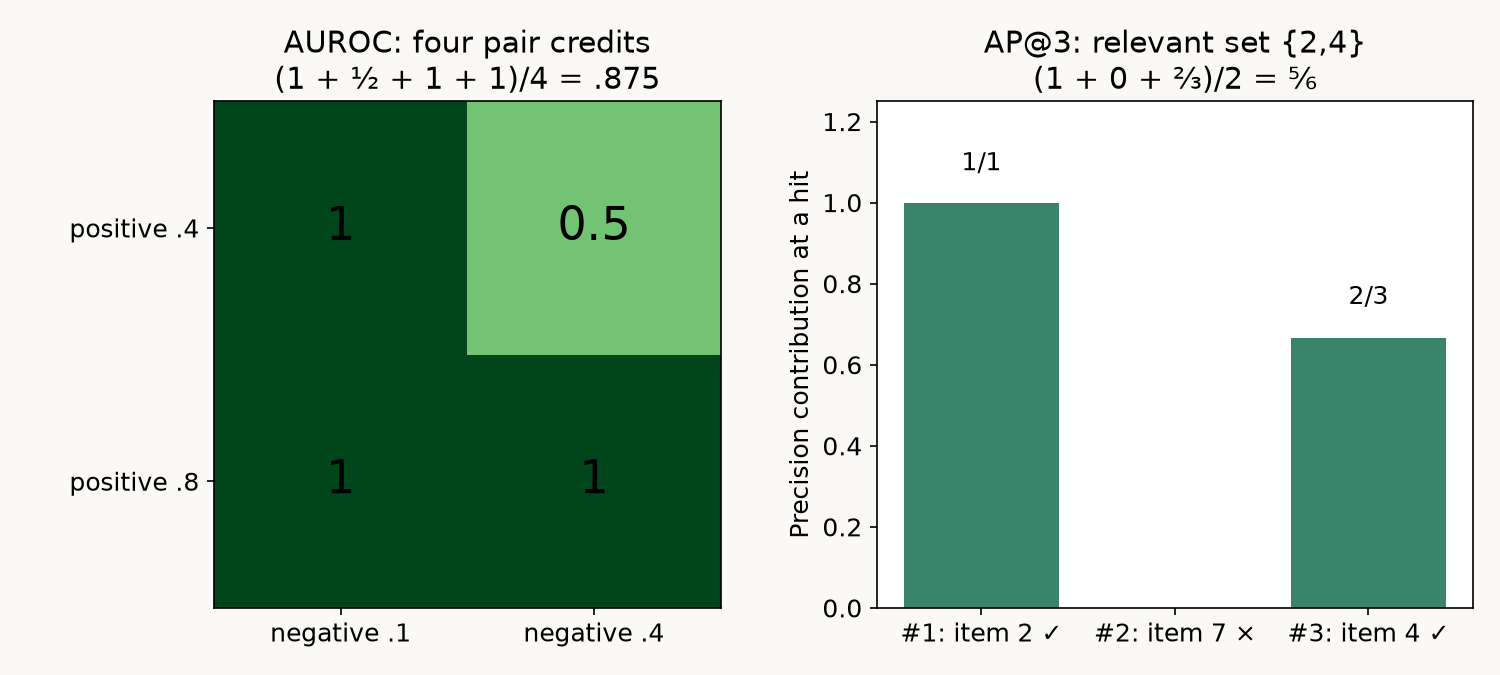<figcaption>Synthetic worked arithmetic. AUROC averages four pair credits; AP averages precision contributions at relevant ranks, with the stated denominator.</figcaption></figure>

**Predict before changing the scores.** Will changing the decision threshold alter this AUROC? Will swapping two article ranks alter MAP? Try the controls; the original result remains visible.

Static metric trace: threshold changes the example accuracy but AUROC stays .875. AP@3 for [2,7,4] is .833333; [7,2,4] gives .583333; [2,4,7] gives 1.

### MAP preserves each recommendation query

A **relevant item** is an article in that query's future target set. Precision at rank r is the fraction of the first r items that are relevant. For each query, average precision at k adds precision only at relevant ranks, then divides by `min(k, number of relevant items)`. **MAP** is the mean of these per-query values. The pinned RelBench implementation excludes queries with zero relevant destinations. [Metric implementation](https://avistian.github.io/relational/labs/sources/l128/metrics.py).

**Worked example.** Relevant items are `{2,4}` and the top-three list is `[2,7,4]`. Precision at the relevant ranks is 1 and 2/3, so AP@3 is `(1+2/3)/2 = 5/6`. A second query with relevant set `{9}` and ranking `[8,9,3]` has AP@3 = 1/2. The macro mean is `(5/6+1/2)/2 = 2/3`. “Macro” means each eligible query gets equal weight. Flattening all source–destination pairs instead computes a different quantity.

A duplicate item cannot legitimately occupy two recommendation slots. The lab rejects duplicates before scoring. It also checks list length and preserves candidate IDs. The released evaluator assumes valid recommendations; a wrapper should enforce that contract.

**Where does Hits@k fit?** “At least one correct item in the first k” is a useful hit-rate convention. With multiple true destinations it differs from recall@k, which divides the number retrieved by the number relevant. State the convention. H&M's pinned primary comparison uses MAP@12; do not relabel a hit rate or sampled-negative score as that benchmark result.



## 5 · Future prediction does not imply autoregression

**Temporal prediction** means asking at time t about a target after t, using only information allowed at t. All three task families above can be temporal. Their heads can differ while they share a database's chronological train/validation/test boundaries.

**Autoregression** is a factorization: later output predictions condition on earlier output values. A sequence distribution can be written `p(y1,y2|history) = p(y1|history) × p(y2|history,y1)`. At generation time the first predicted output can become input to the next step. In **teacher forcing**, training supplies the true earlier output; deployment may instead supply a generated one. This can change the input distribution and allow errors to accumulate. [Bengio et al., Scheduled Sampling, §1](https://arxiv.org/abs/1506.03099).

<figure class="stream-figure" tabindex="0">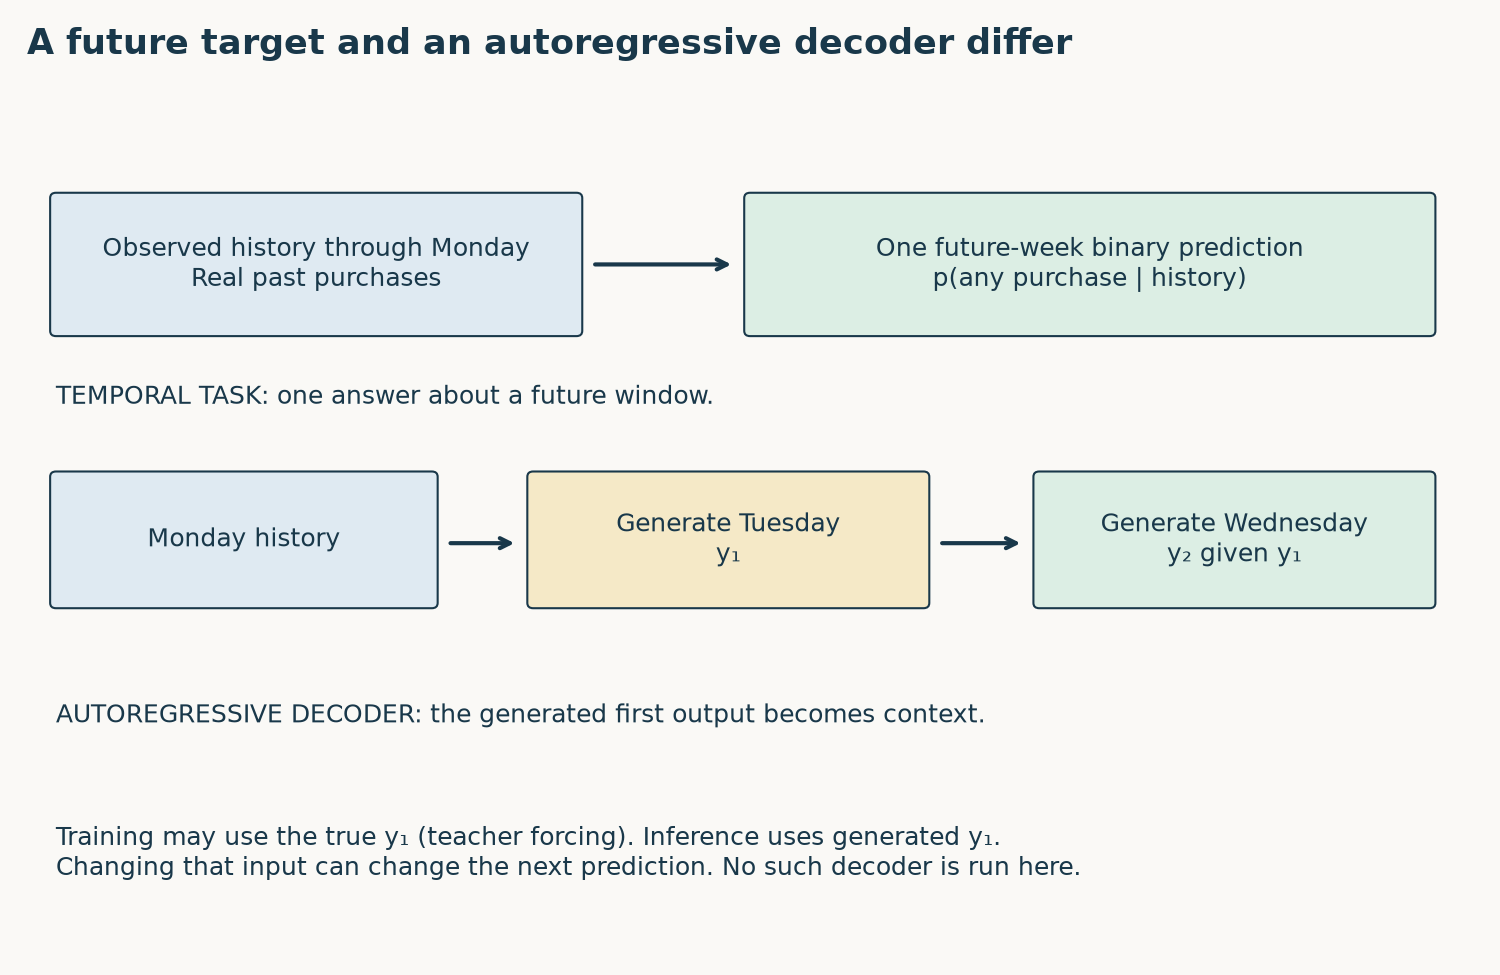<figcaption>Future binary prediction produces one answer; an autoregressive decoder feeds its first generated output into the next prediction. No autoregressive model is run.</figcaption></figure>

**Worked contrast.** At Monday's cutoff, predict whether a customer buys anything in the following week. That is one future binary target. An autoregressive sequence model might instead generate Tuesday's event, append that generated event to its context, then generate Wednesday's event. Merely using last week's observed purchases as features is not evidence of an autoregressive decoder.

The pinned RelBench `TaskType` enum has no `AUTOREGRESSIVE` entry. The curriculum shorthand “entity / link / autoregressive” mixes different axes. This lesson uses entity versus recommendation for the output contract, temporal for information availability, and autoregressive for a separately explained decoding mechanism. No autoregressive benchmark run is claimed here.

**Split discipline.** For F1, validation begins 2005-01-01 and test begins 2010-01-01. A label must be mature before fitting: its complete future window must have elapsed. The released task generator places training queries so their horizons end by validation. The database cutoff alone is insufficient: each sampled dated node must also obey the particular query cutoff.



## 6 · A task name survived a label change

**Predict first.** Suppose every binary label is replaced by `1−y`. If you keep the old scores unchanged, what happens to AUROC? If you also replace each score by `1−p`, what happens? Explain before checking: reversing only labels gives `1−AUROC`; reversing both preserves AUROC, including half-credit ties. Preserved AUROC does not prove preserved label meaning. This identity assumes the transformation preserves ordering and ties; finite-precision rounding can create new ties. The notebook promotes stored float32 scores to float64 before subtracting them from one.

The initial pilot rejected the current `driver-dnf.zip` because its hash differed from the pinned package registry. Inspection found an upstream [label-flip commit](https://github.com/snap-stanford/relbench/commit/c348273a8e66). The historical task's CASE expression returns **one when no future result has `statusId != 1`**. The later definition returns one when any such result exists. Do not interpret the historical positive probability as the literal probability of not finishing.

| Split | Queries | Paper/historical positives | Current archive positives |
|---|---:|---:|---:|
| Train | 11,411 | 1,365 | 10,046 |
| Validation | 566 | 125 | 441 |
| Test | 702 | 207 | 495 |

The reproduction reconstructs historical labels using `1−current_label`. This is supported by the pinned pre-flip SQL, an independent full raw-event audit and a complete task-key/label comparison against that SQL. It is not a guess based on a matching class count. [Historical source](https://avistian.github.io/relational/labs/sources/l128/f1-historical.py) · [Independent label audit](https://avistian.github.io/relational/labs/_data_l128_results.json) · [Original SQL comparison](https://avistian.github.io/relational/labs/_historical_l128_results.json).

> **Scope check.** Original historical archive bytes and row order remain unavailable. The experiment uses the current archive's query order with reconstructed historical labels and records that deviation. The task SQL also conditions on future participation and has no upper cutoff in its recent-driver eligibility subquery. A past-only 365-day audit finds 1,022/27/26 train/validation/test queries with no observed prior-year result. These are descriptive audit counts, not a silently changed experiment population.

**Why this belongs in taxonomy.** A name, a binary dtype and a scalar head do not fully specify the task. The target event and its polarity must be explicit. This is also why [Lesson 129's manual-feature comparison](https://avistian.github.io/relational/lessons/0129-manual-feature-engineering.html) must share the exact same labels and query population.



## 7 · Full selected experiment and what it establishes

The target is **RelBench paper v1 Table 6, F1 driver-dnf RDL**, five runs: validation AUROC 71.36 ±1.54 and test 72.62 ±0.27, in percentage points. The lesson predeclares a descriptive tolerance of 2 percentage points on each mean. The figure reports sample seed standard deviation; it is not a confidence interval or equivalence test.

The experiment trains all 11,411 task rows for ten epochs per seed. Configuration: width128, two sum-GraphSAGE layers, fanouts `[128,64]`, batch512, Adam learning rate0.005, uniform temporal sampling, seeds0–4. Each run selects by validation only and saves final query IDs, times, historical labels, probabilities, checkpoint hash and every epoch's trace. All final predictions are checked against the original model on the same sampled batches.

**Author execution: COMPLETE selected experiment with reconstructed historical labels.**

| Split | Fresh mean AUROC (%) | Sample SD (pp) | Paper mean (%) | Verdict |
|---|---:|---:|---:|---|
| val | 71.8781 | 1.2939 | 71.36 | CLOSE |
| test | 71.6708 | 1.1760 | 72.62 | CLOSE |

| Seed | Selected epoch | Final validation AUROC (%) | Test AUROC (%) |
|---|---:|---:|---:|
| 0 | 4 | 70.2748 | 70.1288 |
| 1 | 10 | 73.4857 | 72.8239 |
| 2 | 9 | 72.6639 | 71.7152 |
| 3 | 10 | 72.0363 | 70.9042 |
| 4 | 10 | 70.9297 | 72.7819 |

All **6,340** final predictions independently rescored; **605,190** sampled query occurrences audited. Maximum original-model raw-output difference **9.54e-07**. Successful pilot plus five fits: **USD 0.078022** worker estimate, excluding setup/storage/unitemized overhead. Failed first pilot conservatively reserves another **USD 0.812592**. Seven of eight one-hour worker reservations consumed. This is not an invoice total. [Full evidence](https://avistian.github.io/relational/labs/evidence/l128/summary.json).


<figure class="stream-figure" tabindex="0">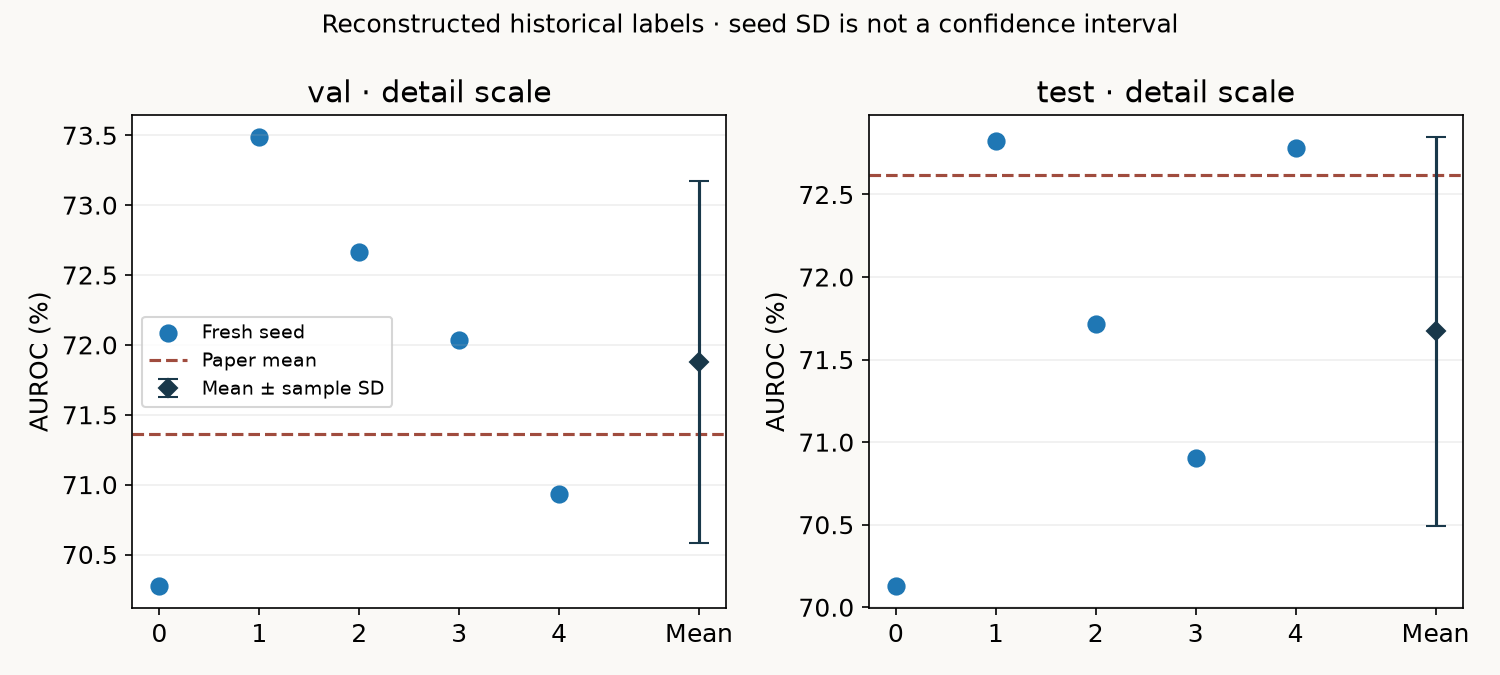<figcaption>Five fresh complete runs with reconstructed historical labels. Dots are seeds; diamonds show mean and sample seed SD. Dashed lines are paper means; axes use detail scales.</figcaption></figure>

**Keep evidence separate.** The numerical lane is a complete selected experiment using reconstructed historical labels. It is not a whole-paper reproduction. Recommendation metrics in this lesson are executable course exercises, not a trained H&M result. The default notebook replays complete author evidence; its explicit training gate performs a new fit only when enabled in the pinned environment. Source parity, a close mean and author execution do not establish historical identity or learner mastery.



## 8 · Lab and written defense

**TODO 1 — contract.** Implement `task_contract`: route three kinds of questions to their output, loss, metric and direction. The classification trainer calls this function before fitting. Reject temporal/autoregressive as substitutes for an output type.

**TODO 2 — AUROC.** Implement positive–negative concordance with half-credit ties. Reject invalid labels, nonfinite predictions, length mismatches and one-class inputs. Then use your function to independently rescore every author prediction.

**TODO 3 — MAP.** Implement per-query AP@k and macro averaging under the pinned convention. Enforce unique ranked candidates and exclude empty targets. Check against RelBench's metric on randomized examples.

**EXIT — submit a three-task contract table**, including query identity, exact target meaning, output dimensions, training loss, metric direction, candidate universe where relevant, horizon and chronological split. Attach your implementations and answer:

1. Why can regression and classification share a B×1 head shape but require different training and selection logic?
2. Why is high sampled-negative AUROC insufficient evidence of high full-candidate MAP@12?
3. Why does a future label not imply autoregressive decoding?
4. What does the DNF label reconstruction establish, and which historical identities remain unknown?
5. What claim do the five runs support about relational learning, and what additional matched manual-feature comparison would you need?

Write your explanation before comparing the evidence.

Ask the teaching agent about any unclear formula, trace or reproduction discrepancy. Submit your written defense for feedback; **PENDING_WRITTEN_DEFENSE** remains the learner status until it is assessed. Tomorrow, reconstruct the three contracts without notes; in one week, recompute the tied-AUROC and two-query MAP examples; in one month, audit an unfamiliar task's label meaning and metric inputs.

<!-- sequence-next:start -->
**Carry this forward.** Construct the strong feature-engineered competitor under the same question contract. [Continue to Lesson 129](https://avistian.github.io/relational/lessons/0129-manual-feature-engineering.html).
<!-- sequence-next:end -->


## Implement the task contract and metrics

Hints: time is a separate axis; tied positive-negative comparisons earn half credit; MAP normalizes inside each query before averaging.

In [2]:
import math,json
def rejected(fn,*args):
    try:fn(*args)
    except ValueError:return
    raise AssertionError('Invalid input was accepted')

### TODO · task_contract

Return fresh contract metadata. The full classification trainer calls this function; verify loss and selection direction.

In [3]:
def task_contract(kind):
    """Return the chosen released baseline contract; time is a separate axis."""
    choices = {
        'binary': ('one_logit', 'BCEWithLogits', 'roc_auc', True),
        'regression': ('one_scalar', 'L1', 'mae', False),
        'recommendation': ('candidate_scores', 'BPR', 'map', True),
    }
    if kind not in choices:
        raise ValueError('Use binary, regression or recommendation; time is orthogonal')
    head, loss, metric, maximize = choices[kind]
    return dict(head=head, loss=loss, metric=metric, maximize=maximize, split='temporal')

In [4]:
def check_contract(fn):
    a=fn('binary');b=fn('regression');c=fn('recommendation')
    assert (a['head'],a['loss'],a['metric'],a['maximize'])==('one_logit','BCEWithLogits','roc_auc',True)
    assert (b['head'],b['loss'],b['metric'],b['maximize'])==('one_scalar','L1','mae',False)
    assert (c['head'],c['loss'],c['metric'],c['maximize'])==('candidate_scores','BPR','map',True)
    assert all(x['split']=='temporal' for x in [a,b,c])
    rejected(fn,'autoregressive');rejected(fn,'temporal')
    a['metric']='changed';assert fn('binary')['metric']=='roc_auc'
check_contract(task_contract)
print("PASS: task_contract")

PASS: task_contract


### TODO · binary_auc

Compute all positive-negative ordering credits, validate inputs, and average. The real evidence replay below calls your function.

In [5]:
def binary_auc(labels, scores):
    """Probability a positive outranks a negative, with half credit for ties."""
    if len(labels) != len(scores) or not all(y in (0, 1) for y in labels):
        raise ValueError('Aligned binary labels required')
    if not all(math.isfinite(float(s)) for s in scores):
        raise ValueError('Finite scores required')
    positive = [float(s) for y, s in zip(labels, scores) if y == 1]
    negative = [float(s) for y, s in zip(labels, scores) if y == 0]
    if not positive or not negative:
        raise ValueError('AUROC requires both classes')
    return math.fsum((p > n) + .5 * (p == n) for p in positive for n in negative) / (len(positive) * len(negative))

In [6]:
def check_auc(fn):
    assert fn([0,1,0,1],[.1,.4,.4,.8])==.875
    assert fn([0,1],[1,1])==.5
    assert fn([0,1],[1,0])==0
    assert fn([0,1],[0,1])==1
    rejected(fn,[1,1],[.1,.2]);rejected(fn,[0,2],[0,1]);rejected(fn,[0,1],[1]);rejected(fn,[0,1],[0,float('nan')])
    from sklearn.metrics import roc_auc_score
    import numpy as np
    rng=np.random.default_rng(128)
    for _ in range(80):
        y=np.r_[0,1,rng.integers(0,2,20)];s=rng.integers(0,5,len(y))/4
        assert abs(fn(y,s)-roc_auc_score(y,s))<1e-12
check_auc(binary_auc)
print("PASS: binary_auc")

PASS: binary_auc


### TODO · ranking_map

Keep query boundaries and ranked order. Validate unique IDs; use the pinned normalization and empty-query convention.

In [7]:
def ranking_map(truth, ranked, k):
    """Released RelBench macro MAP@k: exclude queries with no true destinations."""
    if not isinstance(k, int) or k < 1 or len(truth) != len(ranked):
        raise ValueError('Positive k and aligned queries required')
    values = []
    for relevant, row in zip(truth, ranked):
        relevant = set(relevant)
        if len(row) != k or len(set(row)) != k:
            raise ValueError('Exactly k unique ranked candidates required')
        if not relevant:
            continue
        hits = 0
        terms = []
        for rank, candidate in enumerate(row, 1):
            if candidate in relevant:
                hits += 1
                terms.append(hits / rank)
        values.append(math.fsum(terms) / min(k, len(relevant)))
    if not values:
        raise ValueError('No queries with positive destinations')
    return math.fsum(values) / len(values)

In [8]:
def check_map(fn):
    # q0 AP=(1 + 2/3)/2; q1 AP=1/2; q2 excluded (zero positives).
    assert abs(fn([{2,4},{9},set()],[[2,7,4],[8,9,3],[1,2,3]],3)-2/3)<1e-12
    assert fn([{1,2,3,4}],[[1,2]],2)==1 # denominator min(k, number relevant)
    rejected(fn,[{1}],[[1,1]],2);rejected(fn,[{1}],[[1]],2)
    rejected(fn,[set()],[[1]],1);rejected(fn,[{1}],[[1]],0)
    from relbench.metrics import link_prediction_map
    import numpy as np
    rng=np.random.default_rng(128)
    for _ in range(40):
        truth=[set(rng.choice(20,size=int(rng.integers(0,10)),replace=False).tolist()) for _ in range(8)]
        ranked=[rng.choice(20,size=5,replace=False).tolist() for _ in truth]
        hit=np.array([[v in t for v in row] for t,row in zip(truth,ranked)])
        count=np.array([len(t) for t in truth]);assert abs(fn(truth,ranked,5)-link_prediction_map(hit,count))<1e-12
check_map(ranking_map)
print("PASS: ranking_map")

PASS: ranking_map


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## REPLAY · every author validation and test prediction

Use your AUROC implementation and check inversion symmetry. These are reconstructed historical targets, not literal current DNF probabilities.

In [9]:
# PROVIDED: rescore ALL real author probabilities using YOUR binary_auc.
import io,base64,hashlib,json,statistics
from pathlib import Path
import numpy as np
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQAPaBmH//////////8MABQAdmFsX3ByZWQubnB5AQAQAFgJAAAAAAAAZAgAAAAAAACdVPkjFfgetVXkVriU0KqUh6QivO/niLJEm2hRogVFg7LUUFmuLVtuJDtXJSplMpUsN1EYIomUMjUtSiXKmkTj/Qvv/HbOD+eXsyRs2LJ+k52oyBGRY4ucnL33eS0ynLuIuaxYpDl3kYunl4/XHg9HTy8n5//pZnt+83Ye170P7DnkPM4X6+rpaaprzj0x9//G5FiFPxi/vIs+zjJCusVjyIQP0EBcJma1SwMq3YymCGlvXhklfhKhh7ES2HS0iawDzZmIOyP3jZtJlFtJJT3J+OviCNkWjzC5E6nIGxXBdd5W7Ns6ET3bM1jr7SwYki9b1ZJKn59Np8EMOzbBiY9MVx7T3RyDmXoCNnV6DJSC1EjGuxQJO3Vh83yASLKOddl1UFxbM1scFQ0TQx16qMTHwpOxeBesRMpDKbiZkIkiW1lSK0yBmvstFmwwnWrX8lh5xA1a9XiERu1HmKQOD64WM8kjvIZCc4QsdVswROY1sDXiYThzi4OokGrsXurLrDJSqHCJFZscrkAOFTw4OIbT/DP36HJ4HOZ5baAu5y42vOA03vkfYi/t22hadAM8etIxhyeAd0AM8t2tWZV7InjFutTlHwRTXS69906lwDvP6aYJlw4PC0hFYSrOdl4GnXmInesUYTc2n4pNK6EjoYkAjXpqNGvEF4NOamyzxC7XCuZW+JG+tZXh77f6MHASQef9JNa0iINjUnxUuJ1E66sgFqN6Fo7GxnDI+kId5k24clyJfJLlqexMIhplT+GX5w+WXn2RLUyKglV/Nn5G/6Tq7J1QOPGA7hstpNWeYdDjvmIud3to1wZrTN21Dt8Lnci6u5f+UnlB3zQ84TaaTEUqx8nToJy1vfKjPcsSaOOFZBrkHqHWFRco5ccwa9h7lEquRyEvJ4IOtVRSVCsHuSumUOJHG7yIFkJ/20SUVpaSc0sfM/hdEg7nJPArto/lXN4Nr/Mj9ODmOSiEd1J1ugDpR9ShE8hwPk0ETaniyEk0wv2WfNhU+zCZvDgMrP/A/ltjx9zLr5NtPI+Z+dbQdzcBm8T/Rv77rVjejVrWmb2A1j+Kg+ayFiZd20eW1tl4KnoRlzxraJpxN+Urd7E2j372vfAdXXvbTZHn79Gw6yiZrN8BC6c9GNX6SYb3fVnTl0g8OJBNxQIJ8CyqwC+XgoatENyZ0+B3ciPG7Lbj+JkPLGvJIexapQY9/RaKufqcHOMqkCqqjlrpBQgN7qC+9nLoXytgzS6qJK1cwYaOREP42IN1XSnH7CxR7OgwRj9HSAeNimjz/hpK0cslmTQ52v81Gfn6ASzVe4j1XBRBeswv5qcpirW3OXjkrgSdNjGoLPWhJVpbcNXvFz2e/ppe5ltiDoeDDSo1CFJ1Yi6br0JQE0hXhnn0j+pBNvHNIdQpxLMNfv6QFRQzy45gtEpHQ7vqFnHLwknrtRtdaJpAN4fiELXJFKaLH6I5eRLWjjxAVpEI5sYvg0eiD+t8XsVS1EPwH5Px/ToMMYVOM2rrHmTc+GjUBa6mwBo5iq8ppUEZRZJSlsZDNREor1SFpb4O+dnF4NlQEqoD8iDTnIdh9STyEJcj4RCD4e2t2DxFFhePapCk4mHmsbGPFGvW4ZK9DyvZ/ZHs5R5i/jUrDPc2YHuYCerCe6gzrIdcfdfA/U0jLIt9WWbuIBW2r8YT3TqU6/GR55qAszfPMa/hWKR1GrF27mncPRwP6RE5OvGnJjltj0BRqy0J26+w7blBeK9XS78XzCAppRm0srSGEktUoaiWx3rURLE36RJCK/1R2eCPbdo81Ovm0YfGDBSOewpEE6Alb0F/mHWwpc8/MnEjG+obi4O02Ux6q2uG5Q86ySK9Ggn7ViFM5RWVTmxEy2llsuoIRIulDq2YHwvbRxnYtaWLejMUxnstSTaDl+jq9FzMdklGb5UPS9NPwzSjKBTdtabofxIRMxICsTx/WPrko7ayAGtbcuE2IxSO2VEQXk7Dvk0TsamwgzlZcsC/1sGKyrWopUWDJNp9ma+vLYSOAyS9o44KtF7SYoskBPdz8EF+OWoNBHh6YRMCco2ByGTifIuF0tmjePGnArwNMhHCVSPp2zEQby5gMcJI1pm6mLJK5tFpFROW4xCLsY5vbAJnLbW/P4XL9YMsVD8WF1IiICk2geZpZMKh5wkllFdBb0EU3TB4QbWWiSjYFYl5hieZQa88KY5V0vy0U1S3MR1SY3xsUewiLX4jiiOt0M1dw/oT7Fi2C4/ZzRCwCBt1vFTuoKqfQnzS76ZVabo4xppQUPSYFBxTqdlcQM6q9ZQ9Mv5Bih9JqcMWK6VLYd2cCv66bHwT5yDM4wOp9WpQ+dd6KtgmBpflO8D/e4Q95UzA5L4SmBcU0sEfIWyHUQQTm/SAcDcSB9Tk6fPEO+QWnYfvS78wD5lIdB2XxR23TqYafx5jTqV4e8gabI4o4pUlcP/1eqSIrGJ8rh69tZTBvXpR9FaIkSzNwvKcdxRi+pMNKWlD2UwMRhUKVLc1n+yLw9kk0ySMCqZDtZ6DrIBRclhiitK076R1ZxIJ/cyRbSlL3YaRdH4gFOIHgtDbEA51Fx7OjDUxsr2MwMkhCDHsJwk04J7mMsAkBdeefGdxacYU5BKD1tsJOP8oEQtN7OmTXRP1zv9EqQvPYUeYJ5XUCyhnH5fMhw3oUlIwFG8HYUyQgZvvuWgqk0OpdhikomLos9ZZ2jpBQEt0BLROPoI07CORZMVH2+x1+KE9nsspKThF38Ec0V/0NWojLh6eSm9fXKcIYSm5ZgywrUXiSAiUIPPH6TAeOE06ZekoC7ChZ2+0aXZWBL5Iq8GZftCKKRJYcEEKW1ZaU//OUPxmnoiKjNn04mcNyWsH4F9QSwMELQAAAAgAAAAhAOmGDTv//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEABYCQAAAAAAAO0AAAAAAAAAm+wX6hsQychQxlCtnpJanFykbqWgbpNpoq6joJ6WX1RSlJgXn1+UkgoSd0vMKU4FihdnJBakAvkapmZmOpo6CrUKZAMuBhIAIxQTUkOsWaTYgyyGTuNjE+smYvyGSw8p+rCpRfYPOWbh8zsx9hNrD7HmUxKW+OzBJk9OeiPkRmLEiU1v5KYNYvMasWGNy43Ephdy8hQxbkH3AznxQsh8QuYSawclbiQ1/HCVgfjMw5VnSCkTiMljpKYdUgAl6YoYcwnFAzHxT4xaYtyCzsdWx2HTw4iG8dmDLz4JlbG41OAyj5AaSvM1uh58+QEAUEsDBC0AAAAIAAAAIQDhhyY+//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAMBIAAAAAAAC1AgAAAAAAAJ2YS2uTQRSGU1tNrdbW1l68T2vj10C2FhHX7hQ3LlxJsBEFsZKIm+Kv8A9b8TybB16+4mxeZnLmnTNzrl9+v3n3+u37pcHPwXl3Olt8nHcvWvfyy/Nu0rpPZ/Mf8+m3D2fz09nf9VfTr4vZxfri8/T77GJ+/OzkZDKetF/tv8favcG/sVl4WPiwcK1wXXLsWxIeFd4svFP4oPCKcLWHn3Gr8Lb2wzvUPngeF7bC3UvO2fdI56KHz0n7h8K9wmXh3cKdwpHkVwr3da7faasQu21IL8/hYXDevubHhdzD9vW9m+SfSC/8y+9gPdnv97GeKz3r8DO4943CZGfHAfFh+6f92NH672gd/eD3O+0JeRf7r+0Lr+MH/i3Jsx+7Ymf2XRXfU53jfSkfWI78Ad9YvN7vPIJ+2AH94LW9HD+2G+eyn/xEvuq7D/tboePD+vTN8SP44NkN8utC63skTPaw3/id7G/Yw3nFc/MSp+bzeaDjzXL83hWmOjCSvPVyffM7cV/7R589Gcmv071ZN8+1whQvjtO+OfnJ9x0H+dQ3pPxJPXBedD5LdmM91Sv8yfr7PPKo61Dis12uF5IXfR7+5/fweznv+72QG/X83tdX8O6pL7E8/ui4dP1w30G8uO8jTnw+6HzrOmd/aFpHjvukeprWfX/PHeepP+P90f++5vBtB96h1o3239Q/e+66iX3s1857nGP/tt7bQv9uPtutFR4Uuu9hfSh581y237L97cf2v40gl+6b/I79XcBUz1Lc2y7O/6mew2v/sr18X/Ok+mY/cz7ALuZHD9cZ+zNyqf+2nj4/9UVe93cWeqTvjRQXvKf58St/xyBvPwZdv50fkv+5P3X8OC+n/A6P81+qJ85b2MH3dP5J/ZfzafoOSP0d55vX/uz/KTyHx/dNcQjiF+bze8P3B1BLAwQtAAAACAAAACEA8wZAQf//////////DAAUAHZhbF90aW1lLm5weQEAEAAwEgAAAAAAAHACAAAAAAAArZdNKGVxGMaPlAXysVA2dBY4NHchInSjSWHhq2RhJC6uj5LLuTdNFxtMU3Mb6WIjNhYzs7CcWfnY+IiiLLAhCxZTFhMWI4kc6d/993be3vd/7r2bX/fs3uc8z/O+Z76xtaG5LU4b08aNXq+/xzQqdMM9WGa4dKPPZwZMz3Cnz+z1vj2v8Qz5vdZz/4BnxGv9zy8pLXUVuPRJ3fEvUdOWZ2bbQ6kRXoYe5hZsWHj0a/SvRfMk/eetxN/nwYtHi/+vrtPj0zSt7Ka+NtmGwbs/ExkSdzK2v1ZbTMhybdZL/Pbhxei04WFRf8eAxHDd6vO0xOxAZuW6xYX+my99qRGeDbes+2yYObZx+1nip8ncvCkbYnro8117KxK7lw6efthwbess4dTiv90q96WkI6Wb0AnqI1iXs3jfakOoU0rFcXhUYvPH8v2gxJOmpOLvEjGdhB6YT8RckNAn2JyUH6i5sPkEoU8goW8EYT6w+aEfoC+ED6AfoC9gvqicYbmCekKfwHxheRKEPhGMVd6ErpSOVK4o/0EdBbF8cf2H5Qrzlao+XJ9h+sD5MR1U/YX1D6UP5jduH3H7m9prTvsb+ou777B8wr5zqh93DzrNI6UT1XNU36n6lNKX6j3oV0xfan9g/lXtRa6fo/Urtk+wHlTtP64ecF4sl6r+itZP3L6j7lVMJ+Enaq9GqxPUBZufusu4PuDeYWJO7L6K1b1Ezcu9n1TvJequpN4vpgu2/2N9X8K7iNujseoJ7neGas6pPU35gPsdRvUC9/5R9YnQSfQBdRdT3+vY/NR9zO0/OLfTebEcOL1DVO85bk6c3hnv+rwCUEsDBC0AAAAIAAAAIQADzpui//////////8NABQAdGVzdF9wcmVkLm5weQEAEAB4CwAAAAAAANoIAAAAAAAAnVZ5VFTnFSfKVirUKANKsI6sLii4R/juDxBRieAGDBCLgBEUjcgakbCpLCPCSQWEQmLS1IAwbCKjjvM0caFRFlnUWoxVEAQRTSXxqNho7LxvQo75N3POO+9897vL7/7u8qZgtb/P2qC3dD7S+dh+c3jcB7H2zlJ7FrHA3kFqH7EzNj42LCpkZ+zmcFG+POzDuHCNPG5rWHS45jx9sdM8hxkO0hTp7/4ZWVkWw2SGLyS382lfejoLqs7CAbdQXDSZhndWPCDZpuNMlHt1v0ctz9zI2NATR3UF1Nj1UFKHGS1TFmCDiznFOBdymfKoGhtrvfDUXMDiXe64DDmmj7WjXfa72YBxFUp3NLBP9TxgoFJDsb+Cfaa6T0YJQdgWm8hMLM4zUS9UX+sr7cIudnVaHXr7DmJKsoRG7pjSqzX5+N7ThhpGMmDUcojrfRt5GWTZDFnWWJjkpqMtWp82Z0loi2shoqwFOH7liWvJSyn0kAfH8XTcn8l0j5zrz3+hS6VpKTDYW8lOj92Pk6UBiGi05rE7o6swoGxHoyqOJcW7kjTPncvnafJxWVCDe7ntONPkgqk3BRQ+LeBYXM9MIiM/T9qa6UFKyVLOqRjHZ2E8W+aWCp2KOM6nVWA8E/MX8w49ugUqZR37cHw/+SanovR5BvsRkWgpfEAud45zHVHXyFwGvYWXUOsj4GStG9Z2taFsSjr3Ld6P2dBHom7xJku893Q9fAu62X2rE+z1ohlUWlED15n2tEdSha31Sq6fd1MHt/u66aF7BPItOnicsYd6KPpLG0Rae2MUX0HJN6zooQz5QRL6+aU2z45Hj7kPJ9sBHnPJRG8Mvr8K36nVKGyS4ezkHHwQXcluOdpQZmcFRN4sBsq4rdvB20xdU8fkeQouF8/xTyoQ6XiMieeuj2tQ8sk0zrXI0yhn62Na4Di2AFYPzeiPrg68fudN0+CUak+fZ51kPvNqOObsDT1UkRuOY2G3OH5PEytYR3VTxxx9fn/n00Yun9bvj9aWaujHnmBoUbK/WFfiYEQTuiuScHmSgOWDq7Hj77Z02qyW43yuo+1LEZOIR8S1eG4/dTTXsbD8Db/yJfbYY/338FGygIcT3kbPzEe0rk/N3jWVYafFQ/pr7jG2JH0CqtuCuc3I/AA4lN+nOa313L513n54DVUyS1MBz9bO53kWT0jHjTGGVKZowTEboPOsABFDw9Vs9LdNpwLnbHwRJ+X9Jj6GBmb0fFiL9375Mnqz7wqvXoLfJhvOb/H3VfANrmRdg3Ko78gwZooeFX6fwmOGSIuY07CUjC8fQoluNvTHZ0HYXQSPWCtKzs5H8TVTmqUIhFtkJfumYD/Ce+/yXliQpOWiZvgUOxvmh6IpWfB7cgiqNGtq+jGT437bMBFi3a/dquLcGqWfYIdz75LM4AXvK+WYx/RO3wa+F8T+LjJO432e0JXK32uMUjlG538F4vFcD3pho0cRcq1M5D/lT0U899E6iXk3yFfRqv9od8al2WX44kAt7Grq2aRzIOefHlBd2c90OMoPx2OrOFceZQ9IovDH7IhrbMD7baiCArDFPBPyly0o7F4KuWoRrrt34EBhG3x8GlhMTw2OPZDDa7sN1Rl0/GbW13tpayFiuzAsx5EGBRvtfVGWM8ENn74vwGHlI/qveS0TIg1RqvJHrOMSSilUcT1Rf9t2BRq7lKy6NgDlQe48v+JncjiEzeK+xeeVyhVmQ2p4teZxLtKmvo/F89Roy/XAwun61PWJlifDt8qxvrMN15Km0pNx2lnstU9g292a4Jr2D4xbaEgjr9Pgu11AxCyA5AUYMTGj8HWdiFB5YDDWH072WXi1fCMeVwVg/EQZr43oe5ymPu0jlezu7l4S6+npLQUbDuf1DH8ayHGJ8r72JqajG4qEeYO8d96cLZGvP+gU4fI7lbDdrNlzoVkc95s1vfU6h5/F79dLlZIN+fphxYm/ISLIlvbJspBnsIyqBW/6XFCynPUBsNt5n77Vm4DkNSEISj3MnE7PINmeClxcrmL+1tpd+rzdgMR3syIFzjMyceV/zUg51Ybreyt4/FtxerQxNQXtKwU0KVbgblEOLPoqWfgeAxLvN7Snc73PxhqSZG06Lmm+iXbGnnidp0/z+7WzJfoXOdhpexAr0iT0nbkhqU20dhVfCjiS7o4iR+354os5sIhsQWVwLKTnZLC86I93/52O6tYDCH4+jbYbVWMwq4H7i4n4CuvmV+O8nT2f7+rBAJib5GDSR5VsluCF9niBc/8yV4bZG/2xLb6K3XbPQUx7ELrawXdzlsYuUqhAR62SHdfMxU+9RjC/8AFmnSxmJY2JiPK2pbr6LOQnlSBbw320xl9unzvd8NfOlsuIhPQdA5Bb8hUSg/K5TNQJseznvfCTXxl7uSoU4Zp6v84LhHh32kiP5h5LRoAmX4c19bzffZNVbOLQUYh4WhLdyTc9EwcTnMgzpgSjOJMSyuC3RcUyTuzFGd1AhL3lDunAJXTOuY7+Xc6IvXeHVg5ZYqjrNOv5WhtTxOByNxl+mhqI8cQczgbvx+qlCna6Q498E1M4jpoGNcb7rIW1pBN2CxR8njOmxvO+G7OoGePK2vEwrZ/qZ07GkfHBeObyJb4xv4Jdm7Q8hJbuw+rBIsTp2RFJMzH/nB9Guk+y1h8Uv+J3iVazkN3FKEvMxrchs6ktaiVl9JvTZoWWt/IlAtwLXPFysoD6LobNpwowa8ckEu/E58gRM7qx5BDPwbRXO2uu5pOxcCiQ57pJ1skaE7S751mRFelbVnE+mx+V49VwIxa9UmNP8yoo9fRIzPnJyWTUdATy/W3suYP72OghIKPeE626Z3Aeq/h/RTFewI00nJmrz+2sJgrY1LkUy79YhOF/GnCZRVUa7l05iN46CU1qnQ1JlRn1XClEdHk2YnKsuY/sX2Z3YIIcUaW21H9KSnnns2F83QuHf1Dj65AmlFxWMOvc/bhp/YDWyNvYaA2vBm/jNcn+ZceO4hr16f258Jv7OF0rOru2juf/f1BLAwQtAAAACAAAACEA+q4Epv//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEAB4CwAAAAAAABsBAAAAAAAAtVWxCsIwEE1Xv6JbFDqICII4uykuDk5SbEVBVFpxEb/CH7YdBIl3716rHpQ218u7l8u95DFfzharyF3dzWd5uSn8OPaT/dAnsd+eikuRHtenIstr/zQ9lHnlL3fpOa/G3VF/kPSS+B63tk7knKsf1qz48L/0rWFo86Qxyo/4WHPfOSJsay0MN8kX5ke1Qrmb+Jvw0jAR38h98tXikKH+QJzaYjbZYynWWh+qE4uF+hXxRPiahtk9szRo6YzBbqMJFkPC1OJDPLYvmV5muVhxWs5f9T5rbB0lP3tusf/ZtUvv0Ic0oWmavV8YQ9qy7g8t7pvaWjFSTbT4X9eJ6TFtny0cC7+tsecayifVmjlLwvz/6gukGWYOay/cJ1BLAwQtAAAACAAAACEAZyKSdP//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABwFgAAAAAAAGUDAAAAAAAAnZhLa1RBEIXvZISoiImEwY3iLIIzSe5kHj4i4ioLd4obF64kmBEFMTIRN+KvcBP9tUbS32I+5tAhvSm6b3V1V9Wp09339+u3r9686zQ/mp+D4/nph8XgeX/w4vOzQdsffDxZfF8cfX1/sjie/x9/efTldH4+fvrp6Nv8vD88mMzanbb/q3/ldvN6c9HWitzrXshhkb0yfqfI20XeKPJvs6z/oPQ3itxsltt+0btb+tea1X30aLZDf6vIwyInZR7Tz8L8tijgB/6Nyjh+Yc/7Gmgd+2F/2N+WxrF3v1mWu2X8VulvB7s0/NuQZP9eH/vYZZ0/0gMXD4u03+z3oLt6ffSZ73nOi+OCv7aLBHf4M1bcZsLztEjyT77JP3kHF9h5Ij3jfyS7xA0/aZsax/5Y87GPXerO+wTfjq/76LWyZ/zbH757fcePefid6hm95Cf2jQvsgktwaj/B27rW3SnyLOjz3fEy3l0H4Mk4I7/mhU6Rrm/sen+Jp5wn55N+212tjx376/Xxg3OARn5S/J33qeIzk1/sL+ELHjMu0nmU6jThuFbXxh2N/SS+Tjw3lF3z86H0kKmu4MPEd+wj8XjifZ8P+PlY5wr3iC1JxtFzPbCO10+8YDybF7weuPV9xvVOPMC/cWDe9H3B506tTxzZP/lL8U73ENfTVHiwPrzoukc/8b3veYmPmIdfxBv8dSR97zH/uB7QSzi3v8TN9WveT/xS4w/ixr6x5/q6V6TznXhgUtlXT3pr+o5+whM4MC+4Hh6JP5hnu17Xde78Gx89jSOpG/Or72m1+sQe8TKPmP9HwpXrbF94Iy72ZzfMx675ifeX8WJeAy/giHeX59XqOd0TzVvb6vPd9W2cpHcGze846hN95/2y9hLux6or4zTNs31/N58lPBsfKf7sz3zt8zvdi80X5ol07pqfEp/5nEz4wk/jFjwPlY90bvm+sB70sGNecJ0nXkj5Z37tHcH+zef4W4uncZPOScYd/+Rnqzoyr/occh3W6sF1D889DfdQZMKPzyfnmTglXiR+8CHbdvyJu++v2COfV/0/ZX5hXvoP5vtV7Vwj395X7V2c/ksk3iWefi+NLhkH/1f0Oynhqrav9L52XGvvqr3uaj3jyv4Rx/R+Sf+HiF+6xzpe3ictzU/5/wdQSwMELQAAAAgAAAAhAGeQ18f//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAHAWAAAAAAAA7AIAAAAAAAC1mD1oU3EUxV8GaXHQ9oEUdIkOvioBtQ5KmylgpYKfqFSolGBTPyhteIk61DgVFwXxA60gRQVRUVSCdCnVqXEpXRxUpJBBUCmCioOIQ1+HSx7HHO99SczyI2/733Puuff/v7bn0O59R2LOGWfUG8jkjvleZ9xLntzuJeLe4Iif99PD/SP+QGbpe3d6KJcJvudOpLOZ4H/7ts0diQ2JeCFe82+549xYyGYftTrOux/v7xcDrv6d+jAVYl/sSctMwInmVd1z/2B55fnRtwHXtX16Xg7xaero9za3wm89pfVrq7Bj/6a+jVWY7x2/sjXEyf7Y62SIvwZP/dkRYufwmy17A547nTzeG+LY1XKyEGLpVo9/wcDmu8UHlwNeejbm3gvx9pfZ6YUQ3fmJZTdbKzz4sanrTohSZ+Hc5Nedj90Kr8+2fy65er2xvkNdP6dWuBViPbEuQu28wl0P18yPB2x5ebjwogoPzLwqTlepg5w7dfFsU979m+I37TxC8Q/6gOktxPMI2XmQqDM7D1L0lD5i/cLOaWW9/aQR+02jpgf2ISPzpfhRiH0pZL5kxH5FYr9i3yKlz2vNSU3fqLrXm6/WXGX6oW6afpqe/1tXTWc2J5Gou5Dpy/Rh8w710fSw6oD5jtTqz+qNc1Dy0tpXrM9kniBRH9Z/1jmkzSecU1qOin5aP7E5rOnD5hLqwPY/JPMzEuuIfrf6m+UN21/Q12yOMx+iv5ivmL+0HGBzAP3E9hzMYawH299Yv0f1kfQn848Qz98oP7B9VqNWp6h7opaHmHdsT2T1izpfWF/WmnPW/QL1QN+xea7VM+pcwbpa57lWd1b/RuUd86v0t+ZXaz2t9zPsby3/rLmn+U+7r7LcY/VgecbqYt3ntfmo3d8bPTdZPkbNTfSb5jttnuC81fJR2wvZXLb2q/X9Cqndy637e637oJXW9y0tn63vPPW+f7F5iDlt3e+1/ZTpVu97I6s/27us919rPaO9SywCUEsBAi0DLQAAAAgAAAAhAA9oGYdkCAAAWAkAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQDphg077QAAAFgJAAAOAAAAAAAAAAAAAACAAaIIAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDhhyY+tQIAADASAAAOAAAAAAAAAAAAAACAAc8JAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDzBkBBcAIAADASAAAMAAAAAAAAAAAAAACAAcQMAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAA86botoIAAB4CwAADQAAAAAAAAAAAAAAgAFyDwAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQD6rgSmGwEAAHgLAAAPAAAAAAAAAAAAAACAAYsYAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZyKSdGUDAABwFgAADwAAAAAAAAAAAAAAgAHnGQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAGeQ18fsAgAAcBYAAA0AAAAAAAAAAAAAAIABjR0AAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAuCAAAAAA', 'sha256': '102573749786451aefdbad0e44103019b50ae1e459a98aaa83d64b66ad531f4e', 'result': {'seed': 0, 'epochs': 10, 'selected_epoch': 4, 'selection_auc': 0.7025668934240363, 'scores': {'val': 0.7027482993197279, 'test': 0.7012882447665056}, 'replay': {'val': {'queries': 566, 'max_original_logit_error': 7.152557373046875e-07, 'sampled_nodes': 162367}, 'test': {'queries': 702, 'max_original_logit_error': 7.152557373046875e-07, 'sampled_nodes': 158747}}, 'trace': [{'epoch': 1, 'train_bce': 0.3733684106604807, 'val_auc': 0.6368616780045352, 'train_queries': 11411}, {'epoch': 2, 'train_bce': 0.32880791858257813, 'val_auc': 0.6815238095238095, 'train_queries': 11411}, {'epoch': 3, 'train_bce': 0.30749692049178806, 'val_auc': 0.6890884353741497, 'train_queries': 11411}, {'epoch': 4, 'train_bce': 0.31003775916737014, 'val_auc': 0.7025668934240363, 'train_queries': 11411}, {'epoch': 5, 'train_bce': 0.30266534666291733, 'val_auc': 0.6794013605442177, 'train_queries': 11411}, {'epoch': 6, 'train_bce': 0.2955732242757688, 'val_auc': 0.6836462585034013, 'train_queries': 11411}, {'epoch': 7, 'train_bce': 0.29203418108773643, 'val_auc': 0.6826666666666666, 'train_queries': 11411}, {'epoch': 8, 'train_bce': 0.2893473821652258, 'val_auc': 0.6916825396825397, 'train_queries': 11411}, {'epoch': 9, 'train_bce': 0.28957667118900654, 'val_auc': 0.6977414965986395, 'train_queries': 11411}, {'epoch': 10, 'train_bce': 0.28700141940011575, 'val_auc': 0.7016780045351474, 'train_queries': 11411}], 'contract': {'head': 'one_logit', 'loss': 'BCEWithLogits', 'metric': 'roc_auc', 'maximize': True, 'split': 'temporal'}, 'seconds': 50.638074771999996, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'f2d547a6d173a4081de4ad3a70b4019c75feddc82aea43e1cb6ffba3d0b0f220', 'total_seconds': 63.812949073}}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQAeIdIh//////////8MABQAdmFsX3ByZWQubnB5AQAQAFgJAAAAAAAAiQgAAAAAAACdlfs/F/YfxckQhlxy+ZSQSoQitdr7/T6vpZRVo9WEFpG0TKhYHpYUS3yLyi0jIrcuLiG3UqKUUqql1g2pZBmVS2HSfH3/he/57ZzfzuNxHs8Tb+/43SoXaamdUruMN3kFeO4w/trAmG+2NjYzMN7svyNwh4ffBv8dm7z+ly/12BrgNZYHbPHY5jXmZ86bP9/MxMxgt8H/LUWHJ3HMt6kA7W36CPjWirDhHPrL3+FVYg0eat9gZgfdwGodMdtxETx5Kxb6P4Gj7yGmkjXEg1758SSX7agN6kFvVhqW2XYxL/knmHcwA1Fb+3FoKBmbRsJYyU+GtG/9CjGl/CDu5d/kg/1nWUVeO/Y8P86uzWnDH7pxbLjtFqKf7BfpuyfQIf8O2PTUwUYvm5VMvQZRncSCV8qTVYQdHHWUyC5mPBkVZfB9jjPohoIJpZyW5SHmKjTX4guebanPPYKcecmvYVieUoB342R5wr5k1F5T56c3RsFDNpP1ljShYP9Zpsv/hMS/GSZO06mr7S0ffRqI5hZ5Xv+f/WLnhD6YKZmi+Z94ZNzqxr01KWKLQikbdJWjKKNYVjqaAmuLr2iGhTlFF5uTu+sIkty+5i0LNKhp9BTfqidF9ru38JZ5G8R4PTPYRcZzT81kcfjlPjivsqR/N0vIu7oZfbk1vGmFNrkY98Db9A/8ucaCcn9JR8hiLaxdXsB8WyrQM6hNlVnv4bKkGTUBiexQ6ypMKNWhwHFq1Kopx9d6G9I3ZTZwWHoU57Mt6eP9Cv7AtobLFGtTXdo4Cju8hDt1nRTZuiMIqzelhnmFsOiXIk+faLif9+NXot4jWTmHifoa7PQfT7UxMtR7O0ZQSiOKDGeIlZ4TaUQnHiXNz8TTWUrwz38rGs76QXNPKKJ3vRBxf0ugGXiUKdQ8gu/t6TT55mH0m95FW/VrcVF3rVBYM4zhAQ0yTK1G5SqBO5FDbHzlRaw/Uo1rGtY8ep0Crb1XjQP6JnTqbgiGJO3osPFBooYcpcblQnvOdVgZfEkds6yosSONy2zvwVS3Ct44XMoW/hOJlQFn2FKnaFgPHWOfM7KRZ/uZeY9LZFLBxvhOZQj2OqfYw8o2vNo5gl/vjCObwl8wN/YcytqsAZOFYA/r4HOpHBe3hCJB4Ro2RStS2MUvafONB3C2qmJ9ow8hdaNT1K06id++mkwS2TpsGNCjLeZFoIAP8JakIdjrNDuvN4oh1dd4kXQJFjcuwOGDKg2vb8Z2rQ7037qI7R7KVCJzgN051C3S8o4znU9d+HA+j/l8mkyQdEHFTY6a5MPwynMb4m7lwq/AFu1hgq9b/A4GRyLFs74DfLnzbSzvrOJtHpdx2CdHDHf+jRvFj8d6pIvERd1AawFq5fLRsmMALoP3oO1mRLk39/CIFkta/OeoiGqLQUNvBTMP1CCbXSfY4yANulmRxC6t06EDblIUcrUEMx3XYULxdcyMSGWbTc3IdUoQ7jywpqcRtYhvmkuT/Mqhl+aL0HMj/GBIJWvNVyZZr5eYZPmMfZNAwgHq3LmwF+nhQjTNLuDOwVHYFWLH9eTLRJNdIzSXPYRN9CEuvXg8QUGT7p83If2r5uS34rTYeKWH1/+cjwdff4JmbT28pt0Wxx/K8qrBWzhSoUXozuCvujOhXjuHFh4LQKxkNukOcNylBHycdhQ+K+Tg2WBBv6+24KywEYVZm7DOzZq6k43ocdVUmj36F9t2RJvaYvNYrI883XVQpYw7GTw/z4brf6tGpfra4vsfClmo2wP4jvHq8SwV7iBUuOu0OCCkHPeOhjPD40cRNVmGhm0GEFrfDrMdnbgfCzxaPoLnb7RJOXsExnsYnsllMm/rHFYtJuJ93jCS87z57jCOXeaZSFtkRb93rMbopVRYdVqT/0ktPmqkRq4Vhnxutj7tf/4EsrMd8OA3VX7Gw1FUuFSJ7TNMSWGlFu2fu0bsNJ1MRRfk6K2rlPi1vgNGJ/6BzKJeFJz4DN2iHqwa7kVmpRLNtFCg9e6fYat5HaGFxSzlp6uQj8ln/f6ZosJbIq7u0eBz7OXpac81hB84gMaPSVj3gyrFKVQDHwcxYNcMp4QSRAxeFnvbt4gYrX4EhjZgbngjtkpNJ5WRg2LK9BYoOB9kr79ShrJTFn8+LYUvetHMaqfLkn7xBXa92F5ElrXj2AUlviZvAr1XUybJqRaWdMWc/C+lQ/J2AdnZHRZnxjZvrq1Jx/5uRV9HFTsTr86lyzOwYO8E4TRFltwCFcn9dQ6+8LCiy6tDkOcdxBuXnWWl4VlMzf0om/9jJ753rEOuujItjryM58ECSa7WtHzbFTQuckXDBV+0bb6K9fErsb2oHIdjpEjVUY1yS7uh9vglXAoiRF9WFB4bxvP5esmY/y4HMpWDqGpvZYGzcpH5UJVOh1jiufUv7OmL3azWfTMWPtIgRQ0NXhaSi3ilTtgPpLL4EX2yDatBQdN5dsvqJY5Ea5BlwUcErC6F6Q9X8L3iCALPnWSJUmpiicNH3Ha5h8SNrrByG0fFfW+wqWYG95FOEqE5Y4y06GIeG/SxQEXCExpvgzsFw96gW7x8HY7OBeoUon4fS3Wvs9jGSzC0lQivc5MxGDmR7Gvl6YOyAknXTiLlkmj2LLULWnWaFLEkES90LGlC+hLULjAimU2Ml8scFJpFb2GzQpc8srWo8EcH8fTnU2jdsRexM2fSnVkhoiEtQiReNeKSxxMFN5Chn84p0jMLI/rgm4AB7UcIeqFFN+0mIvM7ebiHayBv7Oey9iohR/pf+Jkr06PSz5DumERv7t7BaJwO/dVfh/aEz1APNhIDUrVwP7ERi3dt4YFn66AoMYFTzieY5GhBpWwUXsonuKPSMr50ojoVBr1CkfVtVPSlwXReGdibMh63qhuJhu2YOarCl6Tn4HiqMv0XUEsDBC0AAAAIAAAAIQDphg07//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAWAkAAAAAAADtAAAAAAAAAJvsF+obEMnIUMZQrZ6SWpxcpG6loG6TaaKuo6Cell9UUpSYF59flJIKEndLzClOBYoXZyQWpAL5GqZmZjqaOgq1CmQDLgYSACMUE1JDrFmk2IMshk7jYxPrJmL8hksPKfqwqUX2Dzlm4fM7MfYTaw+x5lMSlvjswSZPTnoj5EZixIlNb+SmDWLzGrFhjcuNxKYXcvIUMW5B9wM58ULIfELmEmsHJW4kNfxwlYH4zMOVZ0gpE4jJY6SmHVIAJemKGHMJxQMx8U+MWmLcgs7HVsdh08OIhvHZgy8+CZWxuNTgMo+QGkrzNboefPkBAFBLAwQtAAAACAAAACEA4YcmPv//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQADASAAAAAAAAtQIAAAAAAACdmEtrk0EUhlNbTa3W1tZevE9r49dAthYR1+4UNy5cSbARBbGSiJvir/APW/E8mwdevuJsXmZy5p0zc65ffr959/rt+6XBz8F5dzpbfJx3L1r38svzbtK6T2fzH/Pptw9n89PZ3/VX06+L2cX64vP0++xifvzs5GQynrRf7b/H2r3Bv7FZeFj4sHCtcF1y7FsSHhXeLLxT+KDwinC1h59xq/C29sM71D54Hhe2wt1Lztn3SOeih89J+4fCvcJl4d3CncKR5FcK93Wu32mrELttSC/P4WFw3r7mx4Xcw/b1vZvkn0gv/MvvYD3Z7/exnis96/AzuPeNwmRnxwHxYfun/djR+u9oHf3g9zvtCXkX+6/tC6/jB/4tybMfu2Jn9l0V31Od430pH1iO/AHfWLze7zyCftgB/eC1vRw/thvnsp/8RL7quw/7W6Hjw/r0zfEj+ODZDfLrQut7JEz2sN/4nexv2MN5xXPzEqfm83mg481y/N4Vpjowkrz1cn3zO3Ff+0efPRnJr9O9WTfPtcIUL47Tvjn5yfcdB/nUN6T8ST1wXnQ+S3ZjPdUr/Mn6+zzyqOtQ4rNdrheSF30e/uf38Hs57/u9kBv1/N7XV/DuqS+xPP7ouHT9cN9BvLjvI058Puh86zpnf2haR477pHqa1n1/zx3nqT/j/dH/vubwbQfeodaN9t/UP3vuuol97NfOe5xj/7be20L/bj7brRUeFLrvYX0oefNctt+y/e3H9r+NIJfum/yO/V3AVM9S3Nsuzv+pnsNr/7K9fF/zpPpmP3M+wC7mRw/XGfszcqn/tp4+P/VFXvd3Fnqk740UF7yn+fErf8cgbz8GXb+dH5L/uT91/Dgvp/wOj/NfqifOW9jB93T+Sf2X82n6Dkj9Heeb1/7s/yk8h8f3TXEI4hfm83vD9wdQSwMELQAAAAgAAAAhAPMGQEH//////////wwAFAB2YWxfdGltZS5ucHkBABAAMBIAAAAAAABwAgAAAAAAAK2XTShlcRjGj5QF8rFQNnQWODR3ISJ0o0lh4atkYSQuro+Sy7k3TRcbTFNzG+liIzYWM7OwnFn52PiIoiywIQsWUxYTFiOJHOnf/fd23t73f+69m1/37N7nPM/zvme+sbWhuS1OG9PGjV6vv8c0KnTDPVhmuHSjz2cGTM9wp8/s9b49r/EM+b3Wc/+AZ8Rr/c8vKS11Fbj0Sd3xL1HTlmdm20OpEV6GHuYWbFh49Gv0r0XzJP3nrcTf58GLR4v/r67T49M0reymvjbZhsG7PxMZEncytr9WW0zIcm3WS/z24cXotOFhUX/HgMRw3erztMTsQGblusWF/psvfakRng23rPtsmDm2cftZ4qfJ3LwpG2J66PNdeysSu5cOnn7YcG3rLOHU4r/dKvelpCOlm9AJ6iNYl7N432pDqFNKxXF4VGLzx/L9oMSTpqTi7xIxnYQemE/EXJDQJ9iclB+oubD5BKFPIKFvBGE+sPmhH6AvhA+gH6AvYL6onGG5gnpCn8B8YXkShD4RjFXehK6UjlSuKP9BHQWxfHH9h+UK85WqPlyfYfrA+TEdVP2F9Q+lD+Y3bh9x+5vaa077G/qLu++wfMK+c6ofdw86zSOlE9VzVN+p+pTSl+o96FdMX2p/YP5V7UWun6P1K7ZPsB5U7T+uHnBeLJeq/orWT9y+o+5VTCfhJ2qvRqsT1AWbn7rLuD7g3mFiTuy+itW9RM3LvZ9U7yXqrqTeL6YLtv9jfV/Cu4jbo7HqCe53hmrOqT1N+YD7HUb1Avf+UfWJ0En0AXUXU9/r2PzUfcztPzi303mxHDi9Q1TvOW5OnN4Z7/q8AlBLAwQtAAAACAAAACEAcAQlyf//////////DQAUAHRlc3RfcHJlZC5ucHkBABAAeAsAAAAAAAD4CAAAAAAAAJ1WaVRTWRIOJEAStoQtLGpHRJYoCKghkHerFG10GnFXcEVQGNwaGwTtETntggwqCuO4ISBuCDLjgrSKjQuiHYmA49Y0AmojyhIEFwIKiM27iMf+O5zzDnl161Z99dV36749U+cETJ+nw4nlbHBaFha9NMrJR+rEhI9xGil1Co+MWhsV8n1wZNSyMNbuF7IqOqzPHh0Rsias793Zy91zpMtI6Ubp//0n9NNpgoQDnfDHtCKiEh0gpQ8t0G2MKbpz1PCWpIPjolMMaz8uCICcXeYwo4KHkjfG2NJpABeF5SQyqQvGpxuBo74WWJuNKxenpX2E8Ew+9tpxcYjzB1gqMCVzHwYyQdM98NIoHyZ1GR/dwA7rjbPI2ooqWPHLYBy1qJLUySqpn9CSR+NvvKhHJtV6Ym03B+ftzCYafhcJa/sAlXFtTFzqJ5iSaUD9Ih6Mxe1vvVDwuo3kdxhjj6c98ebfJUOijVBSLsZQMx7GrdpJgktO0fgp2iOkzEKP+tvjLTIsyQB//EZAvl/wHnY3G2NUlIphc6dnuOOKMQp05YmYepWKTDi3gbB26/YbzHOBHGMkPmioEKMyYjB6aPQplui5PrDf4zI5XXSOrHnPB5Y7Ns/U5Bql+wMRfohXKVmbMBgYtn627mcJdjhizELytvYirLpghI5ZuqArtUfhjEboWH2Z+rC+W/P0sT1egf/mCZGoeNha2odtPhfZ2Oz6g7rTwPq+sHwFhplm2GgnhrcnipliOxUTk+2KL/T9GM5MV6y2k9DcR4/fAY+qdIidb4qPT6lpnsK0LEhtroD2FhEO4MtcT8iM8ya4K+QKSef0cx6jekAxKYru0ZzVOoNwex4Hg+0H45OJ3WD/XheD5HuYg2NGMyUV7sjy9qJNRveuvK8m5Fcxc6PMjdrZ9wWXR+GPE00o7xnWnig/TOhvlqcBzh5+9MEt5u+AO/8IUR88Ayyv52eY41PZVSZvvDWM9XanmLc5JILGzhITqhop/uGfnsDCzZuhI6gM2PXrwb9Tu0ujDWb+fQTmRxcrJ3TlKJ2fuOKKdjlqXCyxIEmE8RIBLnSoZQ7tGENx+t62pPhZTCweFpdFfh4EDZlJaraLv/DFaiy0zBi1EVIMYDQQFH4Y/CVq0nPLDsuzd4NPyVCoSqmHQf+yonsCFTZ4tvsa+DVspfujpptg4TwHZt3JdkjL5FCdxubzsDc1iMwd5o0xJkLsPGGOLAb7s8/gN6NiRh6iAcWkVIqLfdZVOYC7pS7FK9IfCV/rLjXfBydWmFJ+a/7rjuUXDZnBVzthYo8AHc22kAX3jWhO3wBrOCTpi537DmwVBvj2pD46HW0Ge5UBqTzWAP/MzSeLrguxLOKesu68EF1azlMtNK8fRuvqyd1KXmg/whtRLzRrHkHpLzIydYkpxV3z3hzZvltpPCi3Scn7GNuruRDmMpr2aM3ZRtiUJaVzgdV3Xr0u1XlwYQew/zdn8CjGhmn6uPSxDqyIe0VmBYuojeVfLjejtQ/0ia1baykHw8X9doN5I7Fgvww3zpIxEzbISM2Dn8AyqQKWexniksiVlMOAzGJo2yZGbdJxEnRQAwk3uVgWa40RdQr0X5wCRVv2QHKaF/q3yvGmVK0smDcKvWU81Gk8QuS+Pn856/q2pjQvi81aoYexwmwyoH3WVjaZi5wHg3GX7zbwcdxFZry7B47OppigaGLGftIqWT/WH+bI8NDGR8qhx7tALa+kOHP09HDlaF0am30uThbgpV5LdE8zR/Z9IxpgzCMJVh/gIA7/iaiPtNKz0z5uOGZ5eOMCTi6TN65f4wFBtszuQUpc7++ENwNukxsxOpi1iIM3v9XFTsMqyIhJJIqh3ninoRi2LOKip54Zni4UY4JEFxML+nvExj7aN5uN9yaQ/KT/0H6CWRuEOtjRfhZlG1BcrF1VoSLxs+zw2gE11c7XZ4vlq/WVFd66PxLLfWzxpsaC9vfrnk4PtKB6Yu+vbpN65coTz6FzihoKNWbEz/AVhA1NI96dm+Ce7KVyiYyPa4TFoDuag66JffNRs48kq4EsBQ/MNksA2Zl+bb2KT6Gaq87QQrbCGu3q5GhkrUDNjmE0v9WhRYTYtIPvBytM9O0EFBniU0d35oxWSnl1W2dM/czuSsCkyQiLZg3C0wHG2DAplcRe74GB+4Dl4JKiGtaXZpBnL/t4beHSfStWcjD5rA42OPbr+da5W+ArVuJ3neZ4/2Er2PbdfTv2inFnry3Wf5fNWAk8UTqeR3ufXOiMczWj0HXEOnq+z77uhASVEXb7dSjDq/QwItOGcj+/WQ+zj3DxjwYk49aIsaHvXj+rnkMiP+usx9kFU/jdSkHMXohPaoac/UboO+UQ8+scCe5MWw1SfyGWuHGxpI97Nl5W1GPi7cGnGjfysocPci4W7nPFv/ENv+g+S3qDaqF6NpKgFgnVwgFvIcVzJDWDaBdb0XpbVnOAxZElqVBy1S5Ul8un2JBjy3lo/WY5sTNrggGcP+x3w9tVoUzPUxGO2GqIvy84A81bvPG5hQLv6x2GdHEi4IwqeJ0bTkwKbHDgLvWfK8DJn7XK1nBZw8fkyPMkOr2AZNZ+oD2SDpLg8QscfHzRC8/JnfBTn+a6DhdQ3c0J9MHzUT74856NENhUA3WzJeh1zBXjHPvuj04rWnN2qBh528pB7+fx5H/iFtj6pBF+y2lV2qtG4AD+oDPuzMyJvVA2SB8lTTKINhBASCkfPp3k0hgXJhig+Z0O4GXz0b/sDSj2vYDQ0TWEXWOfww0MtN3t70NRyCnKr9aiFYp39H9TnX6cSKwC+/Foj9kw3rc8KZ+B4cPQ4YkXVqotcdvcJujQSaHfKbtK9bA5zoDO7wvF/fO3Nt4MDQ4K8EqeCHlCfWTPGpsv6K0Vmq0ro/tSfpBgXG8HhG7+CNe+3UltS3M5+Nz5EbybHEuOn9sHr1OMIFqtg4e1r+HKq3Qao+Tz2Z39TRP4bfoH4/bahayq52G8SBehywiX1Xohp+gluXJXgJhWACLTnC/fQ2uLJLQnJZ9n7ACugZgjcvh/XR8ex6y70j/n/gRQSwMELQAAAAgAAAAhAPquBKb//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAeAsAAAAAAAAbAQAAAAAAALVVsQrCMBBNV7+iWxQ6iAiCOLspLg5OUmxFQVRacRG/wh+2HQSJd+9eqx6UNtfLu5fLveQxX84Wq8hd3c1nebkp/Dj2k/3QJ7HfnopLkR7XpyLLa/80PZR55S936Tmvxt1Rf5D0kvget7ZO5JyrH9as+PC/9K1haPOkMcqP+Fhz3zkibGstDDfJF+ZHtUK5m/ib8NIwEd/IffLV4pCh/kCc2mI22WMp1lofqhOLhfoV8UT4mobZPbM0aOmMwW6jCRZDwtTiQzy2L5leZrlYcVrOX/U+a2wdJT97brH/2bVL79CHNKFpmr1fGEPasu4PLe6b2loxUk20+F/XiekxbZ8tHAu/rbHnGson1Zo5S8L8/+oLpBlmDmsv3CdQSwMELQAAAAgAAAAhAGciknT//////////w8AFAB0ZXN0X2VudGl0eS5ucHkBABAAcBYAAAAAAABlAwAAAAAAAJ2YS2tUQRCF72SEqIiJhMGN4iyCM0nuZB4+IuIqC3eKGxeuJJgRBTEyETfir3AT/bVG0t9iPubQIb0pum91dVfVqdPd9/frt6/evOs0P5qfg+P56YfF4Hl/8OLzs0HbH3w8WXxfHH19f7I4nv8ff3n05XR+Pn766ejb/Lw/PJjM2p22/6t/5XbzenPR1orc617IYZG9Mn6nyNtF3ijyb7Os/6D0N4rcbJbbftG7W/rXmtV99Gi2Q3+ryMMiJ2Ue08/C/LYo4Af+jco4fmHP+xpoHfthf9jflsaxd79Zlrtl/Fbpbwe7NPzbkGT/Xh/72GWdP9IDFw+LtN/s96C7en30me95zovjgr+2iwR3+DNW3GbC87RI8k++yT95BxfYeSI9438ku8QNP2mbGsf+WPOxj13qzvsE346v++i1smf82x++e33Hj3n4neoZveQn9o0L7IJLcGo/wdu61t0p8izo893xMt5dB+DJOCO/5oVOka5v7Hp/iaecJ+eTfttdrY8d++v18YNzgEZ+Uvyd96niM5Nf7C/hCx4zLtJ5lOo04bhW18Ydjf0kvk48N5Rd8/Oh9JCpruDDxHfsI/F44n2fD/j5WOcK94gtScbRcz2wjtdPvGA8mxe8Hrj1fcb1TjzAv3Fg3vR9wedOrU8c2T/5S/FO9xDX01R4sD686LpHP/G973mJj5iHX8Qb/HUkfe8x/7ge0Es4t7/EzfVr3k/8UuMP4sa+sef6ulek8514YFLZV096a/qOfsITODAvuB4eiT+YZ7te13Xu/BsfPY0jqRvzq+9ptfrEHvEyj5j/R8KV62xfeCMu9mc3zMeu+Yn3l/FiXgMv4Ih3l+fV6jndE81b2+rz3fVtnKR3Bs3vOOoTfef9svYS7seqK+M0zbN9fzefJTwbHyn+7M987fM73YvNF+aJdO6anxKf+ZxM+MJP4xY8D5WPdG75vrAe9LBjXnCdJ15I+Wd+7R3B/s3n+FuLp3GTzknGHf/kZ6s6Mq/6HHId1urBdQ/PPQ33UGTCj88n55k4JV4kfvAh23b8ibvvr9gjn1f9P2V+YV76D+b7Ve1cI9/eV+1dnP5LJN4lnn4vjS4ZB/9X9Dsp4aq2r/S+dlxr76q97mo948r+Ecf0fkn/h4hfusc6Xt4nLc1P+f8HUEsDBC0AAAAIAAAAIQBnkNfH//////////8NABQAdGVzdF90aW1lLm5weQEAEABwFgAAAAAAAOwCAAAAAAAAtZg9aFNxFMVfBmlx0PaBFHSJDr4qAbUOSpspYKWCn6hUqJRgUz8obXiJOtQ4FRcF8QOtIEUFUVFUgnQp1alxKV0cVKSQQVApgoqDiENfh0sexxzvfUnM8iNv+99z7rn3/7+259DufUdizhln1BvI5I75XmfcS57c7iXi3uCIn/fTw/0j/kBm6Xt3eiiXCb7nTqSzmeB/+7bNHYkNiXghXvNvuePcWMhmH7U6zrsf7+8XA67+nfowFWJf7EnLTMCJ5lXdc/9geeX50bcB17V9el4O8Wnq6Pc2t8JvPaX1a6uwY/+mvo1VmO8dv7I1xMn+2OtkiL8GT/3ZEWLn8JstewOeO5083hvi2NVyshBi6VaPf8HA5rvFB5cDXno25t4L8faX2emFEN35iWU3Wys8+LGp606IUmfh3OTXnY/dCq/Ptn8uuXq9sb5DXT+nVrgVYj2xLkLtvMJdD9fMjwdseXm48KIKD8y8Kk5XqYOcO3XxbFPe/ZviN+08QvEP+oDpLcTzCNl5kKgzOw9S9JQ+Yv3Czmllvf2kEftNo6YH9iEj86X4UYh9KWS+ZMR+RWK/Yt8ipc9rzUlN36i615uv1lxl+qFumn6anv9bV01nNieRqLuQ6cv0YfMO9dH0sOqA+Y7U6s/qjXNQ8tLaV6zPZJ4gUR/Wf9Y5pM0nnFNajop+Wj+xOazpw+YS6sD2PyTzMxLriH63+pvlDdtf0NdsjjMfor+Yr5i/tBxgcwD9xPYczGGsB9vfWL9H9ZH0J/OPEM/fKD+wfVajVqeoe6KWh5h3bE9k9Ys6X1hf1ppz1v0C9UDfsXmu1TPqXMG6Wue5VndW/0blHfOr9LfmV2s9rfcz7G8t/6y5p/lPu6+y3GP1YHnG6mLd57X5qN3fGz03WT5GzU30m+Y7bZ7gvNXyUdsL2Vy29qv1/Qqp3cut+3ut+6CV1vctLZ+t7zz1vn+xeYg5bd3vtf2U6VbveyOrP9u7rPdfaz2jvUssAlBLAQItAy0AAAAIAAAAIQAeIdIhiQgAAFgJAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEA6YYNO+0AAABYCQAADgAAAAAAAAAAAAAAgAHHCAAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEA4YcmPrUCAAAwEgAADgAAAAAAAAAAAAAAgAH0CQAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEA8wZAQXACAAAwEgAADAAAAAAAAAAAAAAAgAHpDAAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAHAEJcn4CAAAeAsAAA0AAAAAAAAAAAAAAIABlw8AAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEA+q4EphsBAAB4CwAADwAAAAAAAAAAAAAAgAHOGAAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGciknRlAwAAcBYAAA8AAAAAAAAAAAAAAIABKhoAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQBnkNfH7AIAAHAWAAANAAAAAAAAAAAAAACAAdAdAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAPsgAAAAAA==', 'sha256': 'faa045701b9c1c15f1391b16a515c2e9918c233ef60832b411288fd1dd34ac53', 'result': {'seed': 1, 'epochs': 10, 'selected_epoch': 10, 'selection_auc': 0.7348208616780045, 'scores': {'val': 0.7348571428571429, 'test': 0.7282389108476065}, 'replay': {'val': {'queries': 566, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 162421}, 'test': {'queries': 702, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 158665}}, 'trace': [{'epoch': 1, 'train_bce': 0.3827452154657235, 'val_auc': 0.6075102040816327, 'train_queries': 11411}, {'epoch': 2, 'train_bce': 0.3431254170280681, 'val_auc': 0.6614603174603174, 'train_queries': 11411}, {'epoch': 3, 'train_bce': 0.31399132639506605, 'val_auc': 0.6717641723356009, 'train_queries': 11411}, {'epoch': 4, 'train_bce': 0.30706214890159533, 'val_auc': 0.6773696145124717, 'train_queries': 11411}, {'epoch': 5, 'train_bce': 0.30274608761826943, 'val_auc': 0.6784217687074829, 'train_queries': 11411}, {'epoch': 6, 'train_bce': 0.29453800612772163, 'val_auc': 0.6923718820861678, 'train_queries': 11411}, {'epoch': 7, 'train_bce': 0.2959958623979483, 'val_auc': 0.6978866213151927, 'train_queries': 11411}, {'epoch': 8, 'train_bce': 0.2886482247461331, 'val_auc': 0.6978321995464852, 'train_queries': 11411}, {'epoch': 9, 'train_bce': 0.2827491573829424, 'val_auc': 0.7104943310657597, 'train_queries': 11411}, {'epoch': 10, 'train_bce': 0.27891648549336134, 'val_auc': 0.7348208616780045, 'train_queries': 11411}], 'contract': {'head': 'one_logit', 'loss': 'BCEWithLogits', 'metric': 'roc_auc', 'maximize': True, 'split': 'temporal'}, 'seconds': 51.351401631, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'ece75fb17be9ef763cab50246b83248cc61af4798bbbd0a1577302e4eefc4d16', 'total_seconds': 64.78390084499999}}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQDUNfeE//////////8MABQAdmFsX3ByZWQubnB5AQAQAFgJAAAAAAAAdQgAAAAAAACdk/lDDegeh09I0sKkUolCKolGRHnf7ycmdI1J2kaoSVpIhE6SjLRr156SFluhKSmlpnQjKSKVrYTCEA7pKCVL4/4L9/nteX5/ktbYWaxdLyHwFezXcXUTunjrLNHU4e4LdfQ1ddx3evt4O3s57fR2dftfX+m8Xej2owu3Ou9y++G6RosW6c/W1zyg+X8zXjE1nS1YuBNaFfY064UYj+/74ElTAO7r7kAAvWf7PG1pxVU3Ol/bSg2r/8DGOapYIhHIxje4EAme8uXyxfS43Af9craoctbmEklN6B2tivW58RDeC0b+5Qx2qbcTLXtGWE/dagifufBxDglMFHcS2v3RzPB1FjQi05itZQYsptRxmVUdMDsbBU23X/BmSiWrW5iMi1I17Lt1Jd7fKqbAVfdQvrkB2nVKvHSxCAt9xAitr2aGfbVQOvaAfZafwPP/M5lP79ajDGMH6FzQ4xNi8uD4UoV7ze4gs3knWFBYHGQrS5ioIR7lM+Mw86CkaXfoTRYxX4EWvzvNTqqW8eTAKri07yJtkYhSv+Ri59dxdKX1LjPtb0Zitw+LlF8FxReDeOH2EbL27zCzLAtuYc2st/ouplcoc60jBbgzWYVfVSvmDXEC8LNafDioiX++Yog5EwbQmiNhmrkyEOEt6ty9sBMhMqmIu6CGOE8x+u3sodFqSdt0LrBoo1BMt+6GU3syvu1bi99yY1mPkhn6c6rR5l8L54CjzGnzMzjODSI9aQO014sh1pPhWhITud+e53h35xTmVZhwsxk3+HzLE7gs9wbdZmpwXZuB9toPZL1sAV/jfgQF32uY3sJpsPKMwS+LMjH121taWjQHAosHbGN+M95ZFFKwrzQJcokUUiSpVxBPtnLHaGqNEmWe16SGD0Ws8v4+TFcU46pwMk5GysK4cjkkG8eRKDIbWTEtcPyqgbfGRG8lR/GVE7bDMGQ3ml3n8SdWpzDkPxXN03rgt/ggOZ60Q7RFP1Wu8YfwtjZ27tFAUWoYhpuGsPP9A9YXkYeXjz25dFMiM9EzhfhaLFv8ZQkKLTOYkrYzvvycx/SjC1mkxy6KLS3AgcImlnEnB5vyU/BySgTiYv8hnaaxkB+fTqtHCumsrRoUPBjUdX3p/F/zsDW2FD7652DjsQA925PZVOVEDA2MQ56GM8boSZjeTQmEZ/Eo04gqY5S+SkeuwiHYptxgjplZ2CiMxMMsdaRHqOJc9H30mARhUpof8otUcFG1BbJIYRcLZOhtcx57o5OPc9NimVfUK9hts0Wh9QlUTI6gNIOttKN+FDQGkilMoMvVDQIRmR/N7/7kxIfsAiG5IZx/ex2EM0W59JvNRpS3aWP313Cy7TuMJHsVSMvqoWRNAvYeCIVh6xjTiv21TPRUhJhkddqUU0vfyhNYy9pGpM2NYaUnWnBtZiabo9yB+fJlOKI4BkMFDVRg7AQzwVUWWjOAxOz/Ugb/hGnGwdij2o+amx6IjsogtScf2FBOLBM9Pg+tdcmYW9fHYjfkcGVrdd4szEJ/fzoviZrIyy/b0HGzCVxl0zIkfVSFSYkVpE4p8EvuBbB1fYgpn9/j57A+1DfUc/FBbW7dHgFP82h0Vengk8iCPFeWsP1jZ+BW7lEk2XWyL8+3ILTvIwKD8khVRozggUhKmGiO7uMWiOpcRxPH96LItpE5q0XiUd4JsrYZxnWrZ3gu3Q1HzSSm4loOsXwyMxluhY2wHb6DctzbU8Bb3xXDyESFnkcfZQpV0Wi2H6QkgQI3t5fn3iMK+LNaAoeVcplcTRCkLx/DDJsL6FYvRLr4ItwM7KjK/DCyA19COacYApkY6hLdZ79eb2Nd2/xoz+aTkNaW49+WhVGaoyEw3IcnHSHkfNsU8/QGEWp2m63PqIbgxXf2x+4rOG0pRLJXLcFoIpfxaOEjka/4wRwRUsc9gl9GF1t56QnE+acwcj2MKxu5wEu3FL6NhVglkYK/W5OgtjYCo1aXIWDKPRz1iMdPoxMxs/4l27U0EgfTOlnzrCiq5jb0qFiSG84uwqSJ87FRP4Nc8rMoz7oNJdWa2KLrDitFO0jlr8WD8LvU4TCHZCTdcasiCk2tk2Ge+wZzTSq4bGou0kxTWXvncszv0uJGV9T570dOM9k3jRg528UcRCXctSUVvl6ZbG52FbI3laHvUwF7uu0TNp9fgS/bh3A6sIT7ZSzHJJ12TN0aATXtRNZ2ahwXX9JEq+dxzia745HCFSg6eECq+BNqravoS9szlmyZwGYlRDOthyksZ0EADOTmQ6OsDcNtYVChKGr9PADzMlmg8Rm9+KuGOkI+07p36+iQgj6+7zgOQco9vJL3w6cUfwSH/MrrlwTR4fgVnEoH6c7HSSi5ngo/XxV+TLARepWDUL82DyODceypbAI707gBqcJsBOyX4u5jNaDRHgb/pDPsbfxrHPIJht6dx6zijBBbznVA6nYWjl/UwBiZuThjngv1NcksWHklnfbZD5dt07HocCe9qtuLKy8M4dWygnu+LaMB01345iDD7/eOphNfK9mggQM+93WR9+9L0Vdzmp7OTsQH/1mwjHnG3rxKxBqRAd/iM4bSg8qxxLgY4QMlWKfzFPpLjrC63mhIOVbCZSvH3jHiHw/GkqnTa1TcXMwXNzfxW/dykfm9C/t6HqLUPJxXbdPCrIA/SeXxPzh1czrdMKziY8XjeVC7GS9KOAanwZPY0vQaVLMZZ7N+vNldg/cVvTxWVoIUS6YRG46hh/FG5LviFjz6LuBRVjZMN7TDfgHHh9oWrPLXxQGlHAyFjCWJaR/J8OJNagm34lYP92NWWjLJnovA6ynlVHDgELruPucm9RK8ZOQ8/jy+DnaVU0FWVTTsOkyBfwfxJtEZTNjngr5ABf41Tgo9y3LwL1BLAwQtAAAACAAAACEA6YYNO///////////DgAUAHZhbF90YXJnZXQubnB5AQAQAFgJAAAAAAAA7QAAAAAAAACb7BfqGxDJyFDGUK2eklqcXKRupaBuk2mirqOgnpZfVFKUmBefX5SSChJ3S8wpTgWKF2ckFqQC+RqmZmY6mjoKtQpkAy4GEgAjFBNSQ6xZpNiDLIZO42MT6yZi/IZLDyn6sKlF9g85ZuHzOzH2E2sPseZTEpb47MEmT056I+RGYsSJTW/kpg1i8xqxYY3LjcSmF3LyFDFuQfcDOfFCyHxC5hJrByVuJDX8cJWB+MzDlWdIKROIyWOkph1SACXpihhzCcUDMfFPjFpi3ILOx1bHYdPDiIbx2YMvPgmVsbjU4DKPkBpK8zW6Hnz5AQBQSwMELQAAAAgAAAAhAOGHJj7//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAwEgAAAAAAALUCAAAAAAAAnZhLa5NBFIZTW02t1tbWXrxPa+PXQLYWEdfuFDcuXEmwEQWxkoib4q/wD1vxPJsHXr7ibF5mcuadM3OuX36/eff67fulwc/BeXc6W3ycdy9a9/LL827Suk9n8x/z6bcPZ/PT2d/1V9Ovi9nF+uLz9PvsYn787ORkMp60X+2/x9q9wb+xWXhY+LBwrXBdcuxbEh4V3iy8U/ig8IpwtYefcavwtvbDO9Q+eB4XtsLdS87Z90jnoofPSfuHwr3CZeHdwp3CkeRXCvd1rt9pqxC7bUgvz+FhcN6+5seF3MP29b2b5J9IL/zL72A92e/3sZ4rPevwM7j3jcJkZ8cB8WH7p/3Y0frvaB394Pc77Ql5F/uv7Quv4wf+LcmzH7tiZ/ZdFd9TneN9KR9YjvwB31i83u88gn7YAf3gtb0cP7Yb57Kf/ES+6rsP+1uh48P69M3xI/jg2Q3y60LreyRM9rDf+J3sb9jDecVz8xKn5vN5oOPNcvzeFaY6MJK89XJ98ztxX/tHnz0Zya/TvVk3z7XCFC+O0745+cn3HQf51Dek/Ek9cF50Pkt2Yz3VK/zJ+vs88qjrUOKzXa4Xkhd9Hv7n9/B7Oe/7vZAb9fze11fw7qkvsTz+6Lh0/XDfQby47yNOfD7ofOs6Z39oWkeO+6R6mtZ9f88d56k/4/3R/77m8G0H3qHWjfbf1D977rqJfezXznucY/+23ttC/24+260VHhS672F9KHnzXLbfsv3tx/a/jSCX7pv8jv1dwFTPUtzbLs7/qZ7Da/+yvXxf86T6Zj9zPsAu5kcP1xn7M3Kp/7aePj/1RV73dxZ6pO+NFBe8p/nxK3/HIG8/Bl2/nR+S/7k/dfw4L6f8Do/zX6onzlvYwfd0/kn9l/Np+g5I/R3nm9f+7P8pPIfH901xCOIX5vN7w/cHUEsDBC0AAAAIAAAAIQDzBkBB//////////8MABQAdmFsX3RpbWUubnB5AQAQADASAAAAAAAAcAIAAAAAAACtl00oZXEYxo+UBfKxUDZ0Fjg0dyEidKNJYeGrZGEkLq6Pksu5N00XG0xTcxvpYiM2FjOzsJxZ+dj4iKIssCELFlMWExYjiRzp3/33dt7e93/uvZtf9+ze5zzP875nvrG1obktThvTxo1er7/HNCp0wz1YZrh0o89nBkzPcKfP7PW+Pa/xDPm91nP/gGfEa/3PLyktdRW49End8S9R05ZnZttDqRFehh7mFmxYePRr9K9F8yT9563E3+fBi0eL/6+u0+PTNK3spr422YbBuz8TGRJ3Mra/VltMyHJt1kv89uHF6LThYVF/x4DEcN3q87TE7EBm5brFhf6bL32pEZ4Nt6z7bJg5tnH7WeKnydy8KRtieujzXXsrEruXDp5+2HBt6yzh1OK/3Sr3paQjpZvQCeojWJezeN9qQ6hTSsVxeFRi88fy/aDEk6ak4u8SMZ2EHphPxFyQ0CfYnJQfqLmw+QShTyChbwRhPrD5oR+gL4QPoB+gL2C+qJxhuYJ6Qp/AfGF5EoQ+EYxV3oSulI5Urij/QR0FsXxx/YflCvOVqj5cn2H6wPkxHVT9hfUPpQ/mN24fcfub2mtO+xv6i7vvsHzCvnOqH3cPOs0jpRPVc1TfqfqU0pfqPehXTF9qf2D+Ve1Frp+j9Su2T7AeVO0/rh5wXiyXqv6K1k/cvqPuVUwn4Sdqr0arE9QFm5+6y7g+4N5hYk7svorVvUTNy72fVO8l6q6k3i+mC7b/Y31fwruI26Ox6gnud4Zqzqk9TfmA+x1G9QL3/lH1idBJ9AF1F1Pf69j81H3M7T84t9N5sRw4vUNU7zluTpzeGe/6vAJQSwMELQAAAAgAAAAhAKDd7x3//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAHgLAAAAAAAA5wgAAAAAAACdVmdUVNcWxo6CioVEAZUocWh2GNA55wMF4UUQjQVR34gI2ChSbBhERRACShnaMPShI1IUokQsVEXQgIJUsYDl6YugooIlPu5BsszfN2vdNevsvc/e3/72d+65YRbrV67eOERmv8wvPDt7d1s33hJVHtmuw9NW5W3f47bXzcbZeo+bnT1nN7FxdLfvt7vvtHGx71+r681fqK2hrXpY9f/+jdn2OBQ1FTFYreFNUhW8yf7FieAbiuAxdi6ayowRryXD7Ien3yNqd41oRocI6rGlGCFUQVfhUWLPT0Pgcx9SE5zKbIkFxWgQh6DUuRSa00+BeIphOyWXCHprBO+sm/Dl6J8CSbUITRVX0LT7rUBZqgGbWgmm3lhKt2okUy7Ocn4Ky/Wg8kcS4diAucICtEWeIDnSI0SzIgezpxaQZd2pUAjNYHGeKW9gYPYKF356RHeNl4B2hNCHm4+T8rgqrAmtxjKfKLQ/7CY63S8YjtbPV0jhnjgW37U+nZ73cUSTohyxPhOC1VaxOGO/gnC1F1jUoUXchS7fSsGqLlm6y6+D2d3FTmSjeRM2yL/D4oQ4qHR0YPfIIoalpSGJmJKRtN2jnRhZ9TLuuDo2D68Lpjj6QNhZLuBsmstuCbj+ub6JdRy0p8lS6+4ZiN7ihZdLViAhKB1Lbi6EZLQp5WK4WEW3aCyze42Mcc0olZPA6peXSDb0A5eb84eSGYzHaafm4/MPyVDfOgqBoS8Ezk77SOqJGniE25FLXdch19DG4t8LZiJjZg99IImE+539rI66wzB4bNXDRJEYg/h6f4gjVdOlsPDyJrrSHNZnklUpw+Rpx2M1l3tLoTA5AJWZV6EvjIRlWxROpUwgwmgjIpNfzWb5preZ7R1pcom2ll4UeBveZ3Zu7RjYAof6XAG3Nj5SjZJHlHHN8TTI2TDyHvUuJcju8yLDpyuy+dl5RGLsZk9ysPx7MoJ/k2Huzu+l0/PFMJXvZD3xjWdCOPQZveCixvzr9wcwu9WGUIh0qnAkr1XwYtpDgZl2HSr3vISDRSo+u5WhuDccV213kOycRobTcOlZhp/DxOHhcN3fOwqb3hST2f5Bf/PFaYy/Nxw91SV4+8wc1YdXIS8llnauzcc0Xx386uRP3yYsgUdwEtsztDwCVlGz4GCiyHBN6pZA+ESB1FTehNH9YNbnKnEEtBzS6GjxK3xWleKU4SNwGKTK4bh+uIQkOgQjy7GY6Y175CQ+RNY8n+GtOzCEfqu7NWWvcfuxOeNXuaAGrdZTyKaAUFxxjoGnTSBVdfVgNXsmGeOjTBiZc0sME4V8XPiUCSOVILTUpJKPyEfD0wMk1zYV5xwmE9/KaES1aDEtWKvFsb72HrCgzp/iYWEVj+W3AvBJ7jGZbZnNcG+Zm8J0IO83oAHdOV0Cs2ZNfDhmwfaevLMIXmHpLB+n7zn+R5nO1SZ4sf+2NB+GUeN7KfZ4vyXjjufRo396MRvH/6ZNuaz3wTlxfWvqzqRL7wzMMLfyLiJFTTCPKhCMDckhiYu/Q2mcOpTGh+N2lg7l9q0pWofHC6UIV6R0rqce1iVLIdpRBL7SW5i9aqBhLSX06YhXmNbWhQ+7Hwh+N7gNoTgahUlXSMaXd/8468Xn01ldDpvGxAiUuyqRQe1zNqFeMC6qlMKkWA1J73h0YhcP6xaEoHZcPAkwOivg4rh4E+1GtPpokz8UEmBar8hwqpelYFadKcvDPaQhAi2qN/C6N5PV2/0+CTO8i5D4kzdsqZT2LtzJeBpXdhPHrLrhPMeYRP9rQOOq7pWCeeJ30Cu+jeHmRXRMQBiu7WqA/oxwDBt7HivvupBLPl24zxsKV/1otJM0uLul4MiEBHh5JrLZcLlvFR7DjTVxJChLlc2zK1sHzb9HsXmulY1nuDh7nnEQHa8ciRR5eeb79mxxfJlMPo+TTi04pH4WPbYZDPe3M1U/mcJmzN1fZol88lQYhjAP/37NjaGaflHI8XlPDoW+IHSIElkQn4pDoy2hJV6MythUrMhYQMO3+ZCnxnUIcn5OOjp+Yfg1q3KZ5sbE78V/E0/DVr8biwpeIdChjtUXXoqivOxtUP+rDF0OJ6DwUIraeXIkeGgf5fzqngN3y7nO/9DlVtH40leGNUMlMDSJpL992I3B+4DjwN35NIo/eZHOy1IqzBYxn5F1Ax4YRkBRI4atN16ehJcfe+CTmYyxa6Mg8o2Ge0cWqiSpmPWrGQn2r8ePwztZvuNh9UhIq4aD4UqmL9fDEcjzj4fr2HFEtTIA+lYVjHvL1Hwk7khH96pRpHZKAhwaE7FZtpHIftXZRNKA+mvpgp5ruqDJPLiXhaCk4y/BlJ2n0W1WS/seZaKwLBZJ/dzr9udrmdpL1MrPMY2r+QcSI1EsnvDb4L1xQPdcTMyIeQNn224ozXwSBeX+eUcciGA+YV0Qdb3qhez+fp8vPk45HHPnnRE8/lzPdLlFtoxcuxOPmKs8uuRZBAZx3vO6B819tQIz+RS4liWj89/Paa/hayRqv8ZCuSpqLBoDaR8fxY5nicr1CFaTwxA82ofNmqvH9XDgfDwmaSsRz8gMGvHSjuFw9ivC28Bj6M3pRsKcetj2ay72TinTXYHTe8ze14P2kyrYJ9RD9S4JejTb8TGvGwblA+9dI3IaZRlHYVn8hQRrheCgSyQ6VRb1f921/Y2/c0OxgN8Xh/aoVNQaNNM+p0V0jkskWRs5cM/22l3Gq+RABGtegqLvCWilZWDqdn/C+bjH1TGQmGefY3MImq3C+E16w4ezfgLr9We1e2T1u4F33ofnZsRMUsf4VAi4jcZpPTDln8NnpYPwe5BAuZ4NDPbCKTqR5ZleLmE5asLuYUtrGhotWsCLSWLfily9/Zf8sbY1l+3TabmIuhZfeM0Uw+pqFrMprw/Cz7mZiBbtI4azZBCz358ccLkGq/XRqKj4xHIkfT27hUvDYHCxiHyRzyBZrSKEuIRAM6cUfNk3WF4zlfxhFINnut9BedYmOjjDI7+J2UySvr5jB3EN5nRPav6Hv41vQIJ3D+jpf1BLAwQtAAAACAAAACEA+q4Epv//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEAB4CwAAAAAAABsBAAAAAAAAtVWxCsIwEE1Xv6JbFDqICII4uykuDk5SbEVBVFpxEb/CH7YdBIl3716rHpQ218u7l8u95DFfzharyF3dzWd5uSn8OPaT/dAnsd+eikuRHtenIstr/zQ9lHnlL3fpOa/G3VF/kPSS+B63tk7knKsf1qz48L/0rWFo86Qxyo/4WHPfOSJsay0MN8kX5ke1Qrmb+Jvw0jAR38h98tXikKH+QJzaYjbZYynWWh+qE4uF+hXxRPiahtk9szRo6YzBbqMJFkPC1OJDPLYvmV5muVhxWs5f9T5rbB0lP3tusf/ZtUvv0Ic0oWmavV8YQ9qy7g8t7pvaWjFSTbT4X9eJ6TFtny0cC7+tsecayifVmjlLwvz/6gukGWYOay/cJ1BLAwQtAAAACAAAACEAZyKSdP//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABwFgAAAAAAAGUDAAAAAAAAnZhLa1RBEIXvZISoiImEwY3iLIIzSe5kHj4i4ioLd4obF64kmBEFMTIRN+KvcBP9tUbS32I+5tAhvSm6b3V1V9Wp09339+u3r9686zQ/mp+D4/nph8XgeX/w4vOzQdsffDxZfF8cfX1/sjie/x9/efTldH4+fvrp6Nv8vD88mMzanbb/q3/ldvN6c9HWitzrXshhkb0yfqfI20XeKPJvs6z/oPQ3itxsltt+0btb+tea1X30aLZDf6vIwyInZR7Tz8L8tijgB/6Nyjh+Yc/7Gmgd+2F/2N+WxrF3v1mWu2X8VulvB7s0/NuQZP9eH/vYZZ0/0gMXD4u03+z3oLt6ffSZ73nOi+OCv7aLBHf4M1bcZsLztEjyT77JP3kHF9h5Ij3jfyS7xA0/aZsax/5Y87GPXerO+wTfjq/76LWyZ/zbH757fcePefid6hm95Cf2jQvsgktwaj/B27rW3SnyLOjz3fEy3l0H4Mk4I7/mhU6Rrm/sen+Jp5wn55N+212tjx376/Xxg3OARn5S/J33qeIzk1/sL+ELHjMu0nmU6jThuFbXxh2N/SS+Tjw3lF3z86H0kKmu4MPEd+wj8XjifZ8P+PlY5wr3iC1JxtFzPbCO10+8YDybF7weuPV9xvVOPMC/cWDe9H3B506tTxzZP/lL8U73ENfTVHiwPrzoukc/8b3veYmPmIdfxBv8dSR97zH/uB7QSzi3v8TN9WveT/xS4w/ixr6x5/q6V6TznXhgUtlXT3pr+o5+whM4MC+4Hh6JP5hnu17Xde78Gx89jSOpG/Or72m1+sQe8TKPmP9HwpXrbF94Iy72ZzfMx675ifeX8WJeAy/giHeX59XqOd0TzVvb6vPd9W2cpHcGze846hN95/2y9hLux6or4zTNs31/N58lPBsfKf7sz3zt8zvdi80X5ol07pqfEp/5nEz4wk/jFjwPlY90bvm+sB70sGNecJ0nXkj5Z37tHcH+zef4W4uncZPOScYd/+Rnqzoyr/occh3W6sF1D889DfdQZMKPzyfnmTglXiR+8CHbdvyJu++v2COfV/0/ZX5hXvoP5vtV7Vwj395X7V2c/ksk3iWefi+NLhkH/1f0Oynhqrav9L52XGvvqr3uaj3jyv4Rx/R+Sf+HiF+6xzpe3ictzU/5/wdQSwMELQAAAAgAAAAhAGeQ18f//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAHAWAAAAAAAA7AIAAAAAAAC1mD1oU3EUxV8GaXHQ9oEUdIkOvioBtQ5KmylgpYKfqFSolGBTPyhteIk61DgVFwXxA60gRQVRUVSCdCnVqXEpXRxUpJBBUCmCioOIQ1+HSx7HHO99SczyI2/733Puuff/v7bn0O59R2LOGWfUG8jkjvleZ9xLntzuJeLe4Iif99PD/SP+QGbpe3d6KJcJvudOpLOZ4H/7ts0diQ2JeCFe82+549xYyGYftTrOux/v7xcDrv6d+jAVYl/sSctMwInmVd1z/2B55fnRtwHXtX16Xg7xaero9za3wm89pfVrq7Bj/6a+jVWY7x2/sjXEyf7Y62SIvwZP/dkRYufwmy17A547nTzeG+LY1XKyEGLpVo9/wcDmu8UHlwNeejbm3gvx9pfZ6YUQ3fmJZTdbKzz4sanrTohSZ+Hc5Nedj90Kr8+2fy65er2xvkNdP6dWuBViPbEuQu28wl0P18yPB2x5ebjwogoPzLwqTlepg5w7dfFsU979m+I37TxC8Q/6gOktxPMI2XmQqDM7D1L0lD5i/cLOaWW9/aQR+02jpgf2ISPzpfhRiH0pZL5kxH5FYr9i3yKlz2vNSU3fqLrXm6/WXGX6oW6afpqe/1tXTWc2J5Gou5Dpy/Rh8w710fSw6oD5jtTqz+qNc1Dy0tpXrM9kniBRH9Z/1jmkzSecU1qOin5aP7E5rOnD5hLqwPY/JPMzEuuIfrf6m+UN21/Q12yOMx+iv5ivmL+0HGBzAP3E9hzMYawH299Yv0f1kfQn848Qz98oP7B9VqNWp6h7opaHmHdsT2T1izpfWF/WmnPW/QL1QN+xea7VM+pcwbpa57lWd1b/RuUd86v0t+ZXaz2t9zPsby3/rLmn+U+7r7LcY/VgecbqYt3ntfmo3d8bPTdZPkbNTfSb5jttnuC81fJR2wvZXLb2q/X9Cqndy637e637oJXW9y0tn63vPPW+f7F5iDlt3e+1/ZTpVu97I6s/27us919rPaO9SywCUEsBAi0DLQAAAAgAAAAhANQ194R1CAAAWAkAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQDphg077QAAAFgJAAAOAAAAAAAAAAAAAACAAbMIAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDhhyY+tQIAADASAAAOAAAAAAAAAAAAAACAAeAJAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDzBkBBcAIAADASAAAMAAAAAAAAAAAAAACAAdUMAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAoN3vHecIAAB4CwAADQAAAAAAAAAAAAAAgAGDDwAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQD6rgSmGwEAAHgLAAAPAAAAAAAAAAAAAACAAakYAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZyKSdGUDAABwFgAADwAAAAAAAAAAAAAAgAEFGgAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAGeQ18fsAgAAcBYAAA0AAAAAAAAAAAAAAIABqx0AAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA1iAAAAAA', 'sha256': 'e122d7217c31e16cf7004b07a4be2634af36631d1f84ea7b45969d2b59b2934a', 'result': {'seed': 2, 'epochs': 10, 'selected_epoch': 9, 'selection_auc': 0.7279637188208616, 'scores': {'val': 0.7266394557823129, 'test': 0.7171521983116186}, 'replay': {'val': {'queries': 566, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 162420}, 'test': {'queries': 702, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 158747}}, 'trace': [{'epoch': 1, 'train_bce': 0.3769127223433375, 'val_auc': 0.5969342403628118, 'train_queries': 11411}, {'epoch': 2, 'train_bce': 0.35312644630506007, 'val_auc': 0.6373514739229025, 'train_queries': 11411}, {'epoch': 3, 'train_bce': 0.32919124489118484, 'val_auc': 0.714031746031746, 'train_queries': 11411}, {'epoch': 4, 'train_bce': 0.3118026916829891, 'val_auc': 0.7095510204081633, 'train_queries': 11411}, {'epoch': 5, 'train_bce': 0.3057450825383918, 'val_auc': 0.6999727891156463, 'train_queries': 11411}, {'epoch': 6, 'train_bce': 0.3021814870266041, 'val_auc': 0.7035283446712018, 'train_queries': 11411}, {'epoch': 7, 'train_bce': 0.29543855751326514, 'val_auc': 0.7022403628117914, 'train_queries': 11411}, {'epoch': 8, 'train_bce': 0.29220052903002103, 'val_auc': 0.7086802721088435, 'train_queries': 11411}, {'epoch': 9, 'train_bce': 0.28644190903780137, 'val_auc': 0.7279637188208616, 'train_queries': 11411}, {'epoch': 10, 'train_bce': 0.29539002890643684, 'val_auc': 0.7171519274376418, 'train_queries': 11411}], 'contract': {'head': 'one_logit', 'loss': 'BCEWithLogits', 'metric': 'roc_auc', 'maximize': True, 'split': 'temporal'}, 'seconds': 49.924552897999995, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '21ed0654c9cdcca04e9cb78b0fe7454a9946cb2d30420617baa691443da91c31', 'total_seconds': 63.31737576}}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQArQtcS//////////8MABQAdmFsX3ByZWQubnB5AQAQAFgJAAAAAAAAcwgAAAAAAACdlfk/FWgDxS0NUn1ItBDuZLmS9BYSz/OcK1lDo2mxjl1JUlEpS6KNFBmVJFwlRVHkDYlEcm+FUrIUJpf2xiAplPH+C+/57ZzP96fzwzkpazY4OLqIi+0Ri+D6+Yf6hnBNOVy6yZCrx+Fu2h6yK8Q72HN7iJ///3Ir76BQ/8k8NMB7h/+k1zFavlxvoR4nivN/S7aad4toVW6Cv4iL/aaKvPCAA8hKroBq/248N+0ni9Rb2cviDpYw+zUzStuJv62dESybRupK1jFTyW/ULscXjbZ8vHmzHotXzaf17deQI+8BHYc8ePvF4QTySIvBT7zhuVMDNXfI21KK9Ask7GITohJySTT3CbYn3SCrH9VDZk4BrTonQp7yFRQNe0Je8SnRTwjBoiQhEYy0ot68gv182Is4+T6Mxi2kI7n9sNj+FU9lHpKAtEYkqI2R5Y1StHc0kV5zVUGnjR+Sk7g0rDweSX/OplYaYqgIuEs6i24hNreNvPskBEk+issWU3inrEXk/l4OuC2lRD3xBY0Ja0WJfj7bmKoBw2/12JqpynL6G0iqay9enswmisdXYERVgdeW/hVqNt/x4WwjhuvEac6nIbxUlKe5+6pwN0iLUsUYdi1aHjWpPNrRc4LFm5igpHkCnbkSvEs2MXA5fInadfbjiEchKub7QcxRkXd08VpsMV6AfQnPSFeeJ4alP0PQeQXRP3ZCTzKP/HncCVea6zF0sAVhgTXk81gPjPp0YX3aGq6WCry9f+jR9Meg5oND+PnPUxx8Y0+L5xXT08bPUdI+hJx0VwTnXsWZM1JYnWFMs7VrcHSNkASL7FCTkoIpwyU4Yj6dygUH4BX5SbIKBTCLksHcXH0mKDnKPq01Y3MVJ5iZiSx26rux7rdC5jtWTbZmhiGGM4RPOjooGXLGoMYsWB0VscT8MlwJeYe1153wz/sW5hcrQ9c+DYT7vmCk5BhQVYVySFcFwKJmAONNKjC8lYnT/ChEyiXAetgJnvHuWLE/GTWrxXmlxl/JB892VEpIU6pxmSwYWYem7ALydL4L7g2WksOfNyNkvJTYm9SSLxti2dfCdkw71EqyRbtg1XwH95Rv46ydCrhdJgg+fJVljDazqlXemB25GouNJEEVvLAiphp7jKpQvHQHamXLiOZ4FX45KIapmV6o9x9Fmns0nGtGoD8RBjf1PAToR2BMopHQ+PvY5ZyL7mRPpDY6TXL9cGrlA158KFV6oSG3F1Lt+WTwx0yWrvKA7F/1HDFKeSRV9zOyJsLx22RPNVnz4Gc8zjabEnwof8Y+SAXR7QZF2GFymTlmRNE95jug8u0gld68B9YmSfQ9xxf5ykEwu3+G/S2Wh2LtQIifDsKvU3IRH3IA3wYkeIVtTSTljCSPo7+WBX0cYYeKLpHgj3VYeeoKybAS4OHlIuKh3oq/PB7AItYUKmbjrIzjhgVKAiJmMYYijSXwVpzFWxEaAbe5iryDE9sgfXgJFM5zKDfiEvmsWA/LxwJcTR4hW6eLqIyjKs0uF6C9TEh70lbQk6Oa4P6cSp8FSSDeeDV6VT2geU6SyoSXQs9zAAvlRmAW+AO6vx9jqaNb6XzlwwjZkIWMd+H4MXGEXZy4RhKTnDGsdh5dye/Icv4WbD6gyKvasxTPvyjwau0XQ9w9AMNSG5GtNQ9u4rN4obadRE8hBot0tHF7kpkx/hr6SiK4HiwlJqMNELVlkzm7eyCY0g+O8WIqbOsmc4wfQuu2GTM0qCCDEpW4mCWNOO5sunJAjp5wkIdtsTWEK2+S9OQQdKm0wMf4McL963EmsQklhiPsePBdHKr4jnHD57C9G8u0ix6TQwUCIs6NYhIdTXC1UaKRYVpwkbODaONMXo2UEpaZWeBCgQLPKr6daBrcR8PuVqKr3oY4uWwEe5qjbeUMWtlwnA3IFrBIjy/IdhiGTkoIfZ8zDtPH1TjpUkLnCfl4EVEGn9EHULF9grk6DTBa2gijhrsYv/gRb85UQ6AegU/PXpEHXyKw6lIzUTWsZqsfnWfv+nqITGENxq8GIt1qGtSfzYOXw3vE1Lojtn8vMnoyUOiaAV1jFUSbujHH/GykWfGRNtcTFBI8E04JvfmqES9+uU5ejzczXz1DevO6Lo1OvkfW7+kB36GbWNR9pvdEdciyE5KoF0IoaTZh+EEFuWT/He6q/0GY/yze2qhE2rVDA187BpG8ogobl9cQyW5p+tduZTTqiWhMxzmYL2lCwOx90IxS4ilbWGK/oQ5tLuOT1I4LxOj3AhJYzceVpc5wKuhBdmgkCrbrQO3OLJ7GEnMItPqYzvEB9mEdBWdND3Nbth6aMpXor+3FtrCbSIksxpO9jnRoSAmXw+xp10s5FKT4YNlYPn5tUaJ6C70gduwtat04iFY+T6QKs8idFGskjZbAMWc6vTFLATdeCXHBq4aUT32Lt3f3Idy7lUxbUI5D1/sgp/xf/KbgiGrdPxDz8A6KbmeQoKK97FXCEegpOOCHvSQ6v4djKwuGs4ERtVCRxtQt22DTJ0ZFh/rYx0U6VBjER1KCO5hkKZO11Eb5+RTInN2An8UtxOdjLOIWBlPf/lJW2FiJ0tFavIqsxiJBN6LvFxJjtUcoi6/CwAsbzLw2+Vv7OfDa+B5bbxjTbssRakQfYtu9L8iY+wVW04/QE/O10aymBNmoQbg467B1tsdYguZMapvG6IDTTbgIJze7R5wXxN8Hd34g/HdN/rmglFm4XmYZoUJ2q04GsRJxzNK1GzO0nmBvyQ1wRz/BLGEXfHs/wv+DD4Y2FCN/Yj3LzNRF2fXpGKt2pg82BMIlWx9TzuXCx55iUHQD98276Gj3C7L/yCOcUvLDiQoPBHGAcyMOGCpypomdt5BpkYXF6eLUMEMcHb4F+BdQSwMELQAAAAgAAAAhAOmGDTv//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEABYCQAAAAAAAO0AAAAAAAAAm+wX6hsQychQxlCtnpJanFykbqWgbpNpoq6joJ6WX1RSlJgXn1+UkgoSd0vMKU4FihdnJBakAvkapmZmOpo6CrUKZAMuBhIAIxQTUkOsWaTYgyyGTuNjE+smYvyGSw8p+rCpRfYPOWbh8zsx9hNrD7HmUxKW+OzBJk9OeiPkRmLEiU1v5KYNYvMasWGNy43Ephdy8hQxbkH3AznxQsh8QuYSawclbiQ1/HCVgfjMw5VnSCkTiMljpKYdUgAl6YoYcwnFAzHxT4xaYtyCzsdWx2HTw4iG8dmDLz4JlbG41OAyj5AaSvM1uh58+QEAUEsDBC0AAAAIAAAAIQDhhyY+//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAMBIAAAAAAAC1AgAAAAAAAJ2YS2uTQRSGU1tNrdbW1l68T2vj10C2FhHX7hQ3LlxJsBEFsZKIm+Kv8A9b8TybB16+4mxeZnLmnTNzrl9+v3n3+u37pcHPwXl3Olt8nHcvWvfyy/Nu0rpPZ/Mf8+m3D2fz09nf9VfTr4vZxfri8/T77GJ+/OzkZDKetF/tv8favcG/sVl4WPiwcK1wXXLsWxIeFd4svFP4oPCKcLWHn3Gr8Lb2wzvUPngeF7bC3UvO2fdI56KHz0n7h8K9wmXh3cKdwpHkVwr3da7faasQu21IL8/hYXDevubHhdzD9vW9m+SfSC/8y+9gPdnv97GeKz3r8DO4943CZGfHAfFh+6f92NH672gd/eD3O+0JeRf7r+0Lr+MH/i3Jsx+7Ymf2XRXfU53jfSkfWI78Ad9YvN7vPIJ+2AH94LW9HD+2G+eyn/xEvuq7D/tboePD+vTN8SP44NkN8utC63skTPaw3/id7G/Yw3nFc/MSp+bzeaDjzXL83hWmOjCSvPVyffM7cV/7R589Gcmv071ZN8+1whQvjtO+OfnJ9x0H+dQ3pPxJPXBedD5LdmM91Sv8yfr7PPKo61Dis12uF5IXfR7+5/fweznv+72QG/X83tdX8O6pL7E8/ui4dP1w30G8uO8jTnw+6HzrOmd/aFpHjvukeprWfX/PHeepP+P90f++5vBtB96h1o3239Q/e+66iX3s1857nGP/tt7bQv9uPtutFR4Uuu9hfSh581y237L97cf2v40gl+6b/I79XcBUz1Lc2y7O/6mew2v/sr18X/Ok+mY/cz7ALuZHD9cZ+zNyqf+2nj4/9UVe93cWeqTvjRQXvKf58St/xyBvPwZdv50fkv+5P3X8OC+n/A6P81+qJ85b2MH3dP5J/ZfzafoOSP0d55vX/uz/KTyHx/dNcQjiF+bze8P3B1BLAwQtAAAACAAAACEA8wZAQf//////////DAAUAHZhbF90aW1lLm5weQEAEAAwEgAAAAAAAHACAAAAAAAArZdNKGVxGMaPlAXysVA2dBY4NHchInSjSWHhq2RhJC6uj5LLuTdNFxtMU3Mb6WIjNhYzs7CcWfnY+IiiLLAhCxZTFhMWI4kc6d/993be3vd/7r2bX/fs3uc8z/O+Z76xtaG5LU4b08aNXq+/xzQqdMM9WGa4dKPPZwZMz3Cnz+z1vj2v8Qz5vdZz/4BnxGv9zy8pLXUVuPRJ3fEvUdOWZ2bbQ6kRXoYe5hZsWHj0a/SvRfMk/eetxN/nwYtHi/+vrtPj0zSt7Ka+NtmGwbs/ExkSdzK2v1ZbTMhybdZL/Pbhxei04WFRf8eAxHDd6vO0xOxAZuW6xYX+my99qRGeDbes+2yYObZx+1nip8ncvCkbYnro8117KxK7lw6efthwbess4dTiv90q96WkI6Wb0AnqI1iXs3jfakOoU0rFcXhUYvPH8v2gxJOmpOLvEjGdhB6YT8RckNAn2JyUH6i5sPkEoU8goW8EYT6w+aEfoC+ED6AfoC9gvqicYbmCekKfwHxheRKEPhGMVd6ErpSOVK4o/0EdBbF8cf2H5Qrzlao+XJ9h+sD5MR1U/YX1D6UP5jduH3H7m9prTvsb+ou777B8wr5zqh93DzrNI6UT1XNU36n6lNKX6j3oV0xfan9g/lXtRa6fo/Urtk+wHlTtP64ecF4sl6r+itZP3L6j7lVMJ+Enaq9GqxPUBZufusu4PuDeYWJO7L6K1b1Ezcu9n1TvJequpN4vpgu2/2N9X8K7iNujseoJ7neGas6pPU35gPsdRvUC9/5R9YnQSfQBdRdT3+vY/NR9zO0/OLfTebEcOL1DVO85bk6c3hnv+rwCUEsDBC0AAAAIAAAAIQBm6una//////////8NABQAdGVzdF9wcmVkLm5weQEAEAB4CwAAAAAAAPsIAAAAAAAAnVZ7WM3ZGm5XSiZhdBuXkadMZZS7NHv93pU6zLiENIaiI5RLma6kTc0oulBy2RFqj4R02bqnUtHlkKKSmCnlFlOdXUwaImdkWquTx/n37OdZz37W933rXe/3ft9a6yddutJ2uYNIyU9pt7GLq+9GH+NvDIzJplnGUwyMN3n6bPdZ77HO08fFldkXrN/m69pv992y3su1f25iMW3GFNMpBoEG//dvWEFALiTb5ADChalzksnQ4nJELEvF0uCf0eu0D+bvjMDs5uRLwZo6CPfajmLJ108hPX5L+FE1gBzrq4CsLJzMta7gtrEpLdAoP4yUpS040BmDTSmpmN2xSjAj7WLdF3+hRlmFLFCPxp3qdqgfcRGcvtgP7fwriN19iWiHOILF2TZe51hF5z2JuEeJVt2rwPW/IkjlCRmJsfwX9q97SILyM+Doe4vHve0aTV/q69HT9mOFVoUcduW7hS+/DyU31R7ASWjHZ20xcJSJhNnb1TiPIY9jhd3zL4LFP3G5KHh5noJ2pC/xcJVj8+MM7Jm7nLC9PWb24WCCNvWYq0pOf28p3FdW45yGTrUhMx8q09gWHdqwUgaXZ70oLLjNuXwdnkiiluoJNVGfC7FiS64p20fU9ECcSBPRN65RzGyNVUqE5c/yLhxagdXzJyPYOwD4IwGialUo+ZVgYV4UmnNsuDYs9vm8C9gbrUOn1XahpFkKI01dqjH9NBg28xvYSHjsb9MPIDXnEhQO/nAbOYZoTjMhKrV9SN6hTyw2vELE0xYeX3PcE/dK3WC+Pw/RWQv52slBzmg2/AlELQ+D/GLb5qBRloXWfXuI/sQ6nqckdyf3Rw8L4+uyyoqwbcUhSLQV8LY7gxNxuQjLjCEdFuOIxx/vwXSzrRhC2VrLAEfiHlkqtlNSpszO5stC+vC2qEjM5otTlWhNwzheA6bToGY7DfTo0rV38UwcQTpLt/L6NT1JQdPbGeR6dDnZmSCijJNvnSOiTfJgW+7FuX2WE4Uq67WQWIRwzjqbFnN7X30u9lj04PLTdrFHX5vYTPIeFme1qXvcdWz9dzvWRUbjaKgleSoZ4LnGspnnzjgxPoxX7T92IKh5GpZJCz/qxXpszJWjWBzYjW7JPtApPug64gIH03LcMlqB0Bs/YKwkFEY6V/ka84o8fBMUhBZ1K87L/kkOin81JKNuPISXjpTnqauVCJuuo0JAoA5trY3DiwWv+bnc7ZyCujoTQb0zFTZeBrzf2EibFEnSkqo53458U+HTvntlrU2/PTWc62u/QYmeaLcjE3fJsaouHTVzIoSOD/F8zwldesg2uk/MH+Wip74Yd/LzoWxVgJzq38kvD67Abn04GTchHRle00lTVTYkVT6cf8GtIp7XK5PlWGcrh0OmHMqjslF49gPxURRz3oqyy2B1N7MXcW1PvR1GnpgGQPbTAb42cmMwfvKu4Hisv21Hynifdyec4P8dvnGc47UsOTKIqbBAVi6YeZ/hNqb/mdZfee6DdWJ5L6xWErY5NHG7qFWNztN6DYcRl8QlxnfJLw3O2Gz5M5bHyRG4zoJz/HzqIYxQpMN98kIYPA/CRM8kPAmvgO5vujRGzQmKuWsxsVOXjlypS7foPBXfyO/FRZMMFIjOCpZj9einmnsL9Xxfxi3pcSpkqc5ksPeZTVQVgYQNCnz/3hYqtw0wLcsXvzvKcTqgkuyddUnM4lj88YQ3aA3TIhGxCZBYLeH5hexPR9b8axybjauPjkHS2wG1nmx+nxYnXMDdtmdwuxoJD6lMCNp+mOs0e4w6TbmrQ3cWLSGj4wd63L27T9xQoUfz96lQq7Qawb/wLMYFtGGdTIq1RRVYc2cvOblQmzpaeaM7Lh217yuxYk41UgL7e+diOq8Nw84LPY29KdrovefL69nYGwqNCZm8nuuvyTkvZu/IXo1ry6/Cb1MI9316tpheMxc3orpQnS7SuA7nJ4Wc96c1HZVXyWvF3q89UZrkvEs8Vgfm4/ewRYKpTzJuDv9KiLUxFUzKRERDPxMhnpF4Zx2FVZlFUHb9Cpf3LCMPjyjTlcYuwmuzGM7feGk8v69dVkhxw/gG3FeNpukj9WjVEFX+xvg6HRParKSQv1Qgc24I9jlews2vZxLRrA8C87+WDLwtI8QvhEc/JsN9zXO0tJ+Ea1y8oFV0HIPvAdOguqEUhrkBRLXyjNBieJ77Xpt14Ol3R9Bil8LnuxN3QY3o0gvSMjTrJ2J1exq0tG9gX1c1wmPMSWb9G8j933E885Ih1CZVRA876/F+MZ2fANVjBfgr34b4bozE7Y0Krv3Ezhzo382F6f5IEn0oGyXFF0CXtZHBPrO78h94fUgTzz63DUHSEIy0l+PO9fGwM6zEVaXpOBt8GaKGMpj1az+7H++En57w0qgWUf01s9kSRpy2JkHxXJ2O8qzjNhYzKjCY90LwdivcKszi9TbKTgHzmRhKhe4Z5yHrz/dCssDvhuFvM8WbR/Twt0Nm0UQyxmcjPSldWKEowCDPgvvv4fTymdj5h2QYBFzGLn8P2C3XoU1H9Wh35HeY88AZRQf345y/GcJFWR/f0mfvB95Nth/LYfHDNMycpyToL8oQ3pUc5zxk9m1wCwpDx1Bdqn5fg6qObxSnz6rjfZfUoUt7NupS5VobGHZ5w8QzH5r+GjRrhw6d7z+Q84K3pajblYP0bywEtVw51t9JwPGbmsR755uP/NdYlYoV9aVQLs2GSvNwKGAovPM4SfyKqjlGdccDDLM/BK3AxyjIOAi/lkr8qXyAMB8bY9ZISeWf9bwOzV9s4/pq/dMPMlkez/WHIDOYlD/kWDOGapHimQPn/OY0FWrdqUO9Rj/Grslh6HU7I7CcyzTj0HEileNoDi3mGLc2dmLS4rOo/6UNfY0y0P6zxvbr+S0J7jvy+bq1j1rxbWcw4m7H4Pa15AGshnh4WpfgpFsIWaayGcWT4snYqgbclSQhNS2KY7DB8E4uuYg7+tpCTZCHMDc+Cz6d0Tjj24LEKG3q6TZWuD0nHUMuhmJ43+qPNTznUwhWE7P/3rGDvAYxz2W1/o+/5QuQ4sSBb5G/AVBLAwQtAAAACAAAACEA+q4Epv//////////DwAUAHRlc3RfdGFyZ2V0Lm5weQEAEAB4CwAAAAAAABsBAAAAAAAAtVWxCsIwEE1Xv6JbFDqICII4uykuDk5SbEVBVFpxEb/CH7YdBIl3716rHpQ218u7l8u95DFfzharyF3dzWd5uSn8OPaT/dAnsd+eikuRHtenIstr/zQ9lHnlL3fpOa/G3VF/kPSS+B63tk7knKsf1qz48L/0rWFo86Qxyo/4WHPfOSJsay0MN8kX5ke1Qrmb+Jvw0jAR38h98tXikKH+QJzaYjbZYynWWh+qE4uF+hXxRPiahtk9szRo6YzBbqMJFkPC1OJDPLYvmV5muVhxWs5f9T5rbB0lP3tusf/ZtUvv0Ic0oWmavV8YQ9qy7g8t7pvaWjFSTbT4X9eJ6TFtny0cC7+tsecayifVmjlLwvz/6gukGWYOay/cJ1BLAwQtAAAACAAAACEAZyKSdP//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABwFgAAAAAAAGUDAAAAAAAAnZhLa1RBEIXvZISoiImEwY3iLIIzSe5kHj4i4ioLd4obF64kmBEFMTIRN+KvcBP9tUbS32I+5tAhvSm6b3V1V9Wp09339+u3r9686zQ/mp+D4/nph8XgeX/w4vOzQdsffDxZfF8cfX1/sjie/x9/efTldH4+fvrp6Nv8vD88mMzanbb/q3/ldvN6c9HWitzrXshhkb0yfqfI20XeKPJvs6z/oPQ3itxsltt+0btb+tea1X30aLZDf6vIwyInZR7Tz8L8tijgB/6Nyjh+Yc/7Gmgd+2F/2N+WxrF3v1mWu2X8VulvB7s0/NuQZP9eH/vYZZ0/0gMXD4u03+z3oLt6ffSZ73nOi+OCv7aLBHf4M1bcZsLztEjyT77JP3kHF9h5Ij3jfyS7xA0/aZsax/5Y87GPXerO+wTfjq/76LWyZ/zbH757fcePefid6hm95Cf2jQvsgktwaj/B27rW3SnyLOjz3fEy3l0H4Mk4I7/mhU6Rrm/sen+Jp5wn55N+212tjx376/Xxg3OARn5S/J33qeIzk1/sL+ELHjMu0nmU6jThuFbXxh2N/SS+Tjw3lF3z86H0kKmu4MPEd+wj8XjifZ8P+PlY5wr3iC1JxtFzPbCO10+8YDybF7weuPV9xvVOPMC/cWDe9H3B506tTxzZP/lL8U73ENfTVHiwPrzoukc/8b3veYmPmIdfxBv8dSR97zH/uB7QSzi3v8TN9WveT/xS4w/ixr6x5/q6V6TznXhgUtlXT3pr+o5+whM4MC+4Hh6JP5hnu17Xde78Gx89jSOpG/Or72m1+sQe8TKPmP9HwpXrbF94Iy72ZzfMx675ifeX8WJeAy/giHeX59XqOd0TzVvb6vPd9W2cpHcGze846hN95/2y9hLux6or4zTNs31/N58lPBsfKf7sz3zt8zvdi80X5ol07pqfEp/5nEz4wk/jFjwPlY90bvm+sB70sGNecJ0nXkj5Z37tHcH+zef4W4uncZPOScYd/+Rnqzoyr/occh3W6sF1D889DfdQZMKPzyfnmTglXiR+8CHbdvyJu++v2COfV/0/ZX5hXvoP5vtV7Vwj395X7V2c/ksk3iWefi+NLhkH/1f0Oynhqrav9L52XGvvqr3uaj3jyv4Rx/R+Sf+HiF+6xzpe3ictzU/5/wdQSwMELQAAAAgAAAAhAGeQ18f//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAHAWAAAAAAAA7AIAAAAAAAC1mD1oU3EUxV8GaXHQ9oEUdIkOvioBtQ5KmylgpYKfqFSolGBTPyhteIk61DgVFwXxA60gRQVRUVSCdCnVqXEpXRxUpJBBUCmCioOIQ1+HSx7HHO99SczyI2/733Puuff/v7bn0O59R2LOGWfUG8jkjvleZ9xLntzuJeLe4Iif99PD/SP+QGbpe3d6KJcJvudOpLOZ4H/7ts0diQ2JeCFe82+549xYyGYftTrOux/v7xcDrv6d+jAVYl/sSctMwInmVd1z/2B55fnRtwHXtX16Xg7xaero9za3wm89pfVrq7Bj/6a+jVWY7x2/sjXEyf7Y62SIvwZP/dkRYufwmy17A547nTzeG+LY1XKyEGLpVo9/wcDmu8UHlwNeejbm3gvx9pfZ6YUQ3fmJZTdbKzz4sanrTohSZ+Hc5Nedj90Kr8+2fy65er2xvkNdP6dWuBViPbEuQu28wl0P18yPB2x5ebjwogoPzLwqTlepg5w7dfFsU979m+I37TxC8Q/6gOktxPMI2XmQqDM7D1L0lD5i/cLOaWW9/aQR+02jpgf2ISPzpfhRiH0pZL5kxH5FYr9i3yKlz2vNSU3fqLrXm6/WXGX6oW6afpqe/1tXTWc2J5Gou5Dpy/Rh8w710fSw6oD5jtTqz+qNc1Dy0tpXrM9kniBRH9Z/1jmkzSecU1qOin5aP7E5rOnD5hLqwPY/JPMzEuuIfrf6m+UN21/Q12yOMx+iv5ivmL+0HGBzAP3E9hzMYawH299Yv0f1kfQn848Qz98oP7B9VqNWp6h7opaHmHdsT2T1izpfWF/WmnPW/QL1QN+xea7VM+pcwbpa57lWd1b/RuUd86v0t+ZXaz2t9zPsby3/rLmn+U+7r7LcY/VgecbqYt3ntfmo3d8bPTdZPkbNTfSb5jttnuC81fJR2wvZXLb2q/X9Cqndy637e637oJXW9y0tn63vPPW+f7F5iDlt3e+1/ZTpVu97I6s/27us919rPaO9SywCUEsBAi0DLQAAAAgAAAAhACtC1xJzCAAAWAkAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQDphg077QAAAFgJAAAOAAAAAAAAAAAAAACAAbEIAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDhhyY+tQIAADASAAAOAAAAAAAAAAAAAACAAd4JAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDzBkBBcAIAADASAAAMAAAAAAAAAAAAAACAAdMMAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEAZurp2vsIAAB4CwAADQAAAAAAAAAAAAAAgAGBDwAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQD6rgSmGwEAAHgLAAAPAAAAAAAAAAAAAACAAbsYAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZyKSdGUDAABwFgAADwAAAAAAAAAAAAAAgAEXGgAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAGeQ18fsAgAAcBYAAA0AAAAAAAAAAAAAAIABvR0AAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA6CAAAAAA', 'sha256': 'b23515c04d3f2d3918c5fef29e6656a00b03c2082fb88d4e9b81b7de38cca729', 'result': {'seed': 3, 'epochs': 10, 'selected_epoch': 10, 'selection_auc': 0.7203990929705215, 'scores': {'val': 0.7203628117913832, 'test': 0.7090421119406627}, 'replay': {'val': {'queries': 566, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 162448}, 'test': {'queries': 702, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 158670}}, 'trace': [{'epoch': 1, 'train_bce': 0.3767710824929365, 'val_auc': 0.5985487528344671, 'train_queries': 11411}, {'epoch': 2, 'train_bce': 0.3526642569217117, 'val_auc': 0.6413605442176871, 'train_queries': 11411}, {'epoch': 3, 'train_bce': 0.3210900374042216, 'val_auc': 0.6977233560090703, 'train_queries': 11411}, {'epoch': 4, 'train_bce': 0.3121785207643965, 'val_auc': 0.6883083900226757, 'train_queries': 11411}, {'epoch': 5, 'train_bce': 0.3041036649983454, 'val_auc': 0.6877097505668934, 'train_queries': 11411}, {'epoch': 6, 'train_bce': 0.30217321608687314, 'val_auc': 0.7016780045351474, 'train_queries': 11411}, {'epoch': 7, 'train_bce': 0.3003184626636492, 'val_auc': 0.698031746031746, 'train_queries': 11411}, {'epoch': 8, 'train_bce': 0.2942145929914469, 'val_auc': 0.707936507936508, 'train_queries': 11411}, {'epoch': 9, 'train_bce': 0.2928003534203229, 'val_auc': 0.7137596371882086, 'train_queries': 11411}, {'epoch': 10, 'train_bce': 0.28801643075611616, 'val_auc': 0.7203990929705215, 'train_queries': 11411}], 'contract': {'head': 'one_logit', 'loss': 'BCEWithLogits', 'metric': 'roc_auc', 'maximize': True, 'split': 'temporal'}, 'seconds': 50.600253992000006, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'f0551b09b32d60c3aff053588368e342ade4d0e780cd4d15dda746e0651f904d', 'total_seconds': 63.738120711}}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQCzIW2W//////////8MABQAdmFsX3ByZWQubnB5AQAQAFgJAAAAAAAAcwgAAAAAAACdk/s/F/YfxVEsyTWXfJJYDY3W+qAmr/d566J1VekquV9irqNQKOSaIYUoLCmSmjaVSi4fua2LjBZd0JQoQkpSzPr+C9/z23n+dh6P5zlmsXX9RitxsQCxYF1nF38nP90lWrrkaqRroKXr6uO3x8/B287Hz9nlf3ylg6e/yxfu7+bg6/Kl6xkvWmQwz0ArVOv/ztQcKWUqD4pFSmMna14q4C3eUSj9pRRySzOhNZZOUY5SmHxWFuvdY9j8tesgrLGAk7UKVfjls1v6qezyoCmMaitgsPIkLtfWU/bCTswyCkHAigpUm/4C5+lKlPTVFN5QeIHSUveCBfdS1jUd6khuQYadIlW+aoJegQz1K99Hj/wP7NKhD3AqzEZVbjiaVi4kQ/VcKJQJSOrXlxgPvM5SdYYxrv8GullHqFV5Kp/jI8ubw8LoWO8QHP/aTbs6kqgvLpFlrXOFR3gmkiZuU1/8OYiCUyiubjPaRfPot5gGSJebU4DhA4SvLUZ0pgL3Njcl8U+uwBFQ0xEPFra3Bes1TjFfKz1kT7RDV9md3VK2J/HMt9CvkKMbFqEQ+mrwzMny/EehPH832Ia/td/Thcli3ERLhvkMDOCfz+dIoUcZ+8W0cSHnIrX5zkLJJ18E9ynxAkkFXt94BaOBT1n3vBFsNjgLvYVuWOyszj8e8sDgjlY2zWg+OWanokU4Bg/TPCyaH4fHObL0u48vhMuHsGDHEK5+TqWp0lJ8Jf3DVnT6YFvGTC6WFUe9HQnkNl+CB020QSIpjfZ2quGIqA3aq+R4oeNhhOjXID3cFlN/KqebN5sRlL+MQlx2YSjsKMRYNVRqFTDHNBr3jnPytXiLtHfT0TrsxGZra7Euma3MU1IVv7+Wg2WvDUv5LGLps9SoTmoXSl2keKGfJJzLNsCswA0T33mxLIUb6IkdhrfwIDZoi0H1bTZdks9CQl8m9H6vodyiRvjpxSDoV1ke2aWN17wIQek2yL8TjHFxG9RlboRnfCS84qbzUEkz6jrXivNnH5OztjGpcw/Ulswmc+6Ek2vV6MGHg3imv5z0LNXoaVUme2/RDjt7U0o0KUJGzz2INKrRrDgJR+euRZ9vEIstCWNJl9bARtwY5lYzcDcmEqkx9/FPSTPO1MciqHoZfZv0CNtC9LHDNgeeX5y7UVOIZUay3GfGYVyzF8E74gJSFlqRdcIjvEjIRHa4M2R+c4agfRDZcmmw7DmKh5p7EBXdjw/hKjRqYMsCRdOp4/wTaFZrkd9xMb7xQCr6JK9hZrwq7rCpyMswgk5SNRsPLSJL0zoUVt5lA4+f0Bb1M7A/Isvk0wvQ6bsbS3WtkFzmCZtTkvjmYjkKFkdhccphdH9fhftuF+FnqsAzfE+Sjoci3/RdOFPbq4iGJbpUXtsHzzpFmjn2FrWq06iQjyI9oA1Db8xgN9zIFoxztCjMJMNr0lxDc4I1LNLgKR+TsfNvAf+Iw+AFH9mGNGtaZKdLJZ19qFR/gtWv/KndWJcpuSTS6ZKnWDpJn3VrxlP9xXCc0kyhYSd3LK20QOaS7RBek2PX5V/i/UEJXjX65T9Wivx2vRpW7L5E4rMzEHdRBE3jCOz5VhH7rP+k2oqd2GiYhkiBBZNI9UW0ijqXqRhiwarq/MGz10yuzwpzGx2x3u0x+yZEldumMPKqTsOc9EGmFSLgp99K8oFuSd7f40LCu304th201eQd8p6OoqA4jHZsaifTh8NflqWy+ClzaVP1faxOcUWIx3Gy2JxCf+YHIDDOCj9+o0ypBjGYZ/8A19sa4R50G2MSfyHPt5e5P7uHns+jUHnfBZvYc0z4wyYqSNxGXpLZrBRd+JAQRQ2X37B36X4weyTgyQs62ZyA/RgZEfC0fyPo5Mt36AjqpN5XI3BVKYHTHwrQr0mjxMosFqZshuGf5fln+Ulc4UQ+O3tKklt+/wb5n0xZhPF1fJ7UAkmlRoh865Gx6iEWBN+BhNQr5D17hdF/mxCy6gLWvYilk1+8iZsSS4NxNWz7vfOsM8WEWt/cg1xoEtzG1bFzQAej6uO4JdyCY0Pu0NheBOd/T2NWqALerzzNjvaX4MXbEmRWO2BvijS3FxowQ+9WqHwlQ+d+9sKquRn05GwGBXvnUrZDH1qee9LdLZw9/ukJEoyW0tVP/bh54D1ObCZ691qev3bag4p9Gtxqm5DdLo/C7TJxXunZANGj1XSgPI6aPA5i9nY/ZmtZhml/96Hi633AhICXJYqhTmwz+Wxl5BetQzpRM2laUwq87Q4gUnwQEV4JWP3jGzaaI+Cyd8zgkNfJuoy6Wb3XYkQWSEFu0yHMmnkTXc0f4W8tQltzGWxvzcBI8tdQk66m61d2Qrk5EuvSRRCxYlqUm4UF9ZN5yY0tKDSRJ7vT8pR9fi/87z6HzP04knMNxJXiOnzVoUgR0ZN4eMtpdHfFk3rCH2haMYpajRuIORgGz79i0LpRhOmmRiTp38AM7BwwZ8gRbvtiWbmeN5YLvZD4y3PqlbDHRtNc+M9IIM/k1dizMos2VF7CB53vkOvjCsMTxpCOPYKquVug9HUBNRzLxZm59aSw7Qzb7ToApdv9UHTuQP32cZgLp1KIYRWmefbDziwQa3wEfMT8JQtMn8J35adSX94m1lLcgTpHca6xRpyXBsowhdggXC3WRM6Bafx48AlWWirAcd9jVKJjxtxrniPbpB9ODtL8WWEErh7YjWSlfuweS2cBJ7KY8U/FrGieAAPz97MLki/ws243hq7cwHnbMWy7fBg2h0awRCseMqo3MaFozuScTWBp0sVsIh7SqagzMH48yqxrq5HpsgCeTlUI3R/Okp+305jVMHY+scGGdVvRaG2G8uVrkJwxTst4E/bvKsL31jnk3ReGaEEX/gNQSwMELQAAAAgAAAAhAOmGDTv//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEABYCQAAAAAAAO0AAAAAAAAAm+wX6hsQychQxlCtnpJanFykbqWgbpNpoq6joJ6WX1RSlJgXn1+UkgoSd0vMKU4FihdnJBakAvkapmZmOpo6CrUKZAMuBhIAIxQTUkOsWaTYgyyGTuNjE+smYvyGSw8p+rCpRfYPOWbh8zsx9hNrD7HmUxKW+OzBJk9OeiPkRmLEiU1v5KYNYvMasWGNy43Ephdy8hQxbkH3AznxQsh8QuYSawclbiQ1/HCVgfjMw5VnSCkTiMljpKYdUgAl6YoYcwnFAzHxT4xaYtyCzsdWx2HTw4iG8dmDLz4JlbG41OAyj5AaSvM1uh58+QEAUEsDBC0AAAAIAAAAIQDhhyY+//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAMBIAAAAAAAC1AgAAAAAAAJ2YS2uTQRSGU1tNrdbW1l68T2vj10C2FhHX7hQ3LlxJsBEFsZKIm+Kv8A9b8TybB16+4mxeZnLmnTNzrl9+v3n3+u37pcHPwXl3Olt8nHcvWvfyy/Nu0rpPZ/Mf8+m3D2fz09nf9VfTr4vZxfri8/T77GJ+/OzkZDKetF/tv8favcG/sVl4WPiwcK1wXXLsWxIeFd4svFP4oPCKcLWHn3Gr8Lb2wzvUPngeF7bC3UvO2fdI56KHz0n7h8K9wmXh3cKdwpHkVwr3da7faasQu21IL8/hYXDevubHhdzD9vW9m+SfSC/8y+9gPdnv97GeKz3r8DO4943CZGfHAfFh+6f92NH672gd/eD3O+0JeRf7r+0Lr+MH/i3Jsx+7Ymf2XRXfU53jfSkfWI78Ad9YvN7vPIJ+2AH94LW9HD+2G+eyn/xEvuq7D/tboePD+vTN8SP44NkN8utC63skTPaw3/id7G/Yw3nFc/MSp+bzeaDjzXL83hWmOjCSvPVyffM7cV/7R589Gcmv071ZN8+1whQvjtO+OfnJ9x0H+dQ3pPxJPXBedD5LdmM91Sv8yfr7PPKo61Dis12uF5IXfR7+5/fweznv+72QG/X83tdX8O6pL7E8/ui4dP1w30G8uO8jTnw+6HzrOmd/aFpHjvukeprWfX/PHeepP+P90f++5vBtB96h1o3239Q/e+66iX3s1857nGP/tt7bQv9uPtutFR4Uuu9hfSh581y237L97cf2v40gl+6b/I79XcBUz1Lc2y7O/6mew2v/sr18X/Ok+mY/cz7ALuZHD9cZ+zNyqf+2nj4/9UVe93cWeqTvjRQXvKf58St/xyBvPwZdv50fkv+5P3X8OC+n/A6P81+qJ85b2MH3dP5J/ZfzafoOSP0d55vX/uz/KTyHx/dNcQjiF+bze8P3B1BLAwQtAAAACAAAACEA8wZAQf//////////DAAUAHZhbF90aW1lLm5weQEAEAAwEgAAAAAAAHACAAAAAAAArZdNKGVxGMaPlAXysVA2dBY4NHchInSjSWHhq2RhJC6uj5LLuTdNFxtMU3Mb6WIjNhYzs7CcWfnY+IiiLLAhCxZTFhMWI4kc6d/993be3vd/7r2bX/fs3uc8z/O+Z76xtaG5LU4b08aNXq+/xzQqdMM9WGa4dKPPZwZMz3Cnz+z1vj2v8Qz5vdZz/4BnxGv9zy8pLXUVuPRJ3fEvUdOWZ2bbQ6kRXoYe5hZsWHj0a/SvRfMk/eetxN/nwYtHi/+vrtPj0zSt7Ka+NtmGwbs/ExkSdzK2v1ZbTMhybdZL/Pbhxei04WFRf8eAxHDd6vO0xOxAZuW6xYX+my99qRGeDbes+2yYObZx+1nip8ncvCkbYnro8117KxK7lw6efthwbess4dTiv90q96WkI6Wb0AnqI1iXs3jfakOoU0rFcXhUYvPH8v2gxJOmpOLvEjGdhB6YT8RckNAn2JyUH6i5sPkEoU8goW8EYT6w+aEfoC+ED6AfoC9gvqicYbmCekKfwHxheRKEPhGMVd6ErpSOVK4o/0EdBbF8cf2H5Qrzlao+XJ9h+sD5MR1U/YX1D6UP5jduH3H7m9prTvsb+ou777B8wr5zqh93DzrNI6UT1XNU36n6lNKX6j3oV0xfan9g/lXtRa6fo/Urtk+wHlTtP64ecF4sl6r+itZP3L6j7lVMJ+Enaq9GqxPUBZufusu4PuDeYWJO7L6K1b1Ezcu9n1TvJequpN4vpgu2/2N9X8K7iNujseoJ7neGas6pPU35gPsdRvUC9/5R9YnQSfQBdRdT3+vY/NR9zO0/OLfTebEcOL1DVO85bk6c3hnv+rwCUEsDBC0AAAAIAAAAIQAgopRa//////////8NABQAdGVzdF9wcmVkLm5weQEAEAB4CwAAAAAAAPEIAAAAAAAAnVZ7OJVZF2dMpYg4YhIHlSR0m0pp79+eT0WPUJqun25GTjSiUNL1oRSlFEMNTQnRhe6KhESJSqVcIkSiEKLSyOU77zZ6mn+/8zzvc9537bXX/q3f+u29dqjtIpv5y2RlNstsM1jj5OnoYWCma0Akkw2MdQ0k7h5eHg5uq9w91jgJdgsHV08nqd3T2WGDk/R7jOmEScaGxro7dP/v36COmmcwtkrG8ychJOHsIgyPqYSnTQX22x2H5rMTON0vnwr2/mwFfY4ymhL4AuFGKuziIHtol3eSWyPr4Fnajy4/WgvBdmbVEOb9ohqxlaqse14ZqqtbcENjHY3MnUFaklVZ3n+CSKZXIwxvitjDrJlEzTcBAYeaoaMRQF8U2ELws5/XxmNtsYullpvVmObwCmxcI0Ovb+giU4xfwFZNl5qXlWOMXDv3c92gw6JixOxZRn96NfACFmy0pFaePaR7yUdEFKmwD7G1mLo6ig7Qj+U4kuJd6OrX7RD8zycup28UTiO3cCO5Y/UFYxaWIjUmgwhrF44UMYcgMQv73ZT46GZTxZ4oKtj/yLtPLCepMbVOMeu3vxRJ/1VjGXs+ciy7vgyla0/doAUf46ji2HOcO2GdqdrTSPaVOCzpnsp5Dp5oRoT8hbztBjaicVA+vdATg/DxCSjc6oqlLi3w7YiHQ9Mozo3gm53zGAN6xEzBX4WdXlyCx6HarO3HsxBiC+MmcUe4b+CRM+jOqEHBgFO4rZNBFMrvkSs3BjPfppskfLwSW3zpEPc3DjiO5NKDaNtVDS8NNT53r/4R3GmOhKNJFfrwZW/roS6LnmDL0XYiH9tbG9PVx/i4T+BJPs9JoRkR6+pxGSJ2jD2GabUsG7N1C1nldo3E66swgbcSDRHXTWPlNbKuay053zGE24XvvAhltu1nL877hSQVpiV3kb8LPPVxNj9QzIo/vsXrnE5SrbGD8zo+7gJG+eWSRz0G1PGpEtdU++dAzDhQj72JIRxb7NhABJr4w2ZBJMd8b7U8t5coVUBrwmC26t1ukiIJINNdlNkWMzFLV27CtM0iNky9Agvl8kjVLRHH2ZbZwXMXMAl4BFw5+04gt7iEana9/8aXoLHQcW8xrb8G8/f7E8Upp5DzleFOeC22WoegIdsKh/Ki0VTQwOc8bK/BPMTj2HlVjqvb9Cse0E3E0EOR/WL+nOcZuTABHbaOdFyKmCkXlkLBSMQEDIZ+NVCdu5I+V6+DRcfPXG/CE7JHhhpNbOV4w6+m0O91FxWlw0LtL3N+0/RVWeavnuTi3U6c21uMpE+zab+8WL7m0ceOqHFVolrzS1Fn1QDLuiokjXyOs5rTqHtxMYLGtpGCTWWY9YMb2ekpwyTp0Rx/2MZGntd0VXNc/ZqC9/UVqLV7joYNdtT+QBXHNz+uhesg+lWvNt7PuUYCXMLgcyiVz/WwPwXvA7U8Ht87U+K4zjtTY/l/T3I8x+hU+wjyoxPo0eIVdGXJmV6upPz75vbWqq9OQt4j9WppmmInt2fpqbNgHWW2Pdqb5J/dR+U3B8NvWyhGTSnCBR9lPi/TIQYd2hWYZmCCu/eO4e7qbNibtmPxBDGzOeGEeB8nbDcQsxJrMXM0CiauS4Ywo4x22DW705kLdNj3nHeF9uIRsH2wkmGZFf6kT/uCzVxUjWV1Q9m5yUdg55NHYXQY6kVPcfOdL3212YUIfoL/6RvKbE+BhKTNToXy3TRe778jPuCPyBSet/CMLavG/Q4R09Z4y9eTX1aCxE8qbOuDKozOlNDD/ic5T1dbpdxLz80RyTeJ829qvA7nTGaSfDtd9lR6bpZZ+FMfubMY+0mRDXIpwqyil0g1byYRCWL2SNMPNCsbO668x8lhdQh0eIh9B/J4bYTY6+fH4dXDePr4Vu85ETDgOOolr3g9t9uVcFyCfdBSC7Sn1cPnfQwf+35vCXy1dMkyTTaUZRW2Ya9tK8f9fU2Lj7XyWgn9668RniRP5RJ0hhXiVE4IXaEi7RVux6lkoBt1a15PRJ534PIlGv6KYfCSVMLrVA4d5v2A3OxSZuW3s+nQ5GiO/5WWE9ece1kUglxaYe8jZs7OOuxalCrvMcMdF1DzxX9hY/RQZiZfjhxnWWbg7EVkPgVRYdw+IJHjDLc6SMP3JWCOqRrz0n6PS7b2NHh29Ld+IHAwaVIRwnTbiNtXZ2rl2DvPu1mJuacV4rr5Zf69S3UnnnwWs5O2Tcjun44phncQNe4dgs2/YOGVFEJcVZj6jEgeryxGxNIHqrBDa25zvSzLycdOI1mWfMybPHtWieYkdSb4rSjPgXl6JnKnHyI3lv4Ni/QimLiH07p/dNbTqsDuj7UmkqxQTM4+CoXH5UgqSKSf+72Fms5gzIqoh57iG859tDRe4LZz9OHg3h5oay1Hf6t+AL1WqaYm9/YLwef3gASuBcvzSrh+9TWGS+udFl3ExyJi5tGsht49beshAwFH/6cSYuurwHWZunY/nbuyEmeaYql/dyX6cCb5KbOLFntIY3kzftmdB72YDdAfocP2ueqwnNEuuNt5GGPyT+L++hrqW1LD1xQwGFnHfdOqkENUWA++VAURgw2rqdb9KI4jvV16X0koh9wMae3bRHw/P0015bozi5ZqQtqLLRcFIm/3nwire42OOjVm0i1m4pSvPGeTuU3YHVgAfcfd1LimAIYhlzF0jDfZ5a3E+vBbmPqRB5LXSHtQjYlZP+BdcCF1NVOmuXtbeIwemyHsy/0SpM4cwtybihF1sAG39stSYUx4BmbK0YPNH3kd9MeFc37LaQyGOfXmOienlHoEdXPfD34p5LRElfOp2qjCrqjrsMG1qmz48JdI81/KtZsfFgOTCaU8jrXfZx5jZboS2271BhsnKrOXyyu+3RVDcxJh4rOKz5vipMYGTK2CpucLac7u3FZ55Qx+WleEvKstJPInb7RO/5FOdP2A5Ev1yN20/1uvEuJpZjbgtdZ8uk7PhWrdewuTy+VYOEjEjp7XZk9kj5DuXzukdwtpj3xq/a2Gu2wa/3Wf6sPVF7NuktK/zuCQfhnE8nRvL/8fUEsDBC0AAAAIAAAAIQD6rgSm//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAHgLAAAAAAAAGwEAAAAAAAC1VbEKwjAQTVe/olsUOogIgji7KS4OTlJsRUFUWnERv8Ifth0EiXfvXqselDbXy7uXy73kMV/OFqvIXd3NZ3m5Kfw49pP90Cex356KS5Ee16ciy2v/ND2UeeUvd+k5r8bdUX+Q9JL4Hre2TuScqx/WrPjwv/StYWjzpDHKj/hYc985ImxrLQw3yRfmR7VCuZv4m/DSMBHfyH3y1eKQof5AnNpiNtljKdZaH6oTi4X6FfFE+JqG2T2zNGjpjMFuowkWQ8LU4kM8ti+ZXma5WHFazl/1PmtsHSU/e26x/9m1S+/QhzShaZq9XxhD2rLuDy3um9paMVJNtPhf14npMW2fLRwLv62x5xrKJ9WaOUvC/P/qC6QZZg5rL9wnUEsDBC0AAAAIAAAAIQBnIpJ0//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAHAWAAAAAAAAZQMAAAAAAACdmEtrVEEQhe9khKiIiYTBjeIsgjNJ7mQePiLiKgt3ihsXriSYEQUxMhE34q9wE/21RtLfYj7m0CG9KbpvdXVX1anT3ff367ev3rzrND+an4Pj+emHxeB5f/Di87NB2x98PFl8Xxx9fX+yOJ7/H3959OV0fj5++uno2/y8PzyYzNqdtv+rf+V283pz0daK3OteyGGRvTJ+p8jbRd4o8m+zrP+g9DeK3GyW237Ru1v615rVffRotkN/q8jDIidlHtPPwvy2KOAH/o3KOH5hz/saaB37YX/Y35bGsXe/WZa7ZfxW6W8HuzT825Bk/14f+9hlnT/SAxcPi7Tf7Pegu3p99Jnvec6L44K/tosEd/gzVtxmwvO0SPJPvsk/eQcX2HkiPeN/JLvEDT9pmxrH/ljzsY9d6s77BN+Or/votbJn/Nsfvnt9x495+J3qGb3kJ/aNC+yCS3BqP8HbutbdKfIs6PPd8TLeXQfgyTgjv+aFTpGub+x6f4mnnCfnk37bXa2PHfvr9fGDc4BGflL8nfep4jOTX+wv4QseMy7SeZTqNOG4VtfGHY39JL5OPDeUXfPzofSQqa7gw8R37CPxeOJ9nw/4+VjnCveILUnG0XM9sI7XT7xgPJsXvB649X3G9U48wL9xYN70fcHnTq1PHNk/+UvxTvcQ19NUeLA+vOi6Rz/xve95iY+Yh1/EG/x1JH3vMf+4HtBLOLe/xM31a95P/FLjD+LGvrHn+rpXpPOdeGBS2VdPemv6jn7CEzgwL7geHok/mGe7Xtd17vwbHz2NI6kb86vvabX6xB7xMo+Y/0fCletsX3gjLvZnN8zHrvmJ95fxYl4DL+CId5fn1eo53RPNW9vq8931bZykdwbN7zjqE33n/bL2Eu7HqivjNM2zfX83nyU8Gx8p/uzPfO3zO92LzRfmiXTump8Sn/mcTPjCT+MWPA+Vj3Ru+b6wHvSwY15wnSdeSPlnfu0dwf7N5/hbi6dxk85Jxh3/5GerOjKv+hxyHdbqwXUPzz0N91Bkwo/PJ+eZOCVeJH7wIdt2/Im776/YI59X/T9lfmFe+g/m+1XtXCPf3lftXZz+SyTeJZ5+L40uGQf/V/Q7KeGqtq/0vnZca++qve5qPePK/hHH9H5J/4eIX7rHOl7eJy3NT/n/B1BLAwQtAAAACAAAACEAZ5DXx///////////DQAUAHRlc3RfdGltZS5ucHkBABAAcBYAAAAAAADsAgAAAAAAALWYPWhTcRTFXwZpcdD2gRR0iQ6+KgG1DkqbKWClgp+oVKiUYFM/KG14iTrUOBUXBfEDrSBFBVFRVIJ0KdWpcSldHFSkkEFQKYKKg4hDX4dLHscc731JzPIjb/vfc+659/+/tufQ7n1HYs4ZZ9QbyOSO+V5n3Eue3O4l4t7giJ/308P9I/5AZul7d3oolwm+506ks5ngf/u2zR2JDYl4IV7zb7nj3FjIZh+1Os67H+/vFwOu/p36MBViX+xJy0zAieZV3XP/YHnl+dG3Ade1fXpeDvFp6uj3NrfCbz2l9WursGP/pr6NVZjvHb+yNcTJ/tjrZIi/Bk/92RFi5/CbLXsDnjudPN4b4tjVcrIQYulWj3/BwOa7xQeXA156NubeC/H2l9nphRDd+YllN1srPPixqetOiFJn4dzk152P3Qqvz7Z/Lrl6vbG+Q10/p1a4FWI9sS5C7bzCXQ/XzI8HbHl5uPCiCg/MvCpOV6mDnDt18WxT3v2b4jftPELxD/qA6S3E8wjZeZCoMzsPUvSUPmL9ws5pZb39pBH7TaOmB/YhI/Ol+FGIfSlkvmTEfkViv2LfIqXPa81JTd+outebr9ZcZfqhbpp+mp7/W1dNZzYnkai7kOnL9GHzDvXR9LDqgPmO1OrP6o1zUPLS2lesz2SeIFEf1n/WOaTNJ5xTWo6Kflo/sTms6cPmEurA9j8k8zMS64h+t/qb5Q3bX9DXbI4zH6K/mK+Yv7QcYHMA/cT2HMxhrAfb31i/R/WR9CfzjxDP3yg/sH1Wo1anqHuiloeYd2xPZPWLOl9YX9aac9b9AvVA37F5rtUz6lzBulrnuVZ3Vv9G5R3zq/S35ldrPa33M+xvLf+suaf5T7uvstxj9WB5xupi3ee1+ajd3xs9N1k+Rs1N9JvmO22e4LzV8lHbC9lctvar9f0Kqd3Lrft7rfugldb3LS2fre889b5/sXmIOW3d77X9lOlW73sjqz/bu6z3X2s9o71LLAJQSwECLQMtAAAACAAAACEAsyFtlnMIAABYCQAADAAAAAAAAAAAAAAAgAEAAAAAdmFsX3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAOmGDTvtAAAAWAkAAA4AAAAAAAAAAAAAAIABsQgAAHZhbF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAOGHJj61AgAAMBIAAA4AAAAAAAAAAAAAAIAB3gkAAHZhbF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAPMGQEFwAgAAMBIAAAwAAAAAAAAAAAAAAIAB0wwAAHZhbF90aW1lLm5weVBLAQItAy0AAAAIAAAAIQAgopRa8QgAAHgLAAANAAAAAAAAAAAAAACAAYEPAAB0ZXN0X3ByZWQubnB5UEsBAi0DLQAAAAgAAAAhAPquBKYbAQAAeAsAAA8AAAAAAAAAAAAAAIABsRgAAHRlc3RfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQBnIpJ0ZQMAAHAWAAAPAAAAAAAAAAAAAACAAQ0aAAB0ZXN0X2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAZ5DXx+wCAABwFgAADQAAAAAAAAAAAAAAgAGzHQAAdGVzdF90aW1lLm5weVBLBQYAAAAACAAIANwBAADeIAAAAAA=', 'sha256': '5c88537622cd3ac051dff35ad909b5a8342defd8f4d7aadc254c95deef1d2b12', 'result': {'seed': 4, 'epochs': 10, 'selected_epoch': 10, 'selection_auc': 0.7085714285714285, 'scores': {'val': 0.709297052154195, 'test': 0.7278192553554872}, 'replay': {'val': {'queries': 566, 'max_original_logit_error': 4.76837158203125e-07, 'sampled_nodes': 162419}, 'test': {'queries': 702, 'max_original_logit_error': 9.5367431640625e-07, 'sampled_nodes': 158724}}, 'trace': [{'epoch': 1, 'train_bce': 0.37000203383876734, 'val_auc': 0.5943401360544218, 'train_queries': 11411}, {'epoch': 2, 'train_bce': 0.3534481070303037, 'val_auc': 0.6252698412698413, 'train_queries': 11411}, {'epoch': 3, 'train_bce': 0.3340818383424479, 'val_auc': 0.6857324263038549, 'train_queries': 11411}, {'epoch': 4, 'train_bce': 0.31431715052120107, 'val_auc': 0.7020770975056689, 'train_queries': 11411}, {'epoch': 5, 'train_bce': 0.3058070703947871, 'val_auc': 0.7017505668934241, 'train_queries': 11411}, {'epoch': 6, 'train_bce': 0.3015296158641407, 'val_auc': 0.7060861678004535, 'train_queries': 11411}, {'epoch': 7, 'train_bce': 0.2959530695341772, 'val_auc': 0.6995192743764173, 'train_queries': 11411}, {'epoch': 8, 'train_bce': 0.290110943891678, 'val_auc': 0.7085351473922903, 'train_queries': 11411}, {'epoch': 9, 'train_bce': 0.2876380957136145, 'val_auc': 0.6993197278911565, 'train_queries': 11411}, {'epoch': 10, 'train_bce': 0.2895592649977962, 'val_auc': 0.7085714285714285, 'train_queries': 11411}], 'contract': {'head': 'one_logit', 'loss': 'BCEWithLogits', 'metric': 'roc_auc', 'maximize': True, 'split': 'temporal'}, 'seconds': 50.605024699, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '2536bf52a7fdb765fb819d31d76b1d99f7e33312ba091cae19382170a74804de', 'total_seconds': 66.064088114}}}
expected = {'val': {'mean': 0.7187809523809524, 'sample_sd': 0.01293920962446122, 'target': 0.7136, 'delta': 0.005180952380952397, 'descriptive_tolerance': 0.02, 'verdict': 'CLOSE'}, 'test': {'mean': 0.7167081442443761, 'sample_sd': 0.01175961206615116, 'target': 0.7262, 'delta': -0.009491855755623835, 'descriptive_tolerance': 0.02, 'verdict': 'CLOSE'}}
records=[];count=0
assert task_contract('binary')['maximize']
for seed in range(5):
 item=payload[str(seed)];r=item['result'];raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256']
 arrays=np.load(io.BytesIO(raw),allow_pickle=False)
 selected=max(r['trace'],key=lambda row:row['val_auc'])['epoch'];assert selected==r['selected_epoch']
 scores={}
 for split,n in [('val',566),('test',702)]:
  p=arrays[split+'_pred'];y=arrays[split+'_target'];keys=list(zip(arrays[split+'_entity'],arrays[split+'_time']))
  assert len(p)==len(y)==len(set(keys))==n and np.isfinite(p).all()
  score=binary_auc(y,p);assert abs(score-r['scores'][split])<1e-12
  assert abs(binary_auc(1-y,1-p.astype(np.float64))-score)<1e-12
  scores[split]=score;count+=n
 records.append(scores)
 print('Seed',seed,'selected epoch',selected,'AUROC',scores)
aggregate={s:dict(mean=statistics.mean(r[s] for r in records),sample_sd=statistics.stdev(r[s] for r in records)) for s in ['val','test']}
for s in aggregate:
 for k in aggregate[s]:assert abs(aggregate[s][k]-expected[s][k])<1e-12
report=dict(status='PASS',predictions=count,aggregate=aggregate,scope='Author evidence replay, not new training; historical labels reconstructed')
Path('l128-report.json').write_text(json.dumps(report,indent=2));print(report)


Seed 0 selected epoch 4 AUROC {'val': 0.7027482993197279, 'test': 0.7012882447665056}
Seed 1 selected epoch 10 AUROC {'val': 0.7348571428571429, 'test': 0.7282389108476065}
Seed 2 selected epoch 9 AUROC {'val': 0.7266394557823129, 'test': 0.7171521983116186}
Seed 3 selected epoch 10 AUROC {'val': 0.7203628117913832, 'test': 0.7090421119406627}
Seed 4 selected epoch 10 AUROC {'val': 0.709297052154195, 'test': 0.7278192553554872}
{'status': 'PASS', 'predictions': 6340, 'aggregate': {'val': {'mean': 0.7187809523809524, 'sample_sd': 0.01293920962446122}, 'test': {'mean': 0.7167081442443761, 'sample_sd': 0.01175961206615116}}, 'scope': 'Author evidence replay, not new training; historical labels reconstructed'}


## TRACE · every task-table row

The complete downloaded archive is embedded, hash-checked and compared with all saved predictions.

In [10]:
# PROVIDED: inspect every released task row and historical label polarity.
import zipfile
import pandas as pd
raw=base64.b64decode('...')
assert hashlib.sha256(raw).hexdigest()=='bd562529a3c0016363d5cae247979fd3712d77ba948574f135dab88c036d3e2d'
label_counts={}
with zipfile.ZipFile(io.BytesIO(raw)) as z:
 for split,n,pos in [('train',11411,1365),('val',566,125),('test',702,207)]:
  df=pd.read_parquet(io.BytesIO(z.read('driver-dnf/'+split+'.parquet')))
  assert len(df)==n and not df.duplicated(['driverId','date']).any()
  historical=1-df.did_not_finish
  assert historical.sum()==pos
  label_counts[split]=dict(queries=n,current_positive=int(df.did_not_finish.sum()),historical_positive=int(historical.sum()))
  if split!='train':
   for seed in range(5):
    a=np.load(io.BytesIO(base64.b64decode(payload[str(seed)]['base64'])))
    np.testing.assert_array_equal(a[split+'_target'],historical.to_numpy())
    np.testing.assert_array_equal(a[split+'_entity'],df.driverId.to_numpy())
    np.testing.assert_array_equal(a[split+'_time'],df.date.astype('int64').to_numpy())
print(pd.DataFrame(label_counts).T)
print('This cell verifies archive/prediction identity. Separate original-SQL and raw-event audits establish the historical transformation.')


       queries  current_positive  historical_positive
train    11411             10046                 1365
val        566               441                  125
test       702               495                  207
This cell verifies archive/prediction identity. Separate original-SQL and raw-event audits establish the historical transformation.


## PROVIDED · complete model and trainer

MIT-licensed source pinned to commit9aa346267c2e1c560bd92da07d6f4ad1ca2f0639. Shared architecture is exact to the included upstream definitions. Historical label SQL is separately pinned before the label-flip commit. [Provenance](https://avistian.github.io/relational/labs/sources/l128/manifest.json).

### PROVIDED · Key identities (PROVIDED)

In [11]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [12]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [13]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [14]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [15]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [16]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [17]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · classification trainer

Calls your contract and AUROC. BCE receives logits; AUROC receives probabilities. Checkpoint selection maximizes validation only.

In [18]:
"""Visible released binary-classification trainer; shared architecture is in rdl_l117."""
# %% Full released-protocol training loop (PROVIDED)
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=.7136, test=.7262)
import numpy as np
import torch


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first highest validation AUROC, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    contract=task_contract('binary')
    assert contract['loss']=='BCEWithLogits' and contract['maximize']
    assert str(task.task_type.value)=='binary_classification'
    best=-float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.sigmoid().view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.binary_cross_entropy_with_logits(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==11411
        val,_,_=predict(loaders['val'])
        score=binary_auc(tables['val'].df[task.target_col].to_numpy(),val)
        trace.append(dict(epoch=epoch,train_bce=loss_sum/count,val_auc=score,train_queries=count))
        if score>best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=binary_auc(target,pred)
        official=task.evaluate(pred,tables[split])['roc_auc']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_auc=best,
        scores=scores,replay=replays,trace=trace,contract=contract,seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

### PROVIDED · historical task recovery

In [19]:
"""Recover the paper-label task from verified current archive and pinned old SQL.

Historical zip bytes/order cannot be established. Never bypass the old checksum.
"""
import hashlib,io,json,zipfile,urllib.request
from pathlib import Path
from relbench.base import Table
from relbench.tasks import get_task

def historical_task(output):
    task=get_task('rel-f1','driver-dnf',download=False)
    url='https://relbench.stanford.edu/download/rel-f1/tasks/driver-dnf.zip'
    raw=urllib.request.urlopen(url,timeout=60).read()
    digest=hashlib.sha256(raw).hexdigest()
    assert digest=='bd562529a3c0016363d5cae247979fd3712d77ba948574f135dab88c036d3e2d'
    folder=Path(output)/'historical-task';folder.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(raw)) as archive:
        for split,n,positives in [('train',11411,1365),('val',566,125),('test',702,207)]:
            path=folder/(split+'.parquet');path.write_bytes(archive.read('driver-dnf/'+split+'.parquet'))
            table=Table.load(path);assert len(table)==n
            table.df['did_not_finish']=1-table.df['did_not_finish']
            assert int(table.df.did_not_finish.sum())==positives
            table.save(path)
    task.cache_dir=str(folder)
    return task,dict(current_archive_sha256=digest,historical_archive_sha256='UNAVAILABLE',
        reconstruction='1-current_label; exact pre-flip CASE expression; paper Table13 counts',
        historical_source_commit='e416c3d208cb8a6d8bd31a68c46ca9090ecb334a',
        row_order='Current archive order; historical ordering NOT_ESTABLISHED')


### PROVIDED · every-batch audit

In [20]:
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


### Read-only primitive · resnet.py

```python
from __future__ import annotations

import math
from typing import Any

from torch import Tensor
from torch.nn import (
    BatchNorm1d,
    Dropout,
    LayerNorm,
    Linear,
    Module,
    ReLU,
    Sequential,
)

import torch_frame
from torch_frame import TensorFrame, stype
from torch_frame.data.stats import StatType
from torch_frame.nn.encoder.stype_encoder import (
    EmbeddingEncoder,
    LinearEncoder,
    StypeEncoder,
)
from torch_frame.nn.encoder.stypewise_encoder import StypeWiseFeatureEncoder


class FCResidualBlock(Module):
    r"""Fully connected residual block.

    Args:
        in_channels (int): The number of input channels.
        out_channels (int): The number of output channels.
        normalization (str, optional): The type of normalization to use.
            :obj:`layer_norm`, :obj:`batch_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.0`, i.e.,
            no dropout).
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.0,
    ) -> None:
        super().__init__()
        self.lin1 = Linear(in_channels, out_channels)
        self.lin2 = Linear(out_channels, out_channels)
        self.relu = ReLU()
        self.dropout = Dropout(dropout_prob)

        self.norm1: BatchNorm1d | LayerNorm | None
        self.norm2: BatchNorm1d | LayerNorm | None
        if normalization == "batch_norm":
            self.norm1 = BatchNorm1d(out_channels)
            self.norm2 = BatchNorm1d(out_channels)
        elif normalization == "layer_norm":
            self.norm1 = LayerNorm(out_channels)
            self.norm2 = LayerNorm(out_channels)
        else:
            self.norm1 = self.norm2 = None

        self.shortcut: Linear | None
        if in_channels != out_channels:
            self.shortcut = Linear(in_channels, out_channels)
        else:
            self.shortcut = None

    def reset_parameters(self) -> None:
        self.lin1.reset_parameters()
        self.lin2.reset_parameters()
        if self.norm1 is not None:
            self.norm1.reset_parameters()
        if self.norm2 is not None:
            self.norm2.reset_parameters()
        if self.shortcut is not None:
            self.shortcut.reset_parameters()

    def forward(self, x: Tensor) -> Tensor:
        out = self.lin1(x)
        out = self.norm1(out) if self.norm1 else out
        out = self.relu(out)
        out = self.dropout(out)

        out = self.lin2(out)
        out = self.norm2(out) if self.norm2 else out
        out = self.relu(out)
        out = self.dropout(out)

        if self.shortcut is not None:
            x = self.shortcut(x)

        out = out + x

        return out


class ResNet(Module):
    r"""The ResNet model introduced in the
    `"Revisiting Deep Learning Models for Tabular Data"
    <https://arxiv.org/abs/2106.11959>`_ paper.

    .. note::

        For an example of using ResNet, see `examples/revisiting.py
        <https://github.com/pyg-team/pytorch-frame/blob/master/examples/
        revisiting.py>`_.

    Args:
        channels (int): The number of channels in the backbone layers.
        out_channels (int): The number of output channels in the decoder.
        num_layers (int): The number of layers in the backbone.
        col_stats(dict[str,Dict[:class:`torch_frame.data.stats.StatType`,Any]]):
             A dictionary that maps column name into stats.
             Available as :obj:`dataset.col_stats`.
        col_names_dict (dict[:class:`torch_frame.stype`, List[str]]): A
            dictionary that maps stype to a list of column names. The column
            names are sorted based on the ordering that appear in
            :obj:`tensor_frame.feat_dict`. Available as
            :obj:`tensor_frame.col_names_dict`.
        stype_encoder_dict
            (dict[:class:`torch_frame.stype`,
            :class:`torch_frame.nn.encoder.StypeEncoder`], optional):
            A dictionary mapping stypes into their stype encoders.
            (default: :obj:`None`, will call :obj:`EmbeddingEncoder()`
            for categorical feature and :obj:`LinearEncoder()` for
            numerical feature)
        normalization (str, optional): The type of normalization to use.
            :obj:`batch_norm`, :obj:`layer_norm`, or :obj:`None`.
            (default: :obj:`layer_norm`)
        dropout_prob (float): The dropout probability (default: `0.2`).
    """
    def __init__(
        self,
        channels: int,
        out_channels: int,
        num_layers: int,
        col_stats: dict[str, dict[StatType, Any]],
        col_names_dict: dict[torch_frame.stype, list[str]],
        stype_encoder_dict: dict[torch_frame.stype, StypeEncoder]
        | None = None,
        normalization: str | None = "layer_norm",
        dropout_prob: float = 0.2,
    ) -> None:
        super().__init__()

        if stype_encoder_dict is None:
            stype_encoder_dict = {
                stype.categorical: EmbeddingEncoder(),
                stype.numerical: LinearEncoder(),
            }

        self.encoder = StypeWiseFeatureEncoder(
            out_channels=channels,
            col_stats=col_stats,
            col_names_dict=col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
        )

        num_cols = sum(
            [len(col_names) for col_names in col_names_dict.values()])
        in_channels = channels * num_cols
        self.backbone = Sequential(*[
            FCResidualBlock(
                in_channels if i == 0 else channels,
                channels,
                normalization=normalization,
                dropout_prob=dropout_prob,
            ) for i in range(num_layers)
        ])

        self.decoder = Sequential(
            LayerNorm(channels),
            ReLU(),
            Linear(channels, out_channels),
        )

        self.reset_parameters()

    def reset_parameters(self) -> None:
        self.encoder.reset_parameters()
        for block in self.backbone:
            block.reset_parameters()
        self.decoder[0].reset_parameters()
        self.decoder[-1].reset_parameters()

    def forward(self, tf: TensorFrame) -> Tensor:
        r"""Transforming :class:`TensorFrame` object into output prediction.

        Args:
            tf (TensorFrame): Input :class:`TensorFrame` object.

        Returns:
            torch.Tensor: Output of shape [batch_size, out_channels].
        """
        x, _ = self.encoder(tf)

        # Flattening the encoder output
        x = x.view(x.size(0), math.prod(x.shape[1:]))

        x = self.backbone(x)
        out = self.decoder(x)
        return out

```

### Read-only primitive · sage_conv.py

```python
from typing import List, Optional, Tuple, Union

import torch.nn.functional as F
from torch import Tensor

from torch_geometric.nn.aggr import Aggregation, MultiAggregation
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.typing import Adj, OptPairTensor, Size, SparseTensor
from torch_geometric.utils import spmm


class SAGEConv(MessagePassing):
    r"""The GraphSAGE operator from the `"Inductive Representation Learning on
    Large Graphs" <https://arxiv.org/abs/1706.02216>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = \mathbf{W}_1 \mathbf{x}_i + \mathbf{W}_2 \cdot
        \mathrm{mean}_{j \in \mathcal{N(i)}} \mathbf{x}_j

    If :obj:`project = True`, then :math:`\mathbf{x}_j` will first get
    projected via

    .. math::
        \mathbf{x}_j \leftarrow \sigma ( \mathbf{W}_3 \mathbf{x}_j +
        \mathbf{b})

    as described in Eq. (3) of the paper.

    Args:
        in_channels (int or tuple): Size of each input sample, or :obj:`-1` to
            derive the size from the first input(s) to the forward method.
            A tuple corresponds to the sizes of source and target
            dimensionalities.
        out_channels (int): Size of each output sample.
        aggr (str or Aggregation, optional): The aggregation scheme to use.
            Any aggregation of :obj:`torch_geometric.nn.aggr` can be used,
            *e.g.*, :obj:`"mean"`, :obj:`"max"`, or :obj:`"lstm"`.
            (default: :obj:`"mean"`)
        normalize (bool, optional): If set to :obj:`True`, output features
            will be :math:`\ell_2`-normalized, *i.e.*,
            :math:`\frac{\mathbf{x}^{\prime}_i}
            {\| \mathbf{x}^{\prime}_i \|_2}`.
            (default: :obj:`False`)
        root_weight (bool, optional): If set to :obj:`False`, the layer will
            not add transformed root node features to the output.
            (default: :obj:`True`)
        project (bool, optional): If set to :obj:`True`, the layer will apply a
            linear transformation followed by an activation function before
            aggregation (as described in Eq. (3) of the paper).
            (default: :obj:`False`)
        bias (bool, optional): If set to :obj:`False`, the layer will not learn
            an additive bias. (default: :obj:`True`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **inputs:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **outputs:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V_t}|, F_{out})` if bipartite
    """
    def __init__(
        self,
        in_channels: Union[int, Tuple[int, int]],
        out_channels: int,
        aggr: Optional[Union[str, List[str], Aggregation]] = "mean",
        normalize: bool = False,
        root_weight: bool = True,
        project: bool = False,
        bias: bool = True,
        **kwargs,
    ):
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.normalize = normalize
        self.root_weight = root_weight
        self.project = project

        if isinstance(in_channels, int):
            in_channels = (in_channels, in_channels)

        if aggr == 'lstm':
            kwargs.setdefault('aggr_kwargs', {})
            kwargs['aggr_kwargs'].setdefault('in_channels', in_channels[0])
            kwargs['aggr_kwargs'].setdefault('out_channels', in_channels[0])

        super().__init__(aggr, **kwargs)

        if self.project:
            if in_channels[0] <= 0:
                raise ValueError(f"'{self.__class__.__name__}' does not "
                                 f"support lazy initialization with "
                                 f"`project=True`")
            self.lin = Linear(in_channels[0], in_channels[0], bias=True)

        if isinstance(self.aggr_module, MultiAggregation):
            aggr_out_channels = self.aggr_module.get_out_channels(
                in_channels[0])
        else:
            aggr_out_channels = in_channels[0]

        self.lin_l = Linear(aggr_out_channels, out_channels, bias=bias)
        if self.root_weight:
            self.lin_r = Linear(in_channels[1], out_channels, bias=False)

        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        if self.project:
            self.lin.reset_parameters()
        self.lin_l.reset_parameters()
        if self.root_weight:
            self.lin_r.reset_parameters()

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        if self.project and hasattr(self, 'lin'):
            x = (self.lin(x[0]).relu(), x[1])

        # propagate_type: (x: OptPairTensor)
        out = self.propagate(edge_index, x=x, size=size)
        out = self.lin_l(out)

        x_r = x[1]
        if self.root_weight and x_r is not None:
            out = out + self.lin_r(x_r)

        if self.normalize:
            out = F.normalize(out, p=2., dim=-1)

        return out

    def message(self, x_j: Tensor) -> Tensor:
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return (f'{self.__class__.__name__}({self.in_channels}, '
                f'{self.out_channels}, aggr={self.aggr})')

```

### Read-only primitive · hetero_conv.py

```python
import warnings
from typing import Dict, List, Optional

import torch
from torch import Tensor

from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.module_dict import ModuleDict
from torch_geometric.typing import EdgeType, NodeType
from torch_geometric.utils.hetero import check_add_self_loops


def group(xs: List[Tensor], aggr: Optional[str]) -> Optional[Tensor]:
    if len(xs) == 0:
        return None
    elif aggr is None:
        return torch.stack(xs, dim=1)
    elif len(xs) == 1:
        return xs[0]
    elif aggr == "cat":
        return torch.cat(xs, dim=-1)
    else:
        out = torch.stack(xs, dim=0)
        out = getattr(torch, aggr)(out, dim=0)
        out = out[0] if isinstance(out, tuple) else out
        return out


class HeteroConv(torch.nn.Module):
    r"""A generic wrapper for computing graph convolution on heterogeneous
    graphs.
    This layer will pass messages from source nodes to target nodes based on
    the bipartite GNN layer given for a specific edge type.
    If multiple relations point to the same destination, their results will be
    aggregated according to :attr:`aggr`.
    In comparison to :meth:`torch_geometric.nn.to_hetero`, this layer is
    especially useful if you want to apply different message passing modules
    for different edge types.

    .. code-block:: python

        hetero_conv = HeteroConv({
            ('paper', 'cites', 'paper'): GCNConv(-1, 64),
            ('author', 'writes', 'paper'): SAGEConv((-1, -1), 64),
            ('paper', 'written_by', 'author'): GATConv((-1, -1), 64),
        }, aggr='sum')

        out_dict = hetero_conv(x_dict, edge_index_dict)

        print(list(out_dict.keys()))
        >>> ['paper', 'author']

    Args:
        convs (Dict[Tuple[str, str, str], MessagePassing]): A dictionary
            holding a bipartite
            :class:`~torch_geometric.nn.conv.MessagePassing` layer for each
            individual edge type.
        aggr (str, optional): The aggregation scheme to use for grouping node
            embeddings generated by different relations
            (:obj:`"sum"`, :obj:`"mean"`, :obj:`"min"`, :obj:`"max"`,
            :obj:`"cat"`, :obj:`None`). (default: :obj:`"sum"`)
    """
    def __init__(
        self,
        convs: Dict[EdgeType, MessagePassing],
        aggr: Optional[str] = "sum",
    ):
        super().__init__()

        for edge_type, module in convs.items():
            check_add_self_loops(module, [edge_type])

        src_node_types = {key[0] for key in convs.keys()}
        dst_node_types = {key[-1] for key in convs.keys()}
        if len(src_node_types - dst_node_types) > 0:
            warnings.warn(
                f"There exist node types ({src_node_types - dst_node_types}) "
                f"whose representations do not get updated during message "
                f"passing as they do not occur as destination type in any "
                f"edge type. This may lead to unexpected behavior.")

        self.convs = ModuleDict(convs)
        self.aggr = aggr

    def reset_parameters(self):
        r"""Resets all learnable parameters of the module."""
        for conv in self.convs.values():
            conv.reset_parameters()

    def forward(
        self,
        *args_dict,
        **kwargs_dict,
    ) -> Dict[NodeType, Tensor]:
        r"""Runs the forward pass of the module.

        Args:
            x_dict (Dict[str, torch.Tensor]): A dictionary holding node feature
                information for each individual node type.
            edge_index_dict (Dict[Tuple[str, str, str], torch.Tensor]): A
                dictionary holding graph connectivity information for each
                individual edge type, either as a :class:`torch.Tensor` of
                shape :obj:`[2, num_edges]` or a
                :class:`torch_sparse.SparseTensor`.
            *args_dict (optional): Additional forward arguments of individual
                :class:`torch_geometric.nn.conv.MessagePassing` layers.
            **kwargs_dict (optional): Additional forward arguments of
                individual :class:`torch_geometric.nn.conv.MessagePassing`
                layers.
                For example, if a specific GNN layer at edge type
                :obj:`edge_type` expects edge attributes :obj:`edge_attr` as a
                forward argument, then you can pass them to
                :meth:`~torch_geometric.nn.conv.HeteroConv.forward` via
                :obj:`edge_attr_dict = { edge_type: edge_attr }`.
        """
        out_dict: Dict[str, List[Tensor]] = {}

        for edge_type, conv in self.convs.items():
            src, rel, dst = edge_type

            has_edge_level_arg = False

            args = []
            for value_dict in args_dict:
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    args.append(value_dict[edge_type])
                elif src == dst and src in value_dict:
                    args.append(value_dict[src])
                elif src in value_dict or dst in value_dict:
                    args.append((
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    ))

            kwargs = {}
            for arg, value_dict in kwargs_dict.items():
                if not arg.endswith('_dict'):
                    raise ValueError(
                        f"Keyword arguments in '{self.__class__.__name__}' "
                        f"need to end with '_dict' (got '{arg}')")

                arg = arg[:-5]  # `{*}_dict`
                if edge_type in value_dict:
                    has_edge_level_arg = True
                    kwargs[arg] = value_dict[edge_type]
                elif src == dst and src in value_dict:
                    kwargs[arg] = value_dict[src]
                elif src in value_dict or dst in value_dict:
                    kwargs[arg] = (
                        value_dict.get(src, None),
                        value_dict.get(dst, None),
                    )

            if not has_edge_level_arg:
                continue

            out = conv(*args, **kwargs)

            if dst not in out_dict:
                out_dict[dst] = [out]
            else:
                out_dict[dst].append(out)

        for key, value in out_dict.items():
            out_dict[key] = group(value, self.aggr)

        return out_dict

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(num_relations={len(self.convs)})'

```

### Read-only primitive · stype_encoder.py

```python
from __future__ import annotations

import math
from abc import ABC, abstractmethod
from typing import Any

import torch
from torch import Tensor
from torch.nn import (
    Embedding,
    EmbeddingBag,
    ModuleList,
    Parameter,
    ParameterList,
    Sequential,
)
from torch.nn.init import kaiming_uniform_

from torch_frame import NAStrategy, stype
from torch_frame.config import ModelConfig
from torch_frame.data.mapper import TimestampTensorMapper
from torch_frame.data.multi_embedding_tensor import MultiEmbeddingTensor
from torch_frame.data.multi_nested_tensor import MultiNestedTensor
from torch_frame.data.multi_tensor import _MultiTensor
from torch_frame.data.stats import StatType
from torch_frame.nn.base import Module
from torch_frame.nn.encoding import CyclicEncoding, PositionalEncoding
from torch_frame.typing import TensorData

from ..utils.init import attenuated_kaiming_uniform_


def reset_parameters_soft(module: Module):
    r"""Call reset_parameters() only when it exists. Skip activation module."""
    if hasattr(module, "reset_parameters") and callable(
            module.reset_parameters):
        module.reset_parameters()


def get_na_mask(tensor: Tensor) -> Tensor:
    r"""Obtains the Na maks of the input :obj:`Tensor`.

    Args:
        tensor (Tensor): Input :obj:`Tensor`.
    """
    if tensor.is_floating_point():
        na_mask = torch.isnan(tensor)
    else:
        na_mask = tensor == -1
    return na_mask


class StypeEncoder(Module, ABC):
    r"""Base class for stype encoder. This module transforms tensor of a
    specific stype, i.e., `TensorFrame.feat_dict[stype.xxx]` into 3-dimensional
    column-wise tensor that is input into :class:`TableConv`.

    Args:
        out_channels (int): The output channel dimensionality
        stats_list (list[dict[torch_frame.data.stats.StatType, Any]]): The list
            of stats for each column within the same stype.
        stype (stype): The stype of the encoder input.
        post_module (Module, optional): The post-hoc module applied to the
            output, such as activation function and normalization. Must
            preserve the shape of the output. If :obj:`None`, no module will be
            applied to the output. (default: :obj:`None`)
        na_strategy (NAStrategy, optional): The strategy for imputing NaN
            values. If na_strategy is None, then it outputs non-learnable
            all-zero embedding for :obj:`NaN` category. (default: :obj:`None`)
    """

    supported_stypes: set[stype] = {}
    LAZY_ATTRS = {"out_channels", "stats_list", "stype"}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        if self.na_strategy is not None:
            if (self.stype == stype.numerical
                    and not self.na_strategy.is_numerical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on numerical columns.")
            if (self.stype == stype.categorical
                    and not self.na_strategy.is_categorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on categorical"
                    " columns.")
            if (self.stype == stype.multicategorical
                    and not self.na_strategy.is_multicategorical_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on multicategorical"
                    " columns.")
            if (self.stype == stype.timestamp
                    and not self.na_strategy.is_timestamp_strategy):
                raise ValueError(
                    f"{self.na_strategy} cannot be used on timestamp"
                    " columns.")
            elif self.stype == stype.embedding:
                raise ValueError(f"Only the default `na_strategy` (None) "
                                 f"can be used on {self.stype} columns, but "
                                 f"{self.na_strategy} is given.")

    @abstractmethod
    def reset_parameters(self):
        r"""Initialize the parameters of `post_module`."""
        if self.post_module is not None:
            if isinstance(self.post_module, Sequential):
                for m in self.post_module:
                    reset_parameters_soft(m)
            else:
                reset_parameters_soft(self.post_module)

    def forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        if col_names is not None:
            if isinstance(feat, dict):
                num_cols = next(iter(feat.values())).shape[1]
            else:
                num_cols = feat.shape[1]
            if num_cols != len(col_names):
                raise ValueError(
                    f"The number of columns in feat and the length of "
                    f"col_names must match (got {num_cols} and "
                    f"{len(col_names)}, respectively.)")
        # NaN handling of the input Tensor
        feat = self.na_forward(feat)
        # Main encoding into column embeddings
        x = self.encode_forward(feat, col_names)
        # Handle NaN in case na_strategy is None
        x = torch.nan_to_num(x, nan=0)
        # Post-forward (e.g., normalization, activation)
        return self.post_forward(x)

    @abstractmethod
    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        r"""The main forward function. Maps input :obj:`feat` from TensorFrame
        (shape [batch_size, num_cols]) into output :obj:`x` of shape
        :obj:`[batch_size, num_cols, out_channels]`.
        """
        raise NotImplementedError

    def post_forward(self, out: Tensor) -> Tensor:
        r"""Post-forward function applied to :obj:`out` of shape
        [batch_size, num_cols, channels]. It also returns :obj:`out` of the
        same shape.
        """
        if self.post_module is not None:
            shape_before = out.shape
            out = self.post_module(out)
            if out.shape != shape_before:
                raise RuntimeError(
                    f"post_module must not alter the shape of the tensor, but "
                    f"it changed the shape from {shape_before} to "
                    f"{out.shape}.")
        return out

    def na_forward(self, feat: TensorData) -> TensorData:
        r"""Replace NaN values in input :obj:`TensorData` given
        :obj:`na_strategy`.

        Args:
            feat (TensorData): Input :obj:`TensorData`.

        Returns:
            TensorData: Output :obj:`TensorData` with NaNs replaced given
                :obj:`na_strategy`.
        """
        if self.na_strategy is None:
            return feat

        # Since we are not changing the number of items in each column, it's
        # faster to just clone the values, while reusing the same offset
        # object.
        if isinstance(feat, Tensor):
            # cache for future use
            na_mask = get_na_mask(feat)
            if na_mask.any():
                feat = feat.clone()
            else:
                return feat
        elif isinstance(feat, MultiEmbeddingTensor):
            if get_na_mask(feat.values).any():
                feat = MultiEmbeddingTensor(num_rows=feat.num_rows,
                                            num_cols=feat.num_cols,
                                            values=feat.values.clone(),
                                            offset=feat.offset)
            else:
                return feat
        elif isinstance(feat, MultiNestedTensor):
            if get_na_mask(feat.values).any():
                feat = MultiNestedTensor(num_rows=feat.num_rows,
                                         num_cols=feat.num_cols,
                                         values=feat.values.clone(),
                                         offset=feat.offset)
            else:
                return feat
        else:
            raise ValueError(f"Unrecognized type {type(feat)} in na_forward.")

        fill_values = []
        for col in range(feat.size(1)):
            if self.na_strategy == NAStrategy.MOST_FREQUENT:
                # Categorical index is sorted based on count,
                # so 0-th index is always the most frequent.
                fill_value = 0
            elif self.na_strategy == NAStrategy.MEAN:
                fill_value = self.stats_list[col][StatType.MEAN]
            elif self.na_strategy == NAStrategy.ZEROS:
                fill_value = 0
            elif self.na_strategy == NAStrategy.NEWEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.NEWEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.OLDEST_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.OLDEST_TIME].to(
                    feat.device)
            elif self.na_strategy == NAStrategy.MEDIAN_TIMESTAMP:
                fill_value = self.stats_list[col][StatType.MEDIAN_TIME].to(
                    feat.device)
            else:
                raise ValueError(f"Unsupported NA strategy {self.na_strategy}")
            fill_values.append(fill_value)

        if isinstance(feat, _MultiTensor):
            for col, fill_value in enumerate(fill_values):
                feat.fillna_col(col, fill_value)
        else:
            if na_mask.ndim == 3:
                # when feat is 3D, it is faster to iterate over columns
                for col, fill_value in enumerate(fill_values):
                    col_data = feat[:, col]
                    col_na_mask = na_mask[:, col].any(dim=-1)
                    col_data[col_na_mask] = fill_value
            else:  # na_mask.ndim == 2
                fill_values = torch.tensor(fill_values, device=feat.device)
                assert feat.size(-1) == fill_values.size(-1)
                feat = torch.where(na_mask, fill_values, feat)
        # Add better safeguard here to make sure nans are actually
        # replaced, expecially when nans are represented as -1's. They are
        # very hard to catch as they won't error out.
        filled_values = feat
        if isinstance(feat, _MultiTensor):
            filled_values = feat.values
        if filled_values.is_floating_point():
            assert not torch.isnan(filled_values).any()
        else:
            assert not (filled_values == -1).any()
        return feat


class EmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for categorical features. It
    applies :class:`torch.nn.Embedding` for each categorical feature and
    concatenates the output embeddings.
    """

    supported_stypes = {stype.categorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self):
        super().init_modules()
        num_categories_list = [0]
        for stats in self.stats_list:
            num_categories = len(stats[StatType.COUNT][0])
            num_categories_list.append(num_categories)
        # Single embedding module that stores embeddings of all categories
        # across all categorical columns.
        # 0-th category is for NaN.
        self.emb = Embedding(
            sum(num_categories_list) + 1,
            self.out_channels,
            padding_idx=0,
        )
        # [num_cols, ]
        self.register_buffer(
            "offset",
            torch.cumsum(
                torch.tensor(num_categories_list[:-1], dtype=torch.long),
                dim=0))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        self.emb.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        # Get NaN mask
        na_mask = feat < 0
        # Increment the index by one not to conflict with the padding idx
        # Also add offset for each column to avoid embedding conflict
        feat = feat + self.offset + 1
        # Use 0th index for NaN
        feat[na_mask] = 0
        # [batch_size, num_cols, channels]
        return self.emb(feat)


class MultiCategoricalEmbeddingEncoder(StypeEncoder):
    r"""An embedding look-up based encoder for multi_categorical features. It
    applies :class:`torch.nn.EmbeddingBag` for each categorical feature and
    concatenates the output embeddings.

    Args:
        mode (str): "sum", "mean" or "max".
            Specifies the way to reduce the bag. (default: :obj:`mean`)
    """

    supported_stypes = {stype.multicategorical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        mode: str = "mean",
    ) -> None:
        self.mode = mode
        if mode not in ["mean", "sum", "max"]:
            raise ValueError(
                f"Unknown mode {mode} for MultiCategoricalEmbeddingEncoder.",
                "Please use 'mean', 'sum' or 'max'.",
            )
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        self.embs = ModuleList([])
        for stats in self.stats_list:
            num_categories = len(stats[StatType.MULTI_COUNT][0])
            # 0-th category is for NaN.
            self.embs.append(
                EmbeddingBag(
                    num_categories + 1,
                    self.out_channels,
                    padding_idx=0,
                    mode=self.mode,
                ))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for emb in self.embs:
            emb.reset_parameters()

    def encode_forward(
        self,
        feat: MultiNestedTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # TODO: Make this more efficient.
        # Increment the index by one so that NaN index (-1) becomes 0
        # (padding_idx)
        # feat: [batch_size, num_cols]
        xs = []
        for i, emb in enumerate(self.embs):
            col_feat = feat[:, i]
            xs.append(emb(col_feat.values + 1, col_feat.offset[:-1]))
        # [batch_size, num_cols, hidden_channels]
        x = torch.stack(xs, dim=1)
        return x


class LinearEncoder(StypeEncoder):
    r"""A linear function based encoder for numerical features. It applies
    linear layer :obj:`torch.nn.Linear(1, out_channels)` on each raw numerical
    feature and concatenates the output embeddings. Note that the
    implementation does this for all numerical features in a batched manner.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.weight = Parameter(torch.empty(num_cols, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # [batch_size, num_cols], [channels, num_cols]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ij,jk->ijk", feat, self.weight)
        # [batch_size, num_cols, channels] + [num_cols, channels]
        # -> [batch_size, num_cols, channels]
        x = x_lin + self.bias
        return x


class StackEncoder(StypeEncoder):
    r"""Simply stack input numerical features of shape
    :obj:`[batch_size, num_cols]` into
    :obj:`[batch_size, num_cols, out_channels]`.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)

    def reset_parameters(self) -> None:
        super().reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # x: [batch_size, num_cols, out_channels]
        x = feat.unsqueeze(2).repeat(1, 1, self.out_channels)
        return x


class LinearBucketEncoder(StypeEncoder):
    r"""A numerical converter that transforms a tensor into a piecewise
    linear representation, followed by a linear transformation. The original
    encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # The min, 25th, 50th, 75th quantile, and max of the column.
        quantiles = [stats[StatType.QUANTILES] for stats in self.stats_list]
        boundaries = torch.tensor(quantiles)
        self.register_buffer("boundaries", boundaries)
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, boundaries.shape[1] - 1, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        # Reset learnable parameters of the linear transformation
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        encoded_values = []
        for i in range(feat.size(1)):
            # Utilize torch.bucketize to find the corresponding bucket indices
            feat_i = feat[:, i].contiguous()
            bucket_indices = torch.bucketize(feat_i, self.boundaries[i, 1:-1])

            # Combine the masks to create encoded_values
            # [batch_size, num_buckets]
            boundary_start = self.boundaries[i, bucket_indices]
            boundary_end = self.boundaries[i, bucket_indices + 1]
            frac = (feat_i - boundary_start) / (boundary_end - boundary_start +
                                                1e-8)
            # Create a mask for values that are greater than upper bounds
            greater_mask = (feat_i.view(-1, 1)
                            > self.boundaries[i, :-1]).float()
            greater_mask[
                torch.arange(len(bucket_indices), device=greater_mask.device),
                bucket_indices,
            ] = frac
            encoded_values.append(greater_mask)
        # Apply column-wise linear transformation
        out = torch.stack(encoded_values, dim=1)
        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ijk,jkl->ijl", out, self.weight)
        x = x_lin + self.bias
        return x


class LinearPeriodicEncoder(StypeEncoder):
    r"""A periodic encoder that utilizes sinusoidal functions to transform the
    input tensor into a 3-dimensional tensor. The encoding is defined using
    trainable parameters and includes the application of sine and cosine
    functions. The original encoding is described in
    `"On Embeddings for Numerical Features in Tabular Deep Learning"
    <https://arxiv.org/abs/2203.05556>`_.

    Args:
        n_bins (int): Number of bins for periodic encoding.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        n_bins: int | None = 16,
    ) -> None:
        self.n_bins = n_bins
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.linear_in = Parameter(torch.empty((num_cols, self.n_bins)))
        self.linear_out = Parameter(
            torch.empty((num_cols, self.n_bins * 2, self.out_channels)))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.linear_in, std=0.01)
        torch.nn.init.normal_(self.linear_out, std=0.01)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        # Compute the value 'v' by scaling the input 'x' with
        # 'self.linear_in', and applying a 2π periodic
        # transformation.
        v = 2 * torch.pi * self.linear_in[None] * feat[..., None]

        # Compute the sine and cosine values and concatenate them
        feat_sincos = torch.cat([torch.sin(v), torch.cos(v)], dim=-1)

        # [batch_size, num_cols, num_buckets],[num_cols, num_buckets, channels]
        # -> [batch_size, num_cols, channels]
        x = torch.einsum("ijk,jkl->ijl", feat_sincos, self.linear_out)
        return x


class ExcelFormerEncoder(StypeEncoder):
    r"""An attention based encoder that transforms input numerical features
    to a 3-dimensional tensor.

    Before being fed to the embedding layer, numerical features are normalized
    and categorical features are transformed into numerical features by the
    CatBoost Encoder implemented with the Sklearn Python package. The features
    are then ranked based on mutual information.
    The original encoding is described in
    `"ExcelFormer: A Neural Network Surpassing GBDTs on Tabular Data"
    <https://arxiv.org/abs/2301.02819>`_ paper.


    Args:
        out_channels (int): The output channel dimensionality.
        stats_list (list[dict[StatType, Any]]): The list of stats for each
            column within the same stype.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.W_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.W_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_1 = Parameter(Tensor(num_cols, self.out_channels))
        self.b_2 = Parameter(Tensor(num_cols, self.out_channels))
        self.reset_parameters()

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = (feat - self.mean) / self.std
        x1 = self.W_1[None] * feat[:, :, None] + self.b_1[None]
        x2 = self.W_2[None] * feat[:, :, None] + self.b_2[None]
        x = torch.tanh(x1) * x2
        return x

    def reset_parameters(self) -> None:
        super().reset_parameters()
        attenuated_kaiming_uniform_(self.W_1)
        attenuated_kaiming_uniform_(self.W_2)
        kaiming_uniform_(self.b_1, a=math.sqrt(5))
        kaiming_uniform_(self.b_2, a=math.sqrt(5))


class LinearEmbeddingEncoder(StypeEncoder):
    r"""Linear function based encoder for pre-computed embedding features.
    It applies a linear layer :obj:`torch.nn.Linear(emb_dim, out_channels)`
    on each embedding feature and concatenates the output embeddings.
    """
    supported_stypes = {stype.embedding}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ) -> None:
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        num_cols = len(self.stats_list)
        emb_dim_list = [stats[StatType.EMB_DIM] for stats in self.stats_list]
        self.weight_list = ParameterList([
            Parameter(torch.empty(emb_dim, self.out_channels))
            for emb_dim in emb_dim_list
        ])
        self.biases = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for weight in self.weight_list:
            torch.nn.init.normal_(weight, std=0.01)
        torch.nn.init.zeros_(self.biases)

    def encode_forward(
        self,
        feat: MultiEmbeddingTensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        x_lins: list[Tensor] = []
        for start_idx, end_idx, weight in zip(feat.offset[:-1],
                                              feat.offset[1:],
                                              self.weight_list):
            # [batch_size, emb_dim] * [emb_dim, out_channels]
            # -> [batch_size, out_channels]
            x_lin = torch.matmul(feat.values[:, start_idx:end_idx], weight)
            x_lins.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.stack(x_lins, dim=1)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x = x + self.biases
        return x


class LinearModelEncoder(StypeEncoder):
    r"""Linear function based encoder with a specified model outputs embedding
    features. It applies a linear layer :obj:`torch.nn.Linear(in_channels,
    out_channels)` on each embedding feature (:obj:`in_channels` is the
    dimensionality of the embedding) and concatenates the output embeddings.
    The :obj:`model` will also be trained together with the linear layer.
    Note that the implementation does this for all columns in a batched manner.

    Args:
        col_to_model_cfg (dict): A dictionary mapping column names to
            :class:`~torch_frame.config.ModelConfig`, which specifies a model
            to map a single-column :class:`TensorData` object of shape
            :obj:`[batch_size, 1, *]` into row embeddings of shape
            :obj:`[batch_size, 1, model_out_channels]`.
    """

    supported_stypes = {
        stype.text_embedded,
        stype.text_tokenized,
        stype.numerical,
        stype.embedding,
        stype.timestamp,
        stype.categorical,
        stype.multicategorical,
    }

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
        col_to_model_cfg: dict[str, ModelConfig] | None = None,
    ) -> None:
        if col_to_model_cfg is None:
            raise ValueError("Please manually specify `col_to_model_cfg`, "
                             "which outputs embeddings that will be fed into "
                             "linear layer.")
        # TODO: Support non-dictionary col_to_model_cfg
        assert isinstance(col_to_model_cfg, dict)

        self.in_channels_dict = {
            col_name: model_cfg.out_channels
            for col_name, model_cfg in col_to_model_cfg.items()
        }

        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

        self.model_dict = torch.nn.ModuleDict({
            col_name: model_cfg.model
            for col_name, model_cfg in col_to_model_cfg.items()
        })

    def init_modules(self) -> None:
        super().init_modules()
        self.weight_dict = torch.nn.ParameterDict()
        self.bias_dict = torch.nn.ParameterDict()
        for col_name, in_channels in self.in_channels_dict.items():
            self.weight_dict[col_name] = Parameter(
                torch.empty(in_channels, self.out_channels))
            self.bias_dict[col_name] = Parameter(torch.empty(
                self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        for col_name in self.weight_dict:
            torch.nn.init.normal_(self.weight_dict[col_name], std=0.01)
            torch.nn.init.zeros_(self.bias_dict[col_name])

    def encode_forward(
        self,
        feat: TensorData,
        col_names: list[str] | None = None,
    ) -> Tensor:
        xs = []
        for i, col_name in enumerate(col_names):
            if self.stype.use_dict_multi_nested_tensor:
                # [batch_size, 1, in_channels]
                x = self.model_dict[col_name]({
                    key: feat[key][:, i]
                    for key in feat
                })
            else:
                input_feat = feat[:, i]

                if input_feat.ndim == 1:
                    # Numerical and categorical cases:
                    # [batch_size] -> [batch_size, 1, 1]
                    input_feat = input_feat.view(-1, 1, 1)
                elif input_feat.ndim == 2:
                    # Timestamp case:
                    # [batch_size, time_size] -> [batch_size, 1, time_size]
                    input_feat = input_feat.unsqueeze(dim=1)

                assert input_feat.ndim == 3
                assert input_feat.shape[:2] == (len(input_feat), 1)

                x = self.model_dict[col_name](input_feat)
            # [batch_size, 1, out_channels]
            x_lin = x @ self.weight_dict[col_name] + self.bias_dict[col_name]
            xs.append(x_lin)
        # [batch_size, num_cols, out_channels]
        x = torch.cat(xs, dim=1)
        return x


class TimestampEncoder(StypeEncoder):
    r"""TimestampEncoder for timestamp stype. Year is encoded with
    :class:`torch_frame.nn.encoding.PositionalEncoding`. The other
    features, including month, day, dayofweek, hour, minute and second,
    are encoded using :class:`torch_frame.nn.encoding.CyclicEncoding`.
    It applies linear layer for each column in a batched manner. The
    TimestampEncoder does not support NaN timestamps, because
    :class:`torch_frame.nn.encoding.PositionalEncoding` does not support
    negative tensor values. So :class:`torch_frame.NAStrategy.MEDIAN_TIMESTAMP`
    is applied as the default :class:`~torch_frame.NAStrategy`.

    Args:
        out_size (int): Output dimension of the positional and cyclic
            encodings.
    """
    supported_stypes = {stype.timestamp}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = NAStrategy.MEDIAN_TIMESTAMP,
        out_size: int = 8,
    ) -> None:
        self.out_size = out_size
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        # Ensure that the first element is year.
        assert TimestampTensorMapper.TIME_TO_INDEX['YEAR'] == 0

        # Init normalization constant
        min_year = torch.tensor([
            self.stats_list[i][StatType.YEAR_RANGE][0]
            for i in range(len(self.stats_list))
        ])
        self.register_buffer("min_year", min_year)
        max_values = TimestampTensorMapper.CYCLIC_VALUES_NORMALIZATION_CONSTANT
        self.register_buffer("max_values", max_values)

        # Init positional/cyclic encoding
        self.positional_encoding = PositionalEncoding(self.out_size)
        self.cyclic_encoding = CyclicEncoding(self.out_size)

        # Init linear function
        num_cols = len(self.stats_list)
        self.weight = Parameter(
            torch.empty(num_cols, len(TimestampTensorMapper.TIME_TO_INDEX),
                        self.out_size, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        feat = feat.to(torch.float32)
        # [batch_size, num_cols, 1] - [1, num_cols, 1]
        feat_year = feat[..., :1] - self.min_year.view(1, -1, 1)
        # [batch_size, num_cols, num_rest] / [1, 1, num_rest]
        feat_rest = feat[..., 1:] / self.max_values.view(1, 1, -1)
        # [batch_size, num_cols, num_time_feats, out_size]
        x = torch.cat([
            self.positional_encoding(feat_year),
            self.cyclic_encoding(feat_rest)
        ], dim=2)
        # [batch_size, num_cols, num_time_feats, out_size] *
        # [num_cols, num_time_feats, out_size, out_channels]
        # -> [batch_size, num_cols, out_channels]
        x_lin = torch.einsum('ijkl,jklm->ijm', x, self.weight)
        # [batch_size, num_cols, out_channels] + [num_cols, out_channels]
        x = x_lin + self.bias
        return x

```

## Full five-seed training · explicit gate

OFF by default. Requires exact GPU environment in the reproduction contract, native pyg-lib and pinned text model. Run in a fresh directory. This gate has no monetary enforcement; the Modal runner enforces the author reservation budget. Live Colab NOT_CHECKED.

In [21]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task,recovery=historical_task(Path('l128-full'))
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    OriginalLoader=NeighborLoader
    class NotebookAuditedLoader(OriginalLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
        def __iter__(self):
            for batch in super().__iter__():
                audit_batch(batch,self.original_graph,self.entity)
                yield batch
    NeighborLoader=NotebookAuditedLoader
    frozen=dict(epochs=10,seeds=list(range(5)))
    records=[fit_rdl(data,stats,task,seed,Path('l128-full')/f'seed-{seed}',frozen['epochs'],'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in frozen['seeds']]
    NeighborLoader=OriginalLoader
    print({s:float(np.mean([r['scores'][s] for r in records])) for s in ['val','test']})
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.


## EXIT

Submit the three-task contract table, three implementations and five written defenses from the lesson. Passing author/reference execution does not establish mastery. PENDING_WRITTEN_DEFENSE.